# IMPORTS

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import seaborn as sns
import plotly.express as px
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import (
    mannwhitneyu,     # compare two groups, non-parametric
    ttest_ind,        # compare two groups, parametric
    f_oneway,         # compare multiple groups (ANOVA)
    spearmanr,        # Spearman correlation
    pearsonr,          # Pearson correlation
    chi2_contingency  # computes the chi-square statistic and p-value
)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# axis formatter — handles K/M formatting for large numbers
def format_axis(x, p):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x/1_000:.0f}K'
    return f'{x:.0f}'

#  LOADING DATA & FIRST LOOK


Ducumentation available at: [documentation](https://archive.ics.uci.edu/dataset/352/online+retail)

Dataset Overview

**Source:** UCI Machine Learning Repository — Online Retail Dataset

**Context:** Transactional data from a UK-based online retailer specialising in unique all-occasion gifts, operating between December 2010 and December 2011.

**Structure:** 541,909 transactions × 8 columns

| Column | Type | Description |
|--------|------|-------------|
| `InvoiceNo` | object | Unique invoice identifier. Prefix `C` indicates cancellation |
| `StockCode` | object | Unique product identifier |
| `Description` | object | Product name |
| `Quantity` | int64 | Units per transaction. Negative values indicate returns |
| `InvoiceDate` | datetime64 | Date and time of transaction |
| `UnitPrice` | float64 | Price per unit in GBP (£) |
| `CustomerID` | float64 | Unique customer identifier. ~25% missing |
| `Country` | object | Customer country |


In [3]:
# Load data from url

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
df = pd.read_excel(url)



In [4]:
# In case server is down there is backup source:
# https://www.kaggle.com/datasets/jihyeseo/online-retail-data-set-from-uci-ml-repo
# posible to load it from  google drive, but web is more convinient

# to check if file is availble
# import os
# list everything in MyDrive
# for item in os.listdir('/content/drive/MyDrive'):
#     print(item)


# to mount and upload file
# from google.colab import drive
# drive.mount('/content/drive')

# path = '/content/drive/MyDrive/Colab Notebooks/Online Retail.xlsx'
# df = pd.read_excel(path)

In [5]:
# import os

# list everything in MyDrive
# for item in os.listdir('/content/drive/MyDrive'):
#     print(item)

In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df.shape

(541909, 8)

## Dataset description

One row represents a single product line within a customer invoice — similar to a shop receipt, but storing unit price and quantity separately rather than the line total. TotalPrice must therefore be derived as Quantity × UnitPrice. Order count is represented by the distinct count of InvoiceNo, as a single order typically spans multiple rows.

# DATA EXPLORATION & CLEANING

## Exploration

1. What's the date range of the data?
2. How many unique customers and products?
3. What percentage of data has missing CustomerID?
4. Are there any negative quantities?
5. What are the top 5 countries by number of transactions?


In [10]:
print(f'''Data set has {df.shape[0]} rows and {df.shape[1]} columns

Date range: {df['InvoiceDate'].min()} - {df['InvoiceDate'].max()}

Unique counts:
Unique customers: {df['CustomerID'].nunique()}
Unique products: {df['StockCode'].nunique()}
Unique countries: {df['Country'].nunique()}
Unique invoices: {df['InvoiceNo'].nunique()}

Missing values:
CustomerID: {df['CustomerID'].isnull().sum()/df.shape[0]: .2%}
Descritption: {df['Description'].isnull().sum()/df.shape[0]: .2%}

Total negative quantities(returned items)
Return transactions: {df.loc[df['Quantity'] < 0, 'Quantity'].count()}
Total items: {df.loc[df['Quantity'] < 0, 'Quantity'].sum()}

Top 5 countries by number of transactions: {df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head().to_list}

''')

Data set has 541909 rows and 8 columns

Date range: 2010-12-01 08:26:00 - 2011-12-09 12:50:00

Unique counts:
Unique customers: 4372
Unique products: 4070
Unique countries: 38
Unique invoices: 25900

Missing values:
CustomerID:  24.93%
Descritption:  0.27%

Total negative quantities(returned items)
Return transactions: 10624
Total items: -484531

Top 5 countries by number of transactions: <bound method IndexOpsMixin.tolist of Country
United Kingdom    23494
Germany             603
France              461
EIRE                360
Belgium             119
Name: InvoiceNo, dtype: int64>




In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


## Data Cleaning

- Drop rows with missing CustomerID
- Create a new column `TotalPrice = Quantity × UnitPrice`
- Filter to only positive quantities for main analysis
- Convert InvoiceDate to datetime if needed


In [12]:
# data cleaning
# backup raw data
df_raw = df.copy()

# NOTE: CustomerID has 24% missing values — likely unregistered/guest customers
# dropping would lose significant revenue data, better approach is to flag as
# 'Unknown'
# keeping drop here for practice purposes only — revisited later on
df = df.dropna(subset=['CustomerID'])

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# NOTE: negative quantities represent returns — excluded here for demand/order
# analysis
# for revenue analysis returns should be included as they reduce actual revenue
# revisited in revenue analysis section
df = df.loc[df['Quantity'] > 0]

# to verify succeful drops

print(f' Rows with missing CustomerID: {df['CustomerID'].isna().sum()}')
print(f' Rows with negative Quantity: {df.loc[df['Quantity'] < 0, "Quantity"].count()}')


 Rows with missing CustomerID: 0
 Rows with negative Quantity: 0


In [13]:
# Let's use backup and take better approach
df = df_raw.copy()
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Change data type, usual int is not able to handle NaN
df['CustomerID'] = df['CustomerID'].astype('Int64').astype(str)
# Pantas change numpy Nan for floats into int and str pd native '<NA>'
# replace it with uknown to acknoledge missing values and avod unwanted
# default drops in group by
df['CustomerID'] = df['CustomerID'].replace('<NA>', 'Unknown')
df[df['CustomerID'] == '<NA>']

# to handle returns
df['IsReturn'] = df['Quantity'] < 0

# to see share of returns, 2% seems like ok value, less significant than missing
# CustomerIDs
df.IsReturn.value_counts(normalize=True)

IsReturn
False    0.980395
True     0.019605
Name: proportion, dtype: float64

In [14]:
# we need to check this: Invoice number ...If this code starts with letter 'c', it indicates a cancellation.

cancelled = df[df['InvoiceNo'].str.startswith('C', na=False)]
cancelled.groupby('IsReturn').count()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
IsReturn,,,,,,,,,
True,9288,9288,9288,9288,9288,9288,8905,9288,9288


In [15]:
# C in invoice number is always connected with return - negative quantity
# Lets chekck also price vs quantity
df[(df['IsReturn'] == False) & (df['TotalPrice'] < 0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,IsReturn
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,-11062.06,False
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,-11062.06,False


In [16]:
df[df['UnitPrice'] == 11062.06]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,IsReturn
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,11062.06,False


In [17]:
# ok so there was atempt to fix some mistake but obviously done incorrectly,
# impackt 11k is not totaly neglegible
# better to drop everythin with the same description
# also other adjustments to correct wrong stock data
df = df[df['Description'] != 'Adjust bad debt']

In [18]:
# other mistakes are neglegible, cosidering total volumes we can keep it
df[df['Description'].str.contains(r'\bbad\b|\badjust\b|\berror\b', case=False, na=False)]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,IsReturn
119845,546625,16161G,WRAP BAD HAIR DAY,25,2011-03-15 11:45:00,0.1,17542,United Kingdom,2.5,False
144759,548806,16161G,WRAP BAD HAIR DAY,25,2011-04-04 12:52:00,0.1,13098,United Kingdom,2.5,False
151035,549529,21830,"MERCHANT CHANDLER CREDIT ERROR, STO",-576,2011-04-08 16:56:00,0.0,NaN,United Kingdom,-0.0,True
169715,551243,51020B,adjust,-53,2011-04-27 11:49:00,0.0,NaN,United Kingdom,-0.0,True
181405,552468,16161G,WRAP BAD HAIR DAY,25,2011-05-09 15:33:00,0.1,13141,United Kingdom,2.5,False
198043,554000,16161G,WRAP BAD HAIR DAY,25,2011-05-20 11:53:00,0.1,14794,United Kingdom,2.5,False
207333,554985,16161G,WRAP BAD HAIR DAY,25,2011-05-29 12:26:00,0.1,12426,Germany,2.5,False
232479,557322,16161G,WRAP BAD HAIR DAY,25,2011-06-20 09:04:00,0.1,17444,Canada,2.5,False
253019,559155,16161G,WRAP BAD HAIR DAY,25,2011-07-06 15:49:00,0.1,13418,United Kingdom,2.5,False
273363,560828,16161G,WRAP BAD HAIR DAY,50,2011-07-21 11:55:00,0.1,14298,United Kingdom,5.0,False


In [19]:
# standardising country names for consistency and compatibility with map visualisations
# e.g. EIRE is the Irish name for Ireland, not widely recognised in plotting libraries

print(df['Country'].unique())



<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str


In [20]:
df['Country'] = df['Country'].replace({
    'EIRE': 'Ireland',
    'RSA': 'South Africa',
    'USA': 'United States'
})

In [21]:
# just to x check if we see anything else suspicious
df.describe()

,Quantity,InvoiceDate,UnitPrice,TotalPrice
count,541906.000000,541906,541906.000000,541906.000000
mean,9.552297,2011-07-04 13:34:38.476967,4.631552,18.008308
min,-80995.000000,2010-12-01 08:26:00,0.000000,-168469.600000
25%,1.000000,2011-03-28 11:34:00,1.250000,3.400000
50%,3.000000,2011-07-19 17:17:00,2.080000,9.750000
75%,10.000000,2011-10-19 11:27:00,4.130000,17.400000
max,80995.000000,2011-12-09 12:50:00,38970.000000,168469.600000
std,218.081761,NaN,93.192775,377.915677


In [22]:
# to check total price calcutaltion
print(f'Total revenue calculated: {df['TotalPrice'].sum()}')

Total revenue calculated: 9758809.993999999


In [23]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,IsReturn
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False


**Data Cleaning Summary**

- 25% missing CustomerID — flagged as 'Unknown' rather than dropped to preserve revenue data and avoid silent groupby exclusions
- Returns represent ~2% of orders — flagged as IsReturn boolean column, preserved in dataset, excluded only where explicitly needed for demand analysis
- significant accounting mistakes dropped using description 'Adjust bad debt'
- EIRE, RCA, USA country names standardized

## Price Variation — Root Cause Analysis



During initial data exploration, significant price variation was identified for the same products. Before proceeding with broader analysis, it is worth investigating the root cause to ensure correct interpretation of price-related metrics throughout the notebook.

**Hypotheses to investigate:**

- Market/currency pricing — despite documentation stating all prices are in GBP, regional pricing differences are worth verifying
- Time-based price development — prices may have changed over the observation period
- Volume discounts — lower unit prices for larger quantity orders

In [24]:
# before diving into market differences, let's check how many unique price variations
# exist per product
df.groupby('StockCode')['UnitPrice'].nunique().sort_values(ascending=False).head(20)

StockCode
DOT             687
M               260
POST            114
D                75
S                59
AMAZONFEE        30
BANK CHARGES     26
CRUK             16
79321            16
47566            16
21166            15
21175            14
20685            14
22616            13
21033            13
22111            13
85099B           13
22114            13
22469            12
21181            12
Name: UnitPrice, dtype: int64

### Flagging non products

That's very high unique price counts for some items — DOT with 687 unique prices and M with 260 is a clear red flag. These are almost certainly not real products:

DOT, M, POST, AMAZONFEE, BANK CHARGES — these look like internal codes for postage, fees, and adjustments rather than actual products
CRUK — likely a charity donation code

In [25]:
# Let's add flag for future use
non_products = ['DOT', 'M', 'POST', 'AMAZONFEE', 'BANK CHARGES', 'CRUK', 'S', 'm']

df['IsProduct'] = (
    ~df['StockCode'].isin(non_products) &
    # to flag vouchers
    ~df['StockCode'].str.startswith('gift', na=False)
)

### Diferent currency or market pricing

- investigating root cause of price variation within same products
- hypothesis #1 — different pricing by market/currency
- checking country-level price distribution as most likely initial explanation

In [26]:


# to discover pricing pattern could be handy to check behaviour for top sellling
# products
quantity_totals = df.groupby(['StockCode']).agg(
    TotalQuantity=('Quantity', 'sum')).sort_values(by='TotalQuantity', ascending=False)

# df.groupby(['StockCode', 'Description','Country', 'UnitPrice']).count()

In [27]:
quantity_totals

,TotalQuantity
StockCode,
22197,56450
84077,53847
85099B,47363
85123A,38830
84879,36221
...,...
79323LP,-2618
79323W,-4838
72140F,-5368


In [28]:

top_10 = quantity_totals.index[:10]
top_items_grouped = (df[df['StockCode'].isin(top_10)]
                     .groupby(['StockCode', 'Country', 'UnitPrice'])
                     .agg(OrderCount=('InvoiceNo', 'count'),
                          AverageQuantityPerOrder = ('Quantity', 'mean'))
                     .sort_values(['StockCode', 'Country', 'OrderCount'], ascending=False)).round(2)

In [29]:
# table is too large for a chart — displaying in full using context manager
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(top_items_grouped)

OrderCount  AverageQuantityPerOrder
StockCode Country              UnitPrice                                     
85123A    United Kingdom       2.95             1663                     6.15
                               2.55              354                    45.77
                               5.79              157                     2.13
                               5.91               25                     5.80
                               0.00                6                   624.67
                               3.20                5                   377.60
                               3.24                4                   556.50
                               2.40                1                  1930.00
          Switzerland          2.55                2                    34.00
                               2.95                2                     3.00
          Spain                2.95               11                     5.45
          Singapore            2.55                1                    32.00
                               2.95                1                    18.00
          Portugal             2.95                2                     9.00
          Netherlands          2.95                4                     9.00
                               2.55                2                   208.00
          Malta                2.95                1                     6.00
          Italy                2.95                6                     8.50
          Israel               2.95                2                     1.00
          Ireland              2.95               35                     9.60
                               2.55               12                    61.00
          Germany              2.95                1                    12.00
          France               2.95                2                     8.50
                               2.55                1                    32.00
          Finland              2.95                3                     8.00
          Cyprus               2.95                3                    16.00
                               2.55                2                    48.00
          Channel Islands      2.95                4                    27.00
          Australia            2.95                1                     6.00
85099B    United States        2.08                2                     0.00
          United Kingdom       2.08             1009                     9.98
                               4.13              427                     3.96
                               1.95              292                    12.30
                               1.79              134                   125.57
                               1.65               66                   125.83
                               4.21               42                     2.57
                               1.74               12                   108.33
                               2.46                8                    20.62
                               1.75                5                   160.00
                               0.00                3                     1.33
                               1.76                1                    -1.00
                               2.04                1                   100.00
                               4.95                1                   211.00
          Switzerland          2.08                2                    45.00
                               1.95                1                    20.00
          Sweden               2.08                1                    10.00
          Spain                2.08                4                     7.75
                               1.95                1                    10.00
          South Africa         2.08                1                    10.00
          Singapore            1.95                1            

Based on this analysis we can safely exclude hypothesis #1 — market/currency pricing — as a root cause:
- Prices are consistent across markets for the same products
- Comparing countries with significantly different currencies (e.g. GBP vs ILS, FX rate ~0.25) shows identical prices, ruling out currency-based pricing
- Price variation within the same market points to other drivers — notably quantity discount patterns are visible in the data

Before concluding on volume discounts, we first rule out time-based price development as it is straightforward to test.

### Development in time

In [30]:
# to check if Invoice date is in correct format
df.info()

<class 'pandas.DataFrame'>
Index: 541906 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541906 non-null  object        
 1   StockCode    541906 non-null  object        
 2   Description  540452 non-null  object        
 3   Quantity     541906 non-null  int64         
 4   InvoiceDate  541906 non-null  datetime64[us]
 5   UnitPrice    541906 non-null  float64       
 6   CustomerID   406829 non-null  str           
 7   Country      541906 non-null  str           
 8   TotalPrice   541906 non-null  float64       
 9   IsReturn     541906 non-null  bool          
 10  IsProduct    541906 non-null  bool          
dtypes: bool(2), datetime64[us](1), float64(2), int64(1), object(3), str(2)
memory usage: 42.4+ MB


In [31]:
# df = df.set_index('InvoiceDate')
# to get sample of top sold products
top_products = df[df['StockCode'].isin(top_10)]

# grouping on month granularity
top_products_price_development = top_products.groupby(
    ['StockCode', pd.Grouper(key='InvoiceDate', freq='ME')]).agg(
        med_unit_price=('UnitPrice', 'median'),
        mod_unit_price=('UnitPrice', lambda x: x.mode()[0])).sort_values(
            ['StockCode', 'InvoiceDate'])



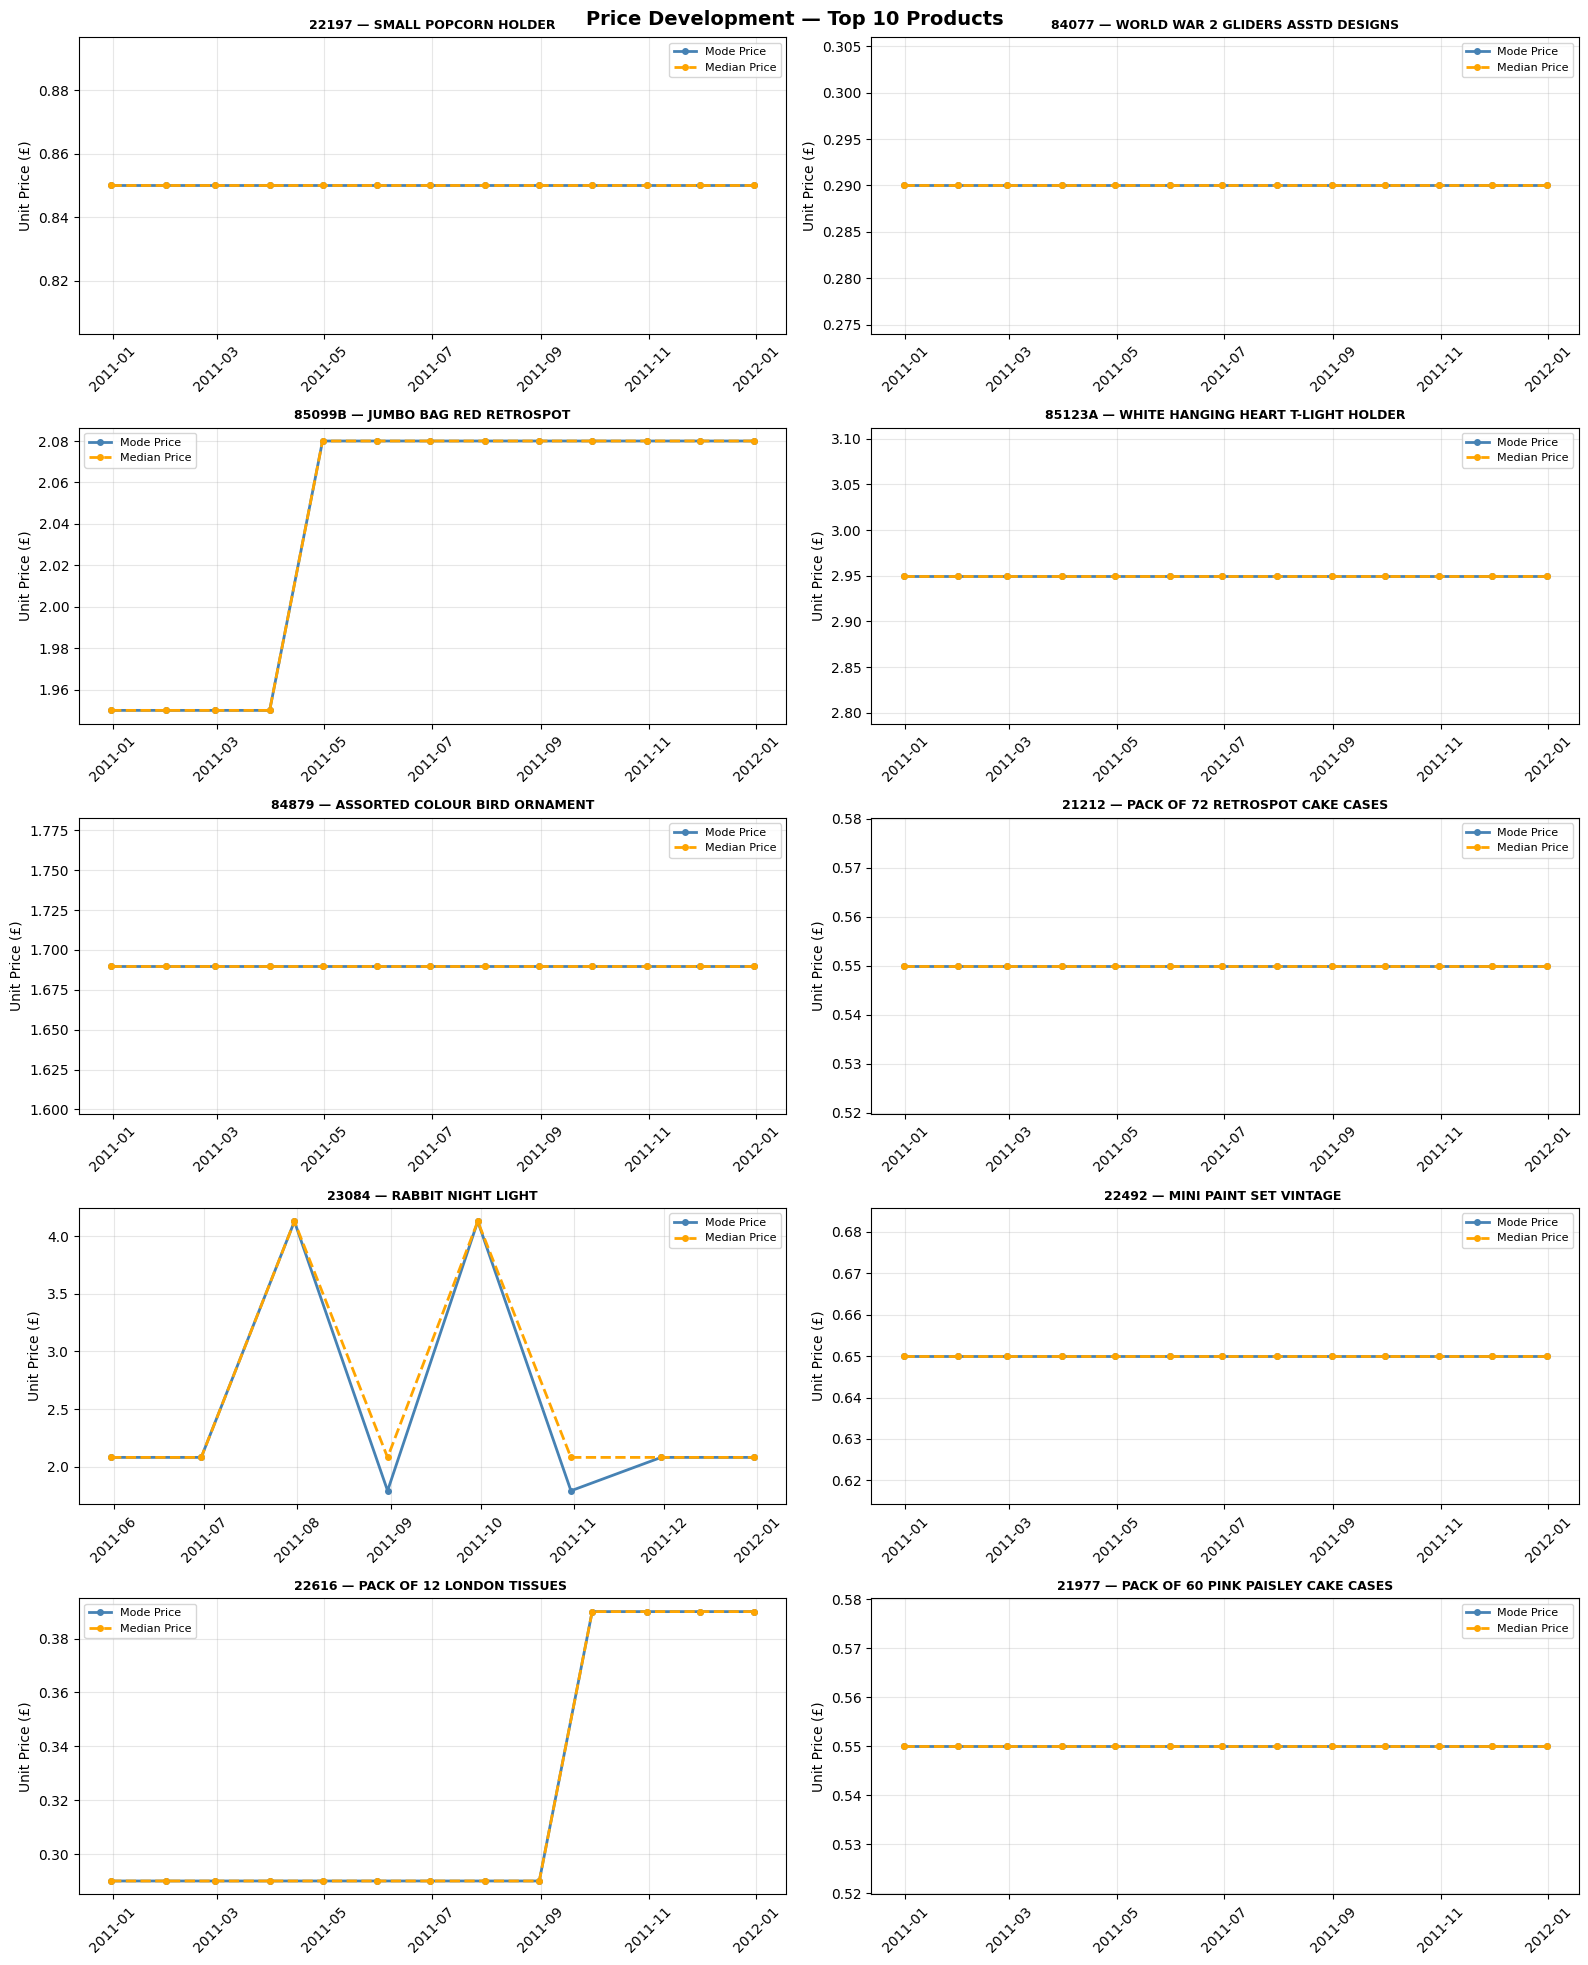

In [32]:
fig, axes = plt.subplots(5, 2, figsize=(16, 20))

for ax, stock_code in zip(axes.flat, top_10):
    product_data = top_products_price_development.loc[stock_code]
    description = df[df['StockCode'] == stock_code]['Description'].iloc[0]

    ax.plot(product_data.index, product_data['mod_unit_price'],
            color='steelblue', linewidth=2, marker='o', markersize=4,
            label='Mode Price')
    ax.plot(product_data.index, product_data['med_unit_price'],
            color='orange', linewidth=2, linestyle='dashed',
            marker='o', markersize=4, label='Median Price')

    ax.set_title(f'{stock_code} — {description}', fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Unit Price (£)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Price Development — Top 10 Products', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

#### **Price Development Analysis — Top 10 Products**


Price development over time reveals two distinct patterns across the top 10 products.

Majority show completely stable pricing — 7 out of 10 products maintain identical mode and median prices throughout the entire observation period, with flat lines confirming zero price variation over time. This effectively rules out time as a driver of price differences.
Three products show genuine price changes:

- JUMBO BAG RED RETROSPOT (85099B) — clear one-time price increase in April 2011 from £1.95 to £2.08, sustained for remainder of the year. Classic price revision.
- PACK OF 12 LONDON TISSUES (22616) — similar pattern, price jump in October 2011 from £0.28 to £0.40, sustained afterwards.
- RABBIT NIGHT LIGHT (23084) — more complex pattern with significant price spikes in August and October 2011, returning to base price. Could indicate seasonal premium pricing or promotional pricing reversal.

**Key finding:** time-based price development explains price changes for only 3 products and only partially — the permanent price revisions are single step changes, not gradual drift. The remaining price variation within each product therefore cannot be explained by time.
This confirms we should now examine quantity as the primary remaining hypothesis

### Quantity Discount

- To verify quantity as the root cause, starting with correlation analysis including time-based attributes to confirm the pattern is not driven by time of day or seasonality.

- Note: default Pearson correlation assumes normal distribution — given the heavily skewed nature of this dataset, Spearman method is more appropriate.

In [33]:
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

# Pearson - default, shown for comparison
df[['UnitPrice', 'Quantity', 'Month', 'Day', 'Hour']].corr()

,UnitPrice,Quantity,Month,Day,Hour
UnitPrice,1.000000,-0.001291,-0.000488,-0.002846,0.001399
Quantity,-0.001291,1.000000,-0.001116,-0.000010,-0.011268
Month,-0.000488,-0.001116,1.000000,-0.118878,0.025649
Day,-0.002846,-0.000010,-0.118878,1.000000,0.000174
Hour,0.001399,-0.011268,0.025649,0.000174,1.000000


In [34]:
# Spearman - more appropriate for skewed data
df[['UnitPrice', 'Quantity', 'Month', 'Day', 'Hour']].corr(method='spearman')

,UnitPrice,Quantity,Month,Day,Hour
UnitPrice,1.000000,-0.385416,-0.003006,-0.001911,0.025947
Quantity,-0.385416,1.000000,-0.025003,0.005254,-0.210406
Month,-0.003006,-0.025003,1.000000,-0.150045,0.026969
Day,-0.001911,0.005254,-0.150045,1.000000,0.001110
Hour,0.025947,-0.210406,0.026969,0.001110,1.000000


- Dataset-level Spearman correlation confirms volume discount signal (-0.39 UnitPrice vs Quantity)
- Rules out time variables as pricing drivers.
- However mixing products with vastly different price points dilutes results
-  Let's vefiry correlation on individual product level for top 10 products.

In [35]:
df[df['StockCode'].isin(top_10)]\
    .groupby('StockCode')[['UnitPrice', 'Quantity', 'Month', 'Day', 'Hour']]\
    .corr(method='spearman')['UnitPrice']\
    .drop('UnitPrice', level=1)\
    .unstack()

,Quantity,Month,Day,Hour
StockCode,,,,
21212,-0.424386,0.057908,0.036233,0.225147
21977,-0.608822,-0.017080,-0.037866,0.284300
22197,-0.405502,-0.066328,0.022984,0.179021
22492,-0.648165,0.126264,0.028028,0.348629
22616,-0.565620,0.320573,0.031193,0.310519
23084,-0.507581,-0.137586,-0.051008,0.240065
84077,-0.736449,0.180848,0.038373,0.220495
84879,-0.288825,0.041648,-0.011680,0.049519
85099B,-0.520143,0.101601,0.050807,0.216991


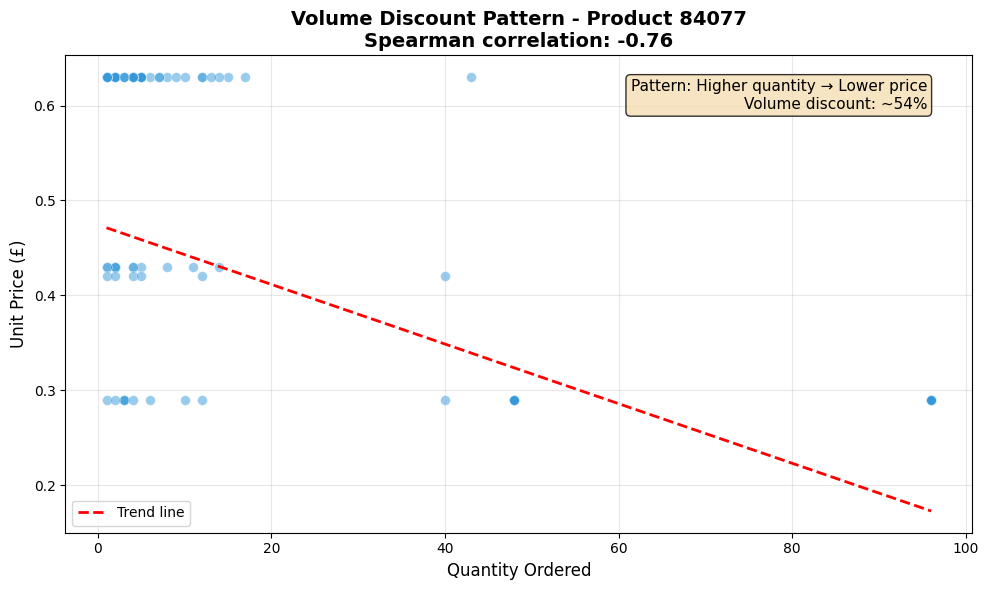

Product: 84077
Number of transactions: 478
Quantity range: 1 to 96
Price range: £0.29 to £0.63

Spearman correlation: -0.761
Interpretation: Strong negative correlation


In [130]:

# Pick one product
product = 84077
df_product = df[df['StockCode'] == product].copy()

# Remove extreme outliers for better visualization
# (keeps data but makes pattern clearer)
df_product = df_product[
    (df_product['Quantity'] > 0) &
    (df_product['Quantity'] < df_product['Quantity'].quantile(0.90))
]

# Calculate correlation
correlation = df_product['Quantity'].corr(df_product['UnitPrice'])
spearman_corr = df_product['Quantity'].corr(df_product['UnitPrice'], method='spearman')

# Create simple scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter
ax.scatter(df_product['Quantity'],
           df_product['UnitPrice'],
           alpha=0.5,
           s=50,
           color='#3498db',
           edgecolors='white',
           linewidth=0.5)

# Add trend line
z = np.polyfit(df_product['Quantity'], df_product['UnitPrice'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df_product['Quantity'].min(),
                      df_product['Quantity'].max(), 100)
ax.plot(x_trend, p(x_trend),
        'r--',
        linewidth=2,
        label=f'Trend line')

# Labels and title
ax.set_xlabel('Quantity Ordered', fontsize=12)
ax.set_ylabel('Unit Price (£)', fontsize=12)
ax.set_title(f'Volume Discount Pattern - Product {product}\n'
             f'Spearman correlation: {spearman_corr:.2f}',
             fontsize=14, fontweight='bold')

# Add text box with insight
low_qty_price = df_product[df_product['Quantity'] < 10]['UnitPrice'].median()
high_qty_price = df_product[df_product['Quantity'] > 50]['UnitPrice'].median()
discount_pct = ((low_qty_price - high_qty_price) / low_qty_price * 100)

textstr = (f'Pattern: Higher quantity → Lower price\n'
           f'Volume discount: ~{discount_pct:.0f}%')
ax.text(0.95, 0.95, textstr,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Print summary stats
print(f"Product: {product}")
print(f"Number of transactions: {len(df_product)}")
print(f"Quantity range: {df_product['Quantity'].min():.0f} to {df_product['Quantity'].max():.0f}")
print(f"Price range: £{df_product['UnitPrice'].min():.2f} to £{df_product['UnitPrice'].max():.2f}")
print(f"\nSpearman correlation: {spearman_corr:.3f}")
print(f"Interpretation: {'Strong' if abs(spearman_corr) > 0.7 else 'Moderate' if abs(spearman_corr) > 0.4 else 'Weak'} negative correlation")

In [137]:
df_product.groupby(['Quantity','UnitPrice']).size().reset_index(name='Count').sort_values(by='Quantity', ascending=True)




,Quantity,UnitPrice,Count
0,1,0.29,1
1,1,0.42,1
2,1,0.43,2
3,1,0.63,12
4,2,0.29,1
5,2,0.42,1
6,2,0.43,3
7,2,0.63,8
9,3,0.63,3
8,3,0.29,3


Product-Level Spearman Correlation — UnitPrice vs Key Variables
Quantity — confirmed as primary driver:
All products show negative correlation with quantity, confirming volume discount across the board. Strength varies significantly:

Month — negligible for most:
Generally close to 0, confirming price is stable over time. Exception is 22616 (0.32) — consistent with the price jump we observed in October 2011 in the development charts.

Day — essentially zero across all products:
Day of month has no meaningful relationship with price for any product. Safely ruled out.

Hour — small but consistent positive signal:
Slight positive correlation across most products suggesting morning orders (lower hour) tend to have slightly lower prices — consistent with wholesale bulk orders placed in the morning getting volume discounts, while afternoon retail orders are smaller and pay full price.

**Overall conclusion:** quantity is the dominant driver of price variation, time variables play a negligible role. Analysis proceeds in two steps — qcut bins to visualise how volume discounts materialise in practice, followed by ANOVA to statistically confirm the differences between quantity groups are significant rather than random noise.

In [37]:
# noticed some quantity inputs are not numbers, so lets fix that
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')


# lets check avg price per quantity bins
df[df['StockCode'].isin(top_10)].groupby(['StockCode', pd.qcut(df['Quantity'], q=5)], observed=True)['UnitPrice'].mean()

StockCode  Quantity         
21212      (-80995.001, 1.0]    0.929556
           (1.0, 2.0]           0.774286
           (2.0, 5.0]           0.807806
           (5.0, 12.0]          0.990638
           (12.0, 80995.0]      0.650054
21977      (-80995.001, 1.0]    1.040881
           (1.0, 2.0]           0.911102
           (2.0, 5.0]           0.739293
           (5.0, 12.0]          0.631087
           (12.0, 80995.0]      0.537241
22197      (-80995.001, 1.0]    1.142441
           (1.0, 2.0]           1.201691
           (2.0, 5.0]           1.128604
           (5.0, 12.0]          0.982917
           (12.0, 80995.0]      0.971645
22492      (-80995.001, 1.0]    1.227586
           (1.0, 2.0]           1.633333
           (2.0, 5.0]           1.450000
           (5.0, 12.0]          1.270000
           (12.0, 80995.0]      0.656790
22616      (-80995.001, 1.0]    0.667431
           (1.0, 2.0]           0.626364
           (2.0, 5.0]           0.610000
           (5.0, 12.0]      

Volume Discount Analysis — Quantity Bins

Results confirm stepwise volume discount pattern across the majority of top 10 products

**Overall:** 8 out of 10 products show meaningful volume discount patterns,
providing strong visual confirmation of the Spearman correlation findings.
ANOVA will now statistically confirm whether differences between bins are significant.

In [38]:
# ANOVA - tests if price differences are statisticaly significant
# across quantity groups

df_top = df[df['StockCode'] == '85123A']
groups = [group['UnitPrice'].values for _, group
          in df_top.groupby(pd.qcut(df_top['Quantity'], q=5, duplicates='drop'), observed=True)]

f_stat, p_value = f_oneway(*groups)
print(f'p-value: {p_value:.4f}')

p-value: 0.0000


### Summary

Initial exploration revealed significant price variation for the same products. Systematic investigation ruled out country and time as drivers — confirmed by near-zero correlations for month, day and hour across all products.
Volume discount emerged as the primary driver, confirmed through three complementary approaches:

Spearman correlation — negative relationship between quantity and price across all top 10 products (-0.29 to -0.74)
qcut bin analysis — clear stepwise price decreases visible across quantity groups for 8 out of 10 products
ANOVA — price differences between quantity groups statistically significant (p-value ≈ 0), not random noise

Initial Pearson correlation understated the relationship (0.1-0.2) due to its linear assumption — volume discounts are stepwise not linear. Switching to Spearman revealed substantially stronger signal, highlighting the importance of choosing the appropriate statistical method for skewed data.

Data notes:
Non-product stock codes (DOT, M, POST etc.) excluded as internal fee entries
Quantity column contained non-numeric values — coerced to NaN using pd.to_numeric()

# DESCRIPTIVE STATISTICS

1. Calculate mean, median, std dev of TotalPrice
   - Is the distribution skewed?
   - Create histogram with mean/median lines
2. What's the coefficient of variation for TotalPrice?
   - Interpret: is spending consistent or variable?
3. Calculate the 95th percentile of TotalPrice
   - What does this tell you about high-value orders?
4. Create a box plot showing TotalPrice distribution
   - How many outliers are there?

## Mean, median, std

TotalPrice represents value of a single invoice line (UnitPrice × Quantity)
not the total invoice value — important distinction for correct interpretation


In [39]:
# excluding returns for distribution analysis
orders = df[~df['IsReturn']]

# double brackets to return DataFrame instead of Series
orders[['TotalPrice']].agg(['mean', 'median', 'std'])

# mean is ~2x higher than median indicating significant right skew


,TotalPrice
mean,20.056434
median,9.900000
std,269.633277


In [40]:
orders['TotalPrice'].skew()

np.float64(509.53454345164283)

**Rule of thumb for interpretation:**

-1 to 1 — mild skew, roughly normal

1 to 3 or -3 to -1 — moderate skew

\> 3 or < -3 — highly skewed

509 is extreme — far beyond any typical threshold. This means:

Vast majority of orders are small value (median ~£10)
A tiny number of massive wholesale orders pull the mean up to ~£20
The distribution is essentially a spike near zero with an extremely long right tail

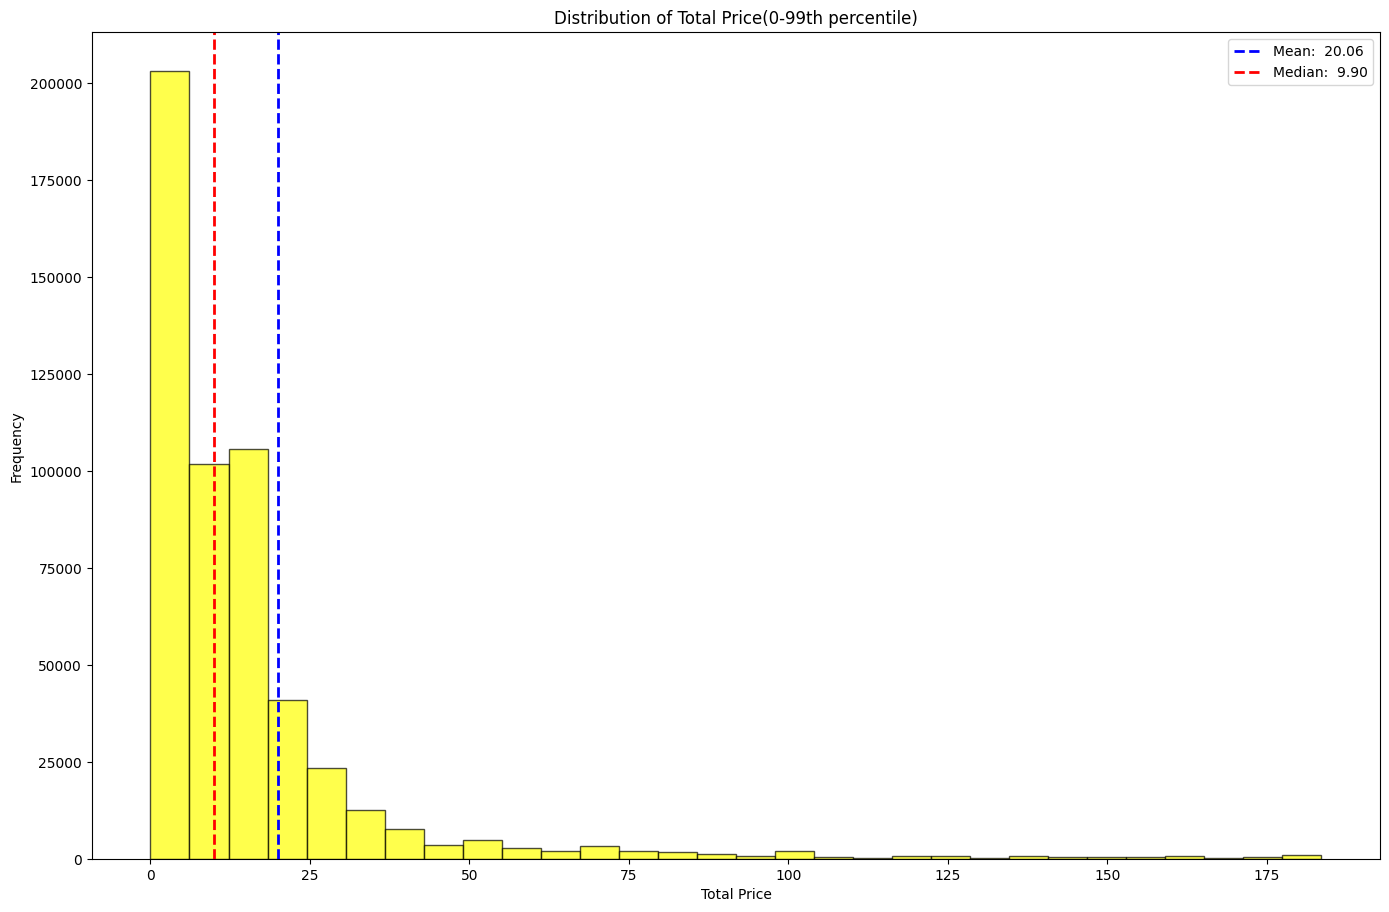

In [41]:
orders = df[df['IsReturn'] == False]

tp_mean = orders['TotalPrice'].mean()
tp_median = orders['TotalPrice'].median()

fig, ax = plt.subplots(figsize=(14, 9))
ax.hist(orders[orders['TotalPrice'] < orders['TotalPrice'].quantile(0.99)]['TotalPrice'],
        bins=30, color='yellow', edgecolor='black', alpha=0.7)

ax.axvline(tp_mean, color='blue',
           linestyle='dashed', linewidth=2, label=f'Mean: {tp_mean: .2f}')
ax.axvline(tp_median, color='red',
           linestyle='dashed', linewidth=2, label=f'Median: {tp_median: .2f}')


ax.set_xlabel('Total Price')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
ax.set_title('Distribution of Total Price(0-99th percentile)')
plt.show()

Key Findings

Distribution is strongly right-skewed as confirmed by skewness of 509, clearly visible in the chart.

Majority of order lines are low value — largest bar is in the £0-10 range with over 200,000 transactions
Median (£9.90, red) — typical order line value, robust measure not affected by outliers
Mean (£20.06, blue) — pulled significantly to the right by high-value wholesale order lines, more than 2x the median
Sharp drop-off after £25, with a long flat tail extending to £175+ (99th percentile cutoff)

Practical interpretation:
The typical customer buys items worth around £10 per line. The gap between mean and median quantifies the wholesale effect — a small number of high-value bulk order lines inflate the average significantly. Median is the more representative measure of typical transaction value in this dataset.

## CV
2. What's the coefficient of variation for TotalPrice?
   - Interpret: is spending consistent or variable?


In [42]:
cv = orders['TotalPrice'].std()/df['TotalPrice'].mean()
print(f'Coefficient of variation for TotalPrice is {cv: .2f}')

Coefficient of variation for TotalPrice is  14.97


Interpreting CV:

Below 0.3 (30%) — low variability, consistent

0.3 to 1.0 (30-100%) — moderate variability

Above 1.0 (100%+) — high variability

Spending is extremly variable which is not suprising considering high range in quantities 1 to ~ 81k and unit price 1-397k.

In [43]:
# to see order ranges
orders.describe()

,Quantity,InvoiceDate,UnitPrice,TotalPrice,Month,Day,Hour
count,531282.000000,531282,531282.000000,531282.000000,531282.000000,531282.000000,531282.000000
mean,10.655317,2011-07-04 18:15:26.858730,3.878140,20.056434,7.560241,15.024712,13.076253
min,1.000000,2010-12-01 08:26:00,0.000000,0.000000,1.000000,1.000000,6.000000
25%,1.000000,2011-03-28 11:59:00,1.250000,3.750000,5.000000,7.000000,11.000000
50%,3.000000,2011-07-20 12:01:00,2.080000,9.900000,8.000000,15.000000,13.000000
75%,10.000000,2011-10-19 12:35:00,4.130000,17.700000,11.000000,22.000000,15.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,168469.600000,12.000000,31.000000,20.000000
std,156.830764,NaN,32.510663,269.633277,3.508727,8.662178,2.438309


## 95th Percentile

In [44]:
perc_95th = orders['TotalPrice'].quantile(0.95)
perc_99th = orders['TotalPrice'].quantile(0.99)
print(f'95th percentile is: {perc_95th: .2f}')
print(f'99th percentile is: {perc_99th: .2f}')

95th percentile is:  59.67
99th percentile is:  183.60


High percentiles are still low figures, it means that total majority of data set are orders from retail customers, but there is few whole sale customers skewing total price distribution

## TotalPrice distribution (boxplot)
   

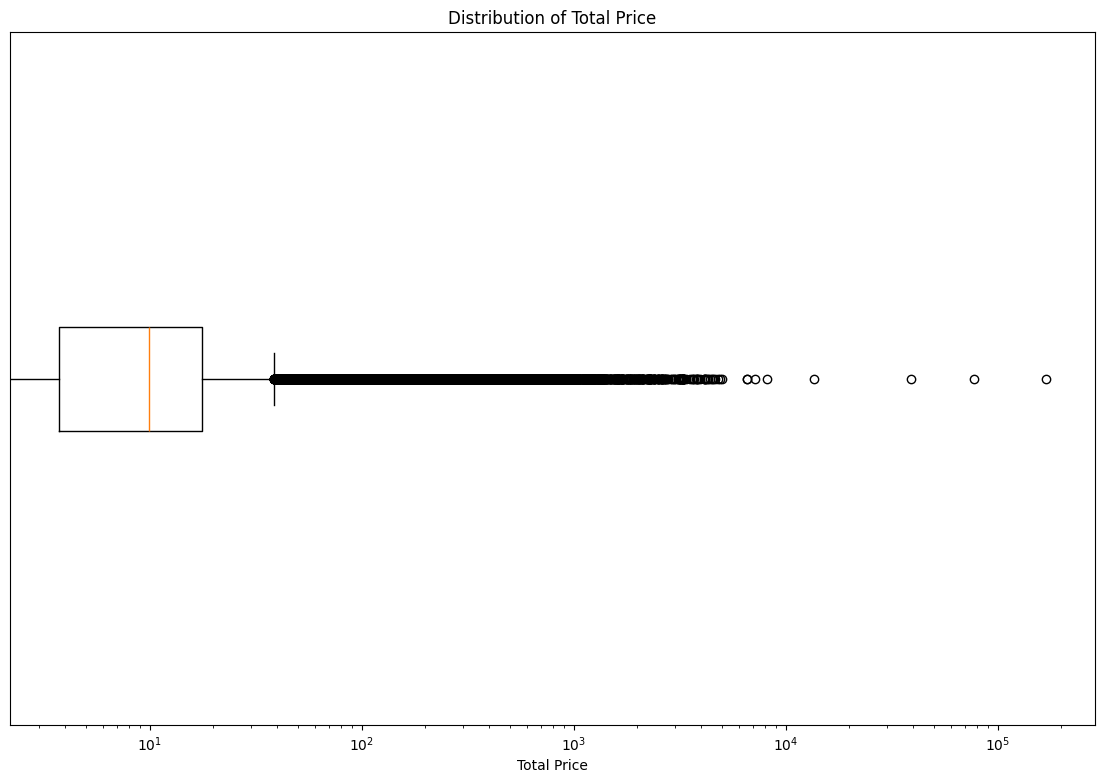

In [45]:
fig, ax = plt.subplots(figsize=(14, 9))

ax.boxplot(orders['TotalPrice'], vert=False)

ax.set_xscale('log')
ax.set_xlabel('Total Price')
ax.set_ylabel('')
ax.set_yticks([])
ax.set_title('Distribution of Total Price')

plt.show()

In [46]:
# to identify outliers
Q1 = orders['TotalPrice'].quantile(0.25)
Q3 = orders['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = orders[orders['TotalPrice'] > upper_bound]

print(f'Normal Range: {lower_bound: .2f} - {upper_bound: .2f}')
print(f'Outliers Count: {outliers.shape[0]}')
print(f'Outliers Share: {(outliers.shape[0]/df.shape[0])* 100: .2f} %')

Normal Range: -17.18 -  38.63
Outliers Count: 42650
Outliers Share:  7.87 %


In [47]:
normal_data = orders[df['TotalPrice'] < upper_bound]
normal_data['TotalPrice'].describe()

/var/folders/05/3xzngw_n6tv7wlp__kmhfjwh0000gn/T/ipykernel_89354/2926547453.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  normal_data = orders[df['TotalPrice'] < upper_bound]


count    488632.000000
mean         10.449155
std           8.321377
min           0.000000
25%           3.320000
50%           8.290000
75%          15.900000
max          38.520000
Name: TotalPrice, dtype: float64

In [48]:
outliers['TotalPrice'].describe()

count     42650.000000
mean        130.124997
std         944.292334
min          38.700000
25%          49.800000
50%          70.200000
75%         120.127500
max      168469.600000
Name: TotalPrice, dtype: float64

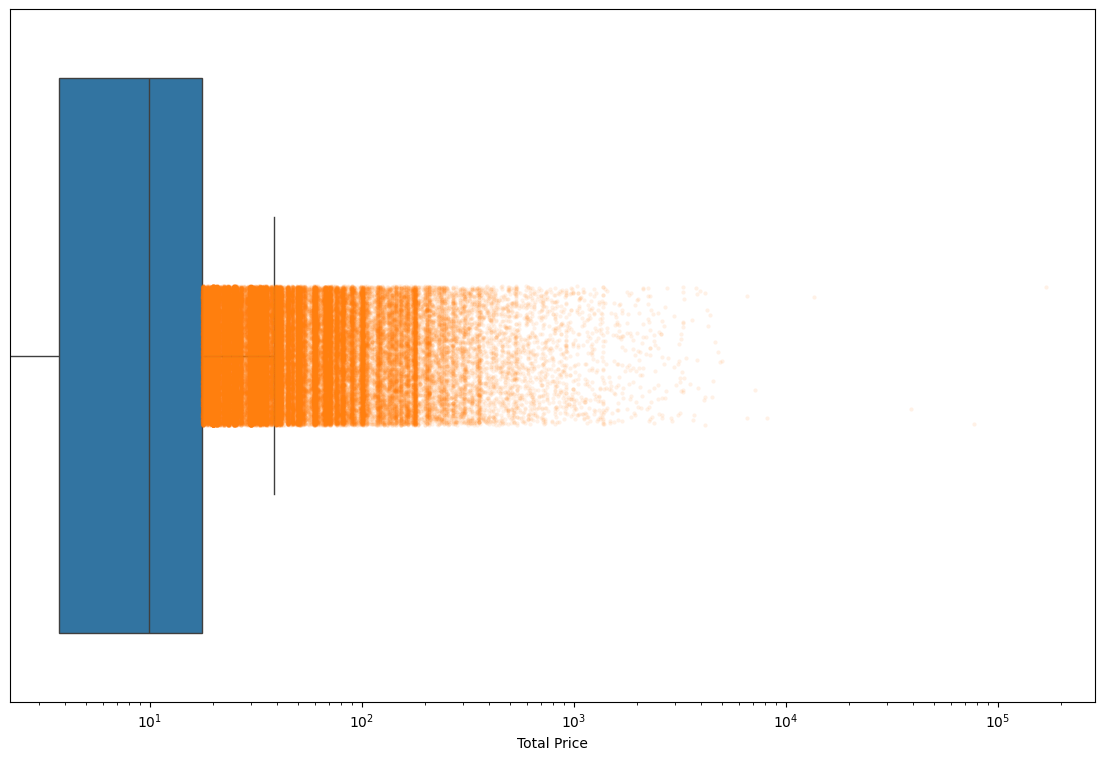

In [49]:
fig, ax = plt.subplots(figsize=(14, 9))

sns.boxplot(x=orders['TotalPrice'], showfliers=False, ax=ax)  # hide outliers from boxplot
sns.stripplot(x=orders[orders['TotalPrice'] > Q3]['TotalPrice'],
              alpha=0.1, size=3, ax=ax)  # overlay actual outlier points

ax.set_xscale('log')
ax.set_xlabel('Total Price')
ax.set_ylabel('')
ax.set_yticks([])
plt.show()

## Idea for customer segmentation

Using total price there is not any visible gap to easily distinguish wholesale and usual retail customers, lets leave it to customer segmentation part of analysis, just idea how to approach it:

**Scikit-learn (sklearn)** is the main Python machine learning library — it covers clustering, classification, regression, preprocessing and more. KMeans is just one algorithm inside it.

**How KMeans works conceptually:**

```
1. Pick K number of clusters (you decide, e.g. 2)
2. Randomly place K central points (centroids)
3. Assign each data point to nearest centroid
4. Recalculate centroid as mean of all assigned points
5. Repeat 3-4 until points stop moving between clusters
```

Visually imagine two groups of dots on a scatter plot — KMeans finds the center of each group and draws the boundary between them.

**Basic usage:**
```python
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# IMPORTANT - scale first, kmeans is distance based
# quantity in hundreds vs price in thousands = price dominates
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['Quantity', 'TotalPrice']])

# fit model
kmeans = KMeans(n_clusters=2, random_state=42)
df['segment'] = kmeans.fit_predict(X_scaled)

# inspect clusters
df.groupby('segment')[['Quantity', 'TotalPrice']].agg(['mean', 'median'])
```

**Why scaling matters:**
```
unscaled:  Quantity=5,    TotalPrice=500
           Quantity=1000, TotalPrice=510

# distance dominated by TotalPrice, Quantity ignored
# after scaling both contribute equally
```

**Choosing K** — the elbow method helps find the right number of clusters:
```python
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
```

`inertia` measures how tight the clusters are — you look for the "elbow" where adding more clusters stops improving much:
```
k=1: 1000
k=2: 400   ← big drop
k=3: 350   ← small drop, elbow here
k=4: 340   ← diminishing returns
```

**Key limitations to know:**
- KMeans assumes clusters are roughly spherical and equal size — not always true in retail data
- Always finds exactly K clusters even if natural groupings don't exist
- Sensitive to outliers — your extreme wholesale orders could pull centroids
- Random initialization means results can vary — `random_state=42` fixes this for reproducibility

For this dataset I'd run it at customer level rather than transaction level — cluster customers by their overall behavior rather than individual transactions which is noisier.

# TIME SERIES ANALYSIS

1. **Daily revenue trend:**
   - Group by date, sum TotalPrice
   - Plot daily revenue
   - Add 7-day moving average
   - Which days have highest revenue?

2. **Monthly analysis:**
   - Calculate monthly revenue
   - Calculate month-over-month growth rate
   - Visualize monthly trend
   - Is the business growing?

3. **Day of week pattern:**
   - Extract day of week from InvoiceDate
   - Which day has most orders?
   - Create bar chart

4. **Hour of day pattern:**
   - Extract hour from InvoiceDate
   - When do people shop most?
   - Line plot showing hourly pattern


In [50]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,IsReturn,IsProduct,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,False,True,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,True,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,False,True,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,True,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,True,12,1,8


In [51]:
df.info()

<class 'pandas.DataFrame'>
Index: 541906 entries, 0 to 541908
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541906 non-null  object        
 1   StockCode    541906 non-null  object        
 2   Description  540452 non-null  object        
 3   Quantity     541906 non-null  int64         
 4   InvoiceDate  541906 non-null  datetime64[us]
 5   UnitPrice    541906 non-null  float64       
 6   CustomerID   406829 non-null  str           
 7   Country      541906 non-null  str           
 8   TotalPrice   541906 non-null  float64       
 9   IsReturn     541906 non-null  bool          
 10  IsProduct    541906 non-null  bool          
 11  Month        541906 non-null  int32         
 12  Day          541906 non-null  int32         
 13  Hour         541906 non-null  int32         
dtypes: bool(2), datetime64[us](1), float64(2), int32(3), int64(1), object(3), str(2)
memory usage: 64.7+

In [52]:
# I see InvoiceDate is actualy datetime, so maybe we sjoud rename and create column with date only
df.rename(columns={'InvoiceDate': 'InvoiceDateTime'}, inplace = True)
df['InvoiceDate'] = df['InvoiceDateTime'].dt.date


## Daily revenue trend

In [53]:
daily_revenue = df.groupby('InvoiceDate')['TotalPrice'].sum()
daily_revenue.head()

InvoiceDate
2010-12-01    58635.56
2010-12-02    46207.28
2010-12-03    45620.46
2010-12-05    31383.95
2010-12-06    53860.18
Name: TotalPrice, dtype: float64

In [54]:
daily_revenue

InvoiceDate
2010-12-01    58635.56
2010-12-02    46207.28
2010-12-03    45620.46
2010-12-05    31383.95
2010-12-06    53860.18
                ...   
2011-12-05    57751.32
2011-12-06    54228.37
2011-12-07    75076.22
2011-12-08    81417.78
2011-12-09    32131.53
Name: TotalPrice, Length: 305, dtype: float64

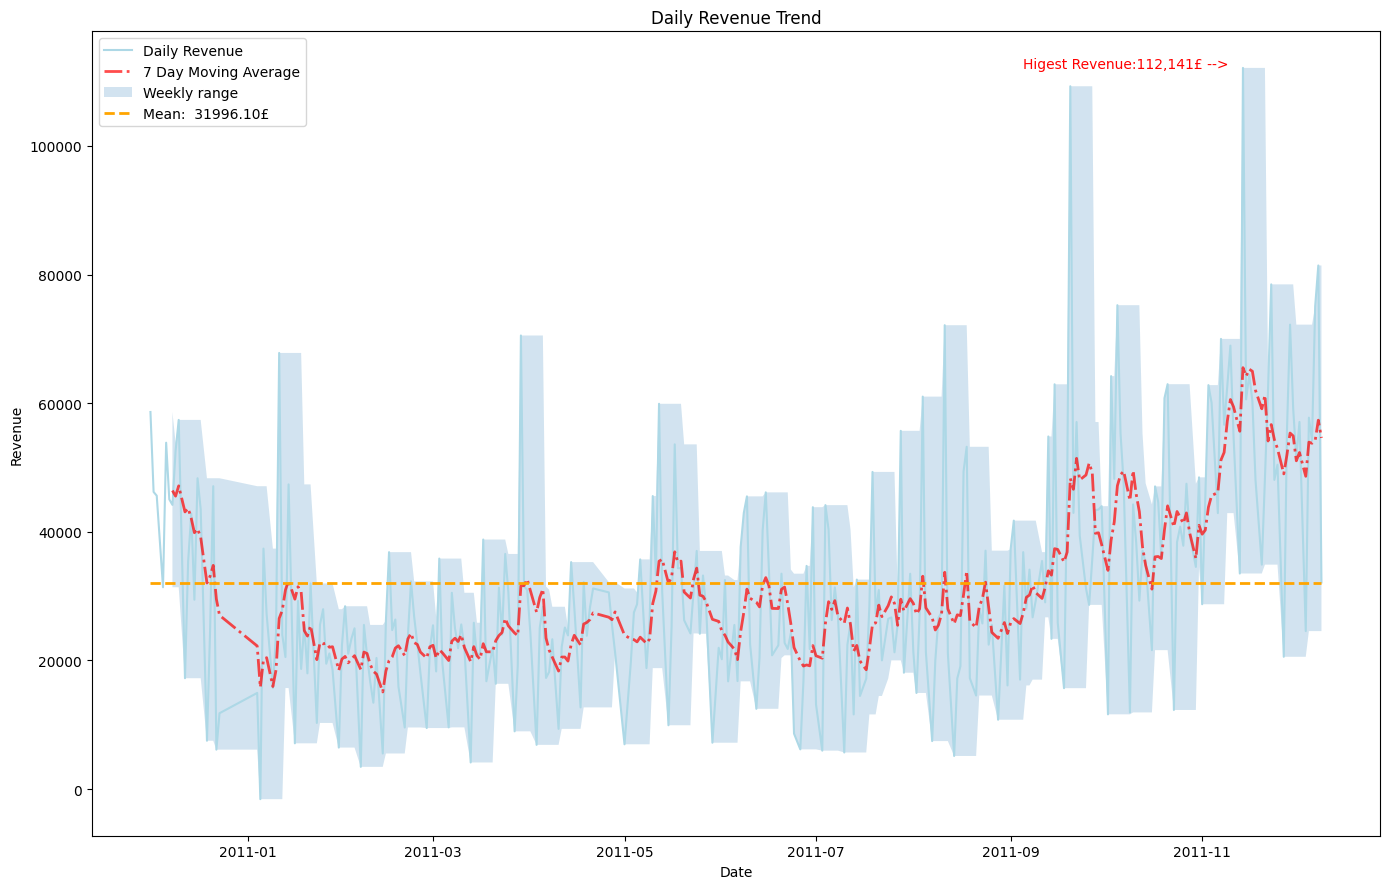

In [55]:
# to group revenue by date
daily_revenue = df.groupby('InvoiceDate')['TotalPrice'].sum()

fig, ax = plt.subplots(figsize=(14, 9))

rolling_avg= daily_revenue.rolling(window=7).mean()

rolling_floor = daily_revenue.rolling(7).min()
rolling_ceiling = daily_revenue.rolling(7).max()

# use lightblue to emphasize moving average
ax.plot(daily_revenue, label="Daily Revenue", color='lightblue')

ax.plot(rolling_avg, label='7 Day Moving Average',
        color='red', linewidth='2', linestyle='dashdot', alpha=0.7)
ax.fill_between(daily_revenue.index, rolling_floor, rolling_ceiling, alpha=0.2,
                label='Weekly range')

ax.set_xlabel('Date')
ax.set_ylabel('Revenue')
ax.hlines(y=daily_revenue.mean(), xmin=daily_revenue.index.min(),
          xmax=daily_revenue.index.max(), color='orange',
          linestyle='dashed', linewidth=2,
          label=f'Mean: {daily_revenue.mean(): .2f}£')

ax.text(x=daily_revenue.idxmax() - pd.Timedelta(weeks=10),
        y= daily_revenue.max(),
        s=f'Higest Revenue:{int(daily_revenue.max()):,}£ -->',
        c='red',
        fontname='sans-serif',
        fontsize=10
        )
ax.set_title('Daily Revenue Trend')
ax.legend()

plt.tight_layout()
plt.show()





### **Key Findings**

---



Revenue is relatively stable throughout H1 2011 with the 7-day moving average hovering around the mean (£32k), showing no clear growth trend in the first half of the year.
Clear acceleration from September 2011 onwards — both daily revenue and moving average trend upward significantly, consistent with Q4 seasonality identified in the monthly analysis.
Notable observations:

Negative revenue day visible in January 2011 — likely a high-returns day worth investigating
Several isolated spikes throughout the year (May, August) significantly above the weekly range — likely single large wholesale orders rather than genuine trend changes
Weekly range (blue band) widens considerably in Q4, reflecting increased day-to-day volatility alongside higher revenue — busier period brings more variability
Highest revenue day £112,141 in November 2011 — peak of the Christmas trading season

Overall: no clear growth trend visible in H1, strong Q4 seasonal effect dominates the picture. Confirming the earlier conclusion that a second year of data would be needed to distinguish seasonal pattern from underlying business growth.

### Why to use 7 day moving average?



**Removes weekly patterns** — retail naturally has busy/quiet days (weekends vs weekdays). 7 day window averages out exactly one full week cycle so the pattern doesn't repeat in the smoothed line.

**Reveals actual trend** — is revenue growing, declining, or flat over the year? Hard to see on noisy daily data, obvious on the smoothed line.

**Highlights anomalies** — when daily revenue spikes far above the 7 day average it signals something unusual — a big wholesale order, a promotion, a seasonal event. Your peak day is a good example.

In financial and retail analytics 7 day moving average is the most standard choice precisely because it aligns with the natural weekly business cycle — same reason you grouped by weekday earlier to check weekend vs weekday patterns.



```

### Highest Revenue Days & anomalies

In [56]:
daily_revenue.sort_values(ascending=False).head()

InvoiceDate
2011-11-14    112141.11
2011-09-20    109286.21
2011-12-08     81417.78
2011-11-23     78480.70
2011-10-05     75244.43
Name: TotalPrice, dtype: float64

In [57]:
rolling_std = daily_revenue.rolling(7).std()

# to cover anomalous increses, drops and negative reve
anomalies = daily_revenue[((daily_revenue > rolling_avg + 2 * rolling_std) |
 (daily_revenue < 0) | (daily_revenue < rolling_avg - 2 * rolling_std))]
print(anomalies)

InvoiceDate
2011-01-05    -1566.23
2011-03-29    70531.47
2011-05-01     6964.66
2011-07-28    55706.88
2011-09-13    54828.45
Name: TotalPrice, dtype: float64


Highest Revenue Days & Anomalies
Top 5 revenue days are concentrated in Q4 2011 (Sep-Nov), consistent with the seasonal pattern identified earlier. Peak day was 14th November 2011 at £112,141 — likely driven by large wholesale orders ahead of Christmas.
Anomaly detection using 2-sigma rolling window identified 5 notable days:

5th January 2011 (-£1,566) — negative revenue, high returns day likely post-Christmas refunds
29th March, 28th July, 13th September — unusually high spikes, likely single large wholesale orders rather than genuine trend changes
1st May 2011 (£6,964) — anomalously low, coincides with UK bank holiday explaining near-zero trading activity

All anomalies have plausible business explanations and don't indicate data quality issues.

## Monthly analysis:

- Calculate monthly revenue
- Calculate month-over-month growth rate
- Visualize monthly trend
- Is the business growing?

In [58]:
# December 2011 data is incomplete (9 days only)
# approach: compare equivalent first full Thu-Wed week in both years
# to calculate YoY growth rate, then project full December 2011 revenue

df['YearMonth'] = df['InvoiceDateTime'].dt.to_period('M')
df['DayOfWeek'] = df['InvoiceDateTime'].dt.day_name()

monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum()
dec_2010_revenue = df[df['YearMonth'] == '2010-12']['TotalPrice'].sum()
dec_2011_partial_revenue = monthly_revenue.values[-1]

# compare same weekdays (Thu-Wed) in first week of December both years
# eliminates day-of-week bias, Saturday excluded in both years
week_2010 = df[(df['YearMonth'] == '2010-12') &
               (df['InvoiceDateTime'] > '2010-12-02') &
               (df['InvoiceDateTime'] < '2010-12-09')]\
              .groupby(['InvoiceDate', 'DayOfWeek'])['TotalPrice'].sum().sort_index()

week_2011 = df[(df['YearMonth'] == '2011-12') &
               (df['InvoiceDateTime'] < '2011-12-08')]\
              .groupby(['InvoiceDate', 'DayOfWeek'])['TotalPrice'].sum().sort_index()

yoy_growth = (week_2011.sum() - week_2010.sum()) / week_2010.sum()

# project full December 2011 by applying YoY growth to December 2010 actual
projected_dec_2011_revenue = dec_2010_revenue * (1 + yoy_growth)

print(f'Dec 2010 actual revenue: £{dec_2010_revenue:,.2f}')
print(f'Dec 2011 partial revenue (9 days): £{dec_2011_partial_revenue:,.2f}')
print(f'YoY growth (first week comparison): {yoy_growth:+.1%}')
print(f'Projected Dec 2011 full revenue: £{projected_dec_2011_revenue:,.2f}')

Dec 2010 actual revenue: £748,957.02
Dec 2011 partial revenue (9 days): £433,668.01
YoY growth (first week comparison): +20.2%
Projected Dec 2011 full revenue: £900,249.56


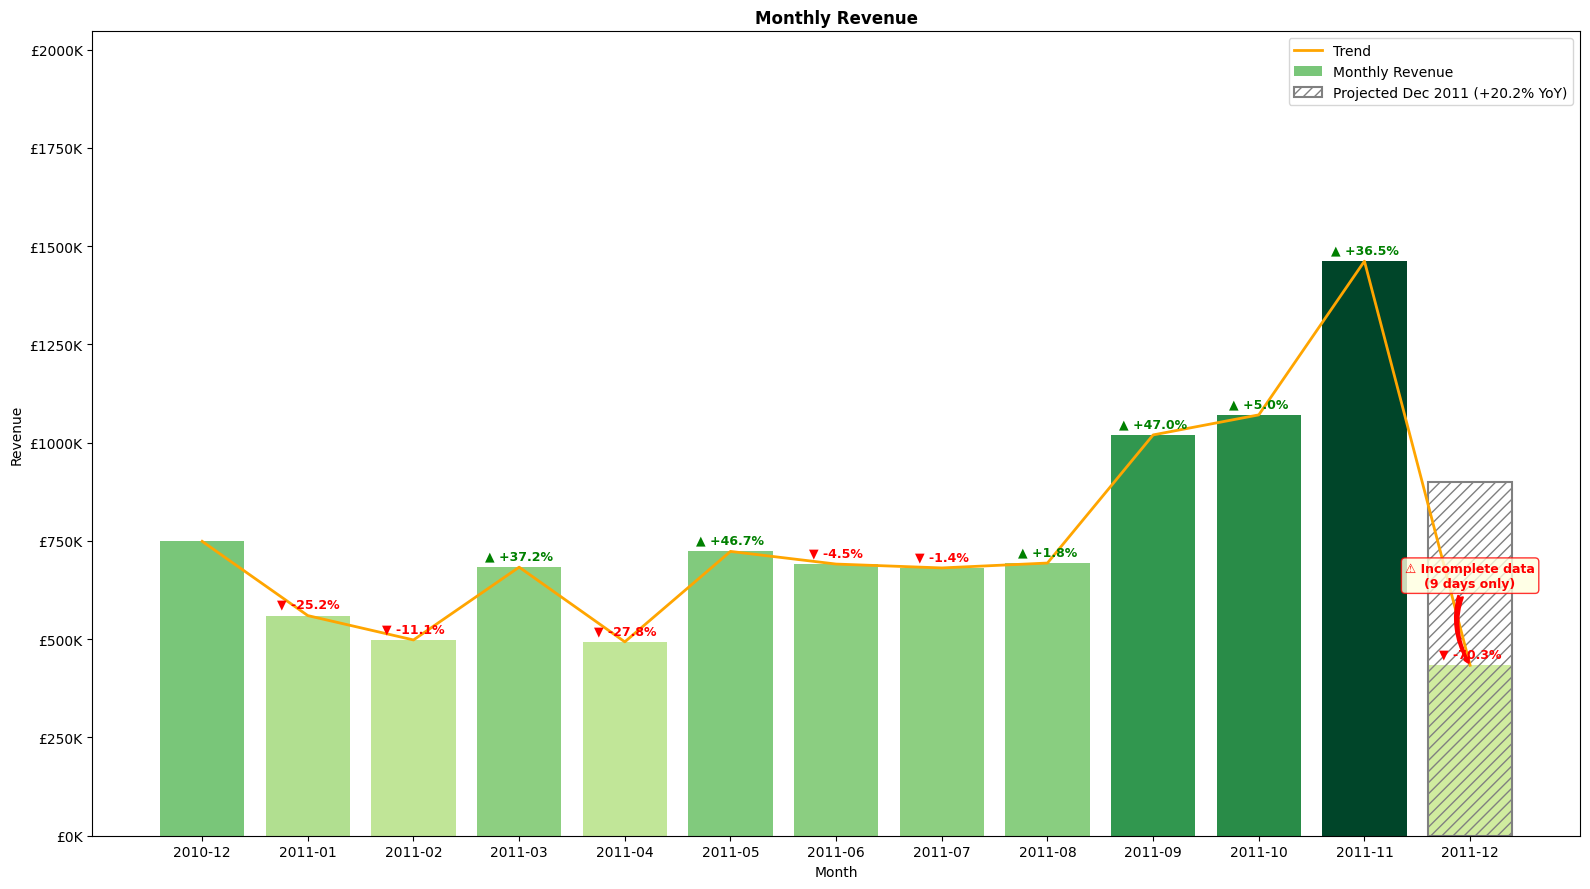

In [59]:
# reuse variables from previous cell
# monthly_revenue, projected_dec_2011_revenue, yoy_growth already defined

monthly_growth_rate = monthly_revenue.pct_change()
monthly_revenue.index = monthly_revenue.index.astype(str)
monthly_growth_rate.index = monthly_growth_rate.index.astype(str)

fig, ax = plt.subplots(figsize=(16, 9))

# color scheme
cmap = matplotlib.colormaps['YlGn']
norm = mcolors.Normalize(vmin=monthly_revenue.min() * 0.1, vmax=monthly_revenue.max())
colors = [cmap(norm(val)) for val in monthly_revenue.values]

# actual revenue bars
ax.bar(monthly_revenue.index, monthly_revenue.values,
       label='Monthly Revenue', color=colors)

# projected december 2011 — hatched overlay
ax.bar(monthly_revenue.index[-1], projected_dec_2011_revenue,
       color='none', edgecolor='grey', linewidth=1.5,
       hatch='///', label=f'Projected Dec 2011 (+{yoy_growth:.1%} YoY)')

# growth rate labels
for i, (month, value) in enumerate(zip(monthly_revenue.index, monthly_revenue.values)):
    growth_rate = monthly_growth_rate[month]

    if pd.isna(growth_rate):
        continue

    color = 'green' if growth_rate >= 0 else 'red'
    arrow = '▲' if growth_rate >= 0 else '▼'

    ax.text(x=month, y=value + 20000, ha='center', fontsize=9,
            color=color, fontweight='bold',
            s=f'{arrow} {growth_rate:+.1%}')

# trend line
ax.plot(monthly_revenue.index, monthly_revenue.values,
        color='orange', linewidth=2, label='Trend')

# incomplete data annotation
ax.annotate('⚠ Incomplete data\n(9 days only)',
            xy=(monthly_revenue.index[-1], monthly_revenue['2011-12']),
            xytext=(monthly_revenue.index[-1], monthly_revenue['2011-12'] + 200000),
            arrowprops=dict(
                arrowstyle='fancy',
                color='red',
                lw=1.5,
                connectionstyle='arc3,rad=0.3'
            ),
            color='red', ha='center', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                      edgecolor='red', alpha=0.8))

ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
ax.set_title('Monthly Revenue', fontweight='bold')
ax.set_ylim(top=monthly_revenue.max() * 1.4)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))
ax.legend()

plt.tight_layout()
plt.show()

## Is the Business Growing?

Based on available data we cannot confirm business growth with confidence — December 2011
is incomplete (9 days only) and a single year is insufficient to distinguish seasonal
patterns from underlying growth trend.

Strong Q4 seasonality is clearly visible and expected for a retail gift business. However
partial December 2011 data provides an encouraging signal — comparing equivalent first weeks
of December (same weekdays, eliminating day-of-week bias) shows **+20.2% YoY growth**.
Projecting this rate to the full month suggests December 2011 would reach approximately
**£898,748**, a significant improvement over December 2010 actual of **£748,957**.

This is a projection based on a single week comparison and should be treated as indicative
rather than definitive. **At least two years of complete data would be required to draw
reliable growth conclusions.**

## **Day of week pattern:**
   - Extract day of week from InvoiceDate
   - Which day has most orders?
   - Create bar chart


In [60]:
df['DayOfWeek'] = df['InvoiceDateTime'].dt.day_name()

# order == InvoiceNo not a row!!!
# due to mix of retail and wholesale customers it's better to add quantity too
# even revenue but let's stay focused on numbers related to  shopping traffic
# this not supposed to be financial analysis
weekday_totals = df.groupby('DayOfWeek').agg(TotalOrders=('InvoiceNo', 'nunique'),
                                               TotalQuantity=('Quantity','sum')).sort_values(
                                                   ascending=False, by='TotalOrders')


In [61]:
weekday_totals

,TotalOrders,TotalQuantity
DayOfWeek,,
Thursday,5660,1167823
Wednesday,4815,969558
Tuesday,4722,961543
Friday,4181,794437
Monday,4138,815354
Sunday,2381,467732


In [62]:
# different number of each weekday in the dataset requires average-based comparison
# e.g. more Thursdays than Sundays in the observation period would skew totals
daily_orders = df.set_index('InvoiceDateTime').resample('D').agg(
    OrderCount=('InvoiceNo', 'nunique'),
    QuantitySum=('Quantity', 'sum')
)
daily_orders['DayOfWeek'] = daily_orders.index.day_name()

weekday_avgs = (daily_orders.groupby('DayOfWeek')[['OrderCount', 'QuantitySum']]
                .mean()
                .round(1)
                .sort_values(ascending=False, by='OrderCount'))

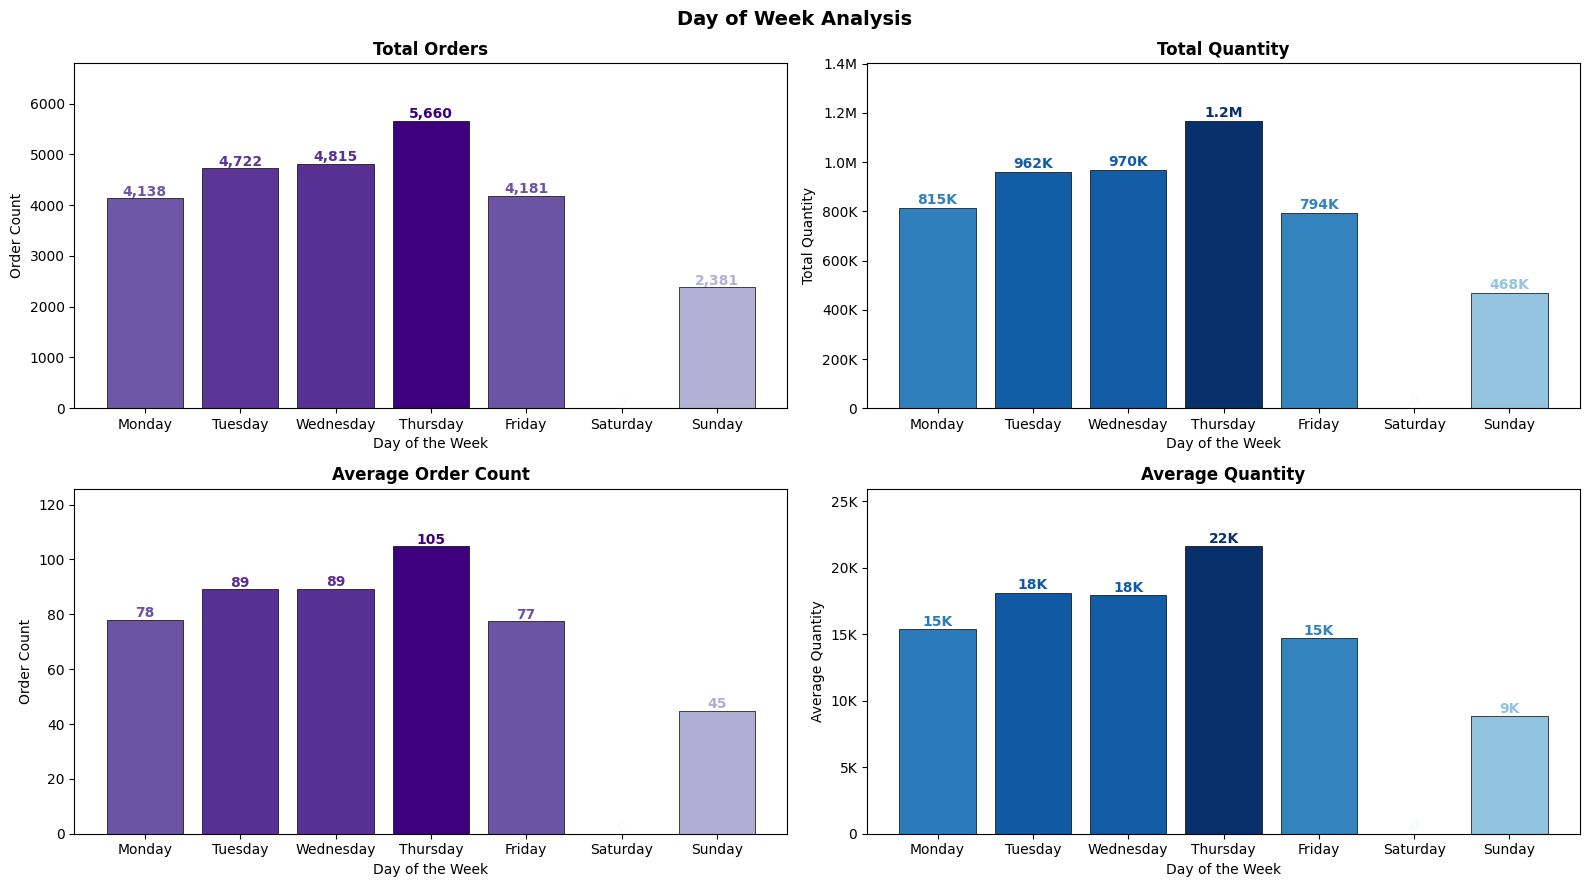

In [63]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# reindex fills missing days with NaN, fillna(0) for plotting
weekday_totals = weekday_totals.reindex(day_order).fillna(0)
weekday_avgs = weekday_avgs.reindex(day_order).fillna(0)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# --- Total Orders ---
cmap_purple = matplotlib.colormaps['Purples']
norm = mcolors.Normalize(vmin=weekday_totals['TotalOrders'].min() * 0.1,
                         vmax=weekday_totals['TotalOrders'].max())
colors = [cmap_purple(norm(val)) for val in weekday_totals['TotalOrders']]

axes[0, 0].bar(weekday_totals.index, weekday_totals['TotalOrders'],
               color=colors, linewidth=0.5, edgecolor='black')
axes[0, 0].set_xlabel('Day of the Week')
axes[0, 0].set_ylabel('Order Count')
axes[0, 0].set_title('Total Orders', fontweight='bold', fontsize=12)
axes[0, 0].set_ylim(top=weekday_totals['TotalOrders'].max() * 1.2)

for i, val in enumerate(weekday_totals['TotalOrders']):
    axes[0, 0].text(i, val + 50, s=f'{val:,.0f}', size=10,
                    color=colors[i], ha='center', fontweight='bold')

# --- Average Orders ---
norm = mcolors.Normalize(vmin=weekday_avgs['OrderCount'].min(),
                         vmax=weekday_avgs['OrderCount'].max())
colors = [cmap_purple(norm(val)) for val in weekday_avgs['OrderCount']]

axes[1, 0].bar(weekday_avgs.index, weekday_avgs['OrderCount'],
               color=colors, linewidth=0.5, edgecolor='black')
axes[1, 0].set_xlabel('Day of the Week')
axes[1, 0].set_ylabel('Order Count')
axes[1, 0].set_title('Average Order Count', fontweight='bold', fontsize=12)
axes[1, 0].set_ylim(top=weekday_avgs['OrderCount'].max() * 1.2)

for i, val in enumerate(weekday_avgs['OrderCount']):
    axes[1, 0].text(i, val + 1, s=f'{val:,.0f}', size=10,
                    color=colors[i], ha='center', fontweight='bold')

# --- Total Quantity ---
cmap_blue = matplotlib.colormaps['Blues']
norm = mcolors.Normalize(vmin=weekday_totals['TotalQuantity'].min() * 0.1,
                         vmax=weekday_totals['TotalQuantity'].max())
colors = [cmap_blue(norm(val)) for val in weekday_totals['TotalQuantity']]

axes[0, 1].bar(weekday_totals.index, weekday_totals['TotalQuantity'],
               color=colors, linewidth=0.5, edgecolor='black')
axes[0, 1].set_xlabel('Day of the Week')
axes[0, 1].set_ylabel('Total Quantity')
axes[0, 1].yaxis.set_major_formatter(FuncFormatter(format_axis))
axes[0, 1].set_ylim(top=weekday_totals['TotalQuantity'].max() * 1.2)
axes[0, 1].set_title('Total Quantity', fontweight='bold', fontsize=12)

for i, val in enumerate(weekday_totals['TotalQuantity']):
    axes[0, 1].text(i, val + 15000, ha='center', color=colors[i],
                    s=f'{format_axis(val, None)}', size=10, fontweight='bold')

# --- Average Quantity ---
norm = mcolors.Normalize(vmin=weekday_avgs['QuantitySum'].min(),
                         vmax=weekday_avgs['QuantitySum'].max())
colors = [cmap_blue(norm(val)) for val in weekday_avgs['QuantitySum']]

axes[1, 1].bar(weekday_avgs.index, weekday_avgs['QuantitySum'],
               color=colors, linewidth=0.5, edgecolor='black')
axes[1, 1].set_xlabel('Day of the Week')
axes[1, 1].set_ylabel('Average Quantity')
axes[1, 1].yaxis.set_major_formatter(FuncFormatter(format_axis))
axes[1, 1].set_ylim(top=weekday_avgs['QuantitySum'].max() * 1.2)
axes[1, 1].set_title('Average Quantity', fontweight='bold', fontsize=12)

for i, val in enumerate(weekday_avgs['QuantitySum']):
    axes[1, 1].text(i, val + 250, ha='center', color=colors[i],
                    s=f'{format_axis(val, None)}', size=10, fontweight='bold')

plt.suptitle('Day of Week Analysis', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### Key Findings
Strongest day is definitively Thursday by both order count and quantity. Saturday shows zero activity across all metrics, confirming warehouse or system operations are closed.
There is divergence between Tuesday and Wednesday — while positions 2nd and 3rd are close in both metrics, the order switches depending on what we measure. Wednesday leads on order count while Tuesday leads on quantity, could suggest that wholesale customers prefer Tuesday while retail customers prefer Wednesday, but difference is neglegible.
Friday, Monday and Sunday show different patterns from the weekday core. Sunday is notably weak on quantity, likely because wholesale customers do not operate on weekends.

**Areas for Further Exploration**

- Verify Tuesday/Wednesday wholesale vs retail hypothesis by analyzing average - order size per day
- Investigate Sunday orders — unexpected given Saturday closure, possibly driven by international customers
- Check Thursday dominance consistency across all months

## Hour of day pattern

   - Extract hour from InvoiceDate
   - When do people shop most?
   - Line plot showing hourly pattern


In [64]:
# hourly pattern — month included in aggregation for heatmap analysis later
hourly_orders = df.set_index('InvoiceDateTime').resample('h').agg(
    OrderCount=('InvoiceNo', 'nunique'),
    QuantitySum=('Quantity', 'sum')
)
hourly_orders['Hour'] = hourly_orders.index.hour
hourly_orders['Month'] = hourly_orders.index.month



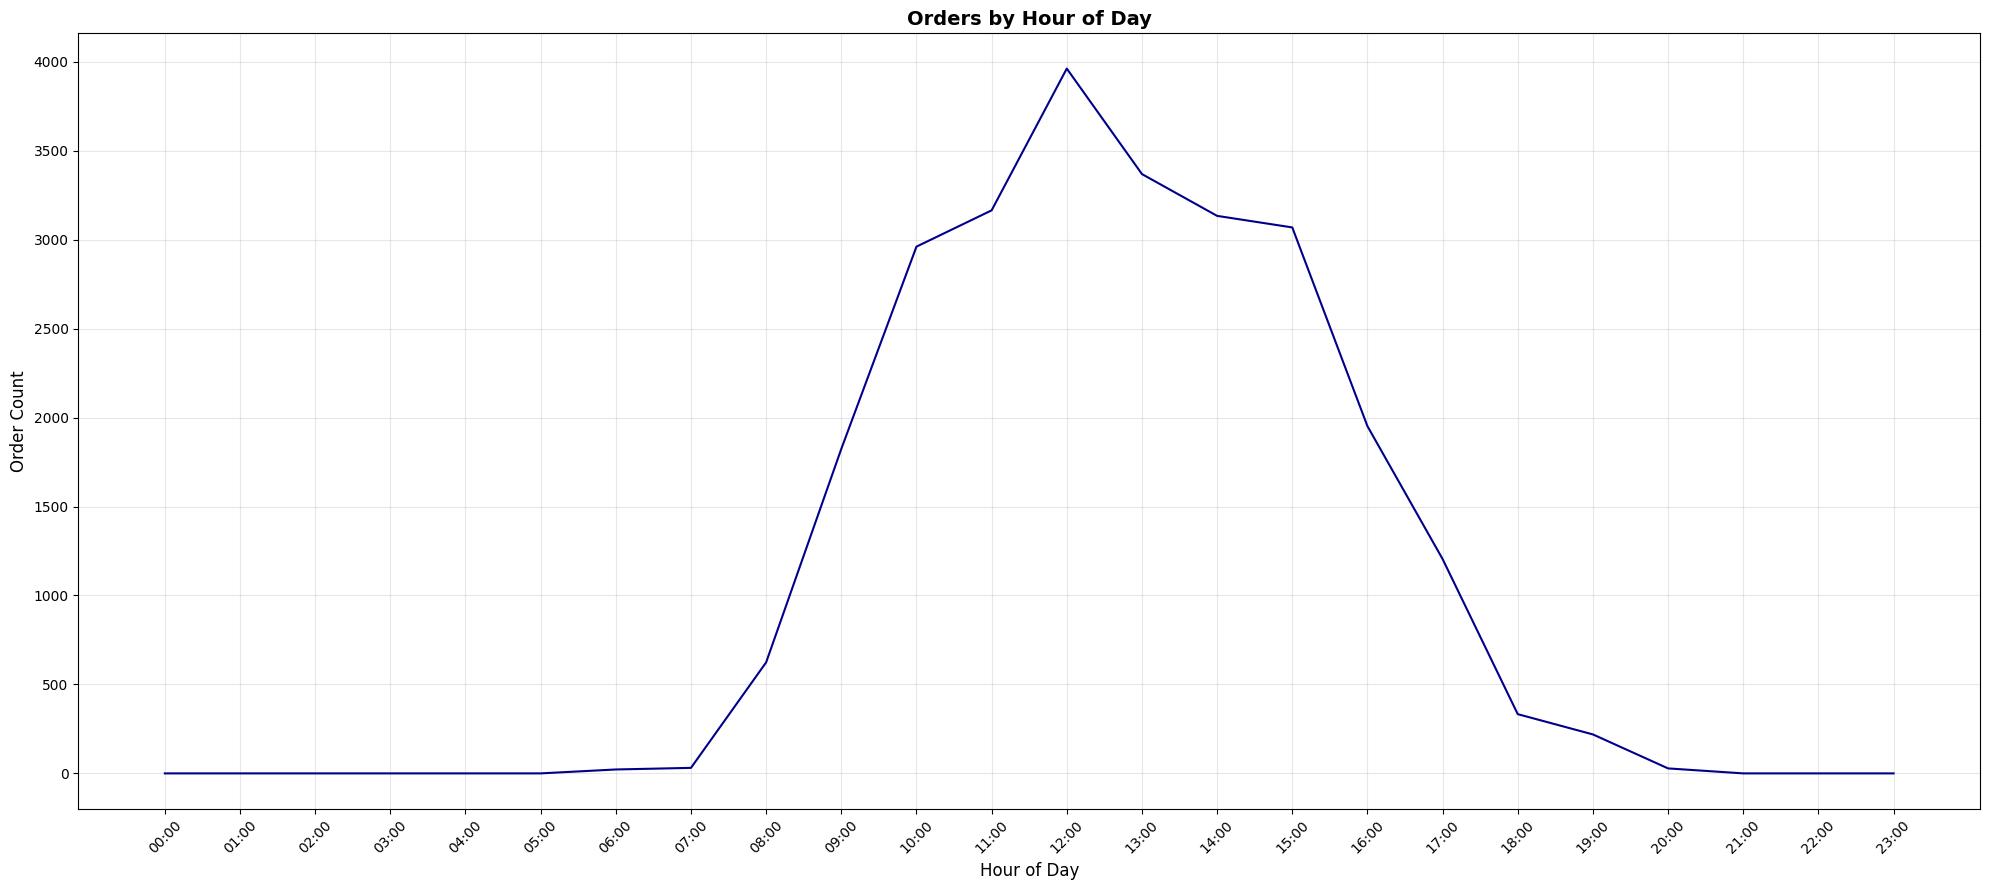

In [65]:
grouped_by_hour = hourly_orders.groupby('Hour')[['OrderCount', 'QuantitySum']].sum()

fig, ax = plt.subplots(figsize=(20, 9))

ax.plot(grouped_by_hour.index, grouped_by_hour['OrderCount'], color='darkblue')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Order Count', fontsize=12)
ax.set_title('Orders by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

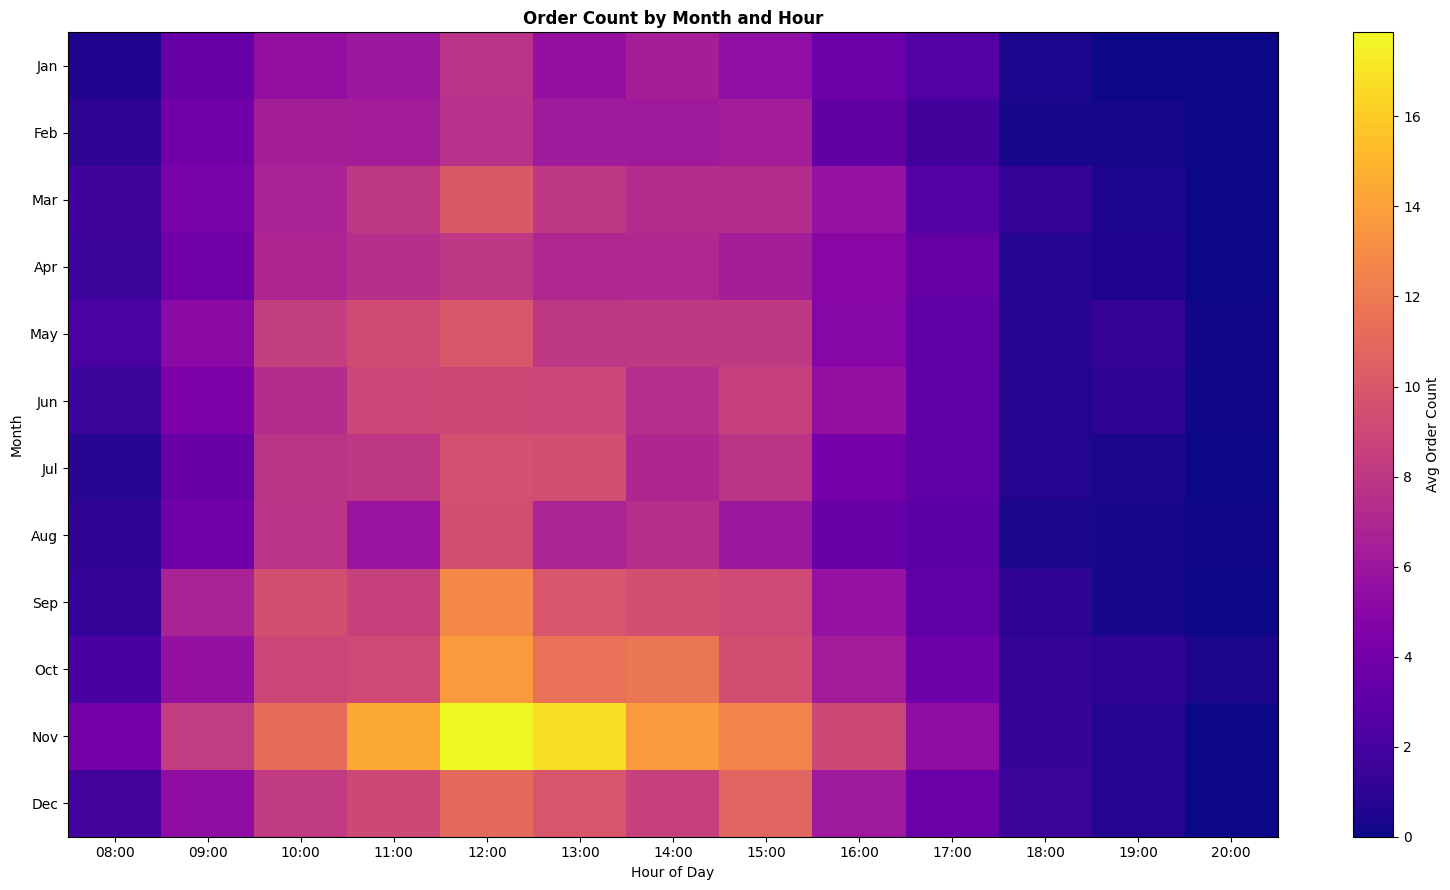

In [66]:
# filter out closed hours (before 8:00 and after 20:00)
hourly_filtered = hourly_orders[
    (hourly_orders['Hour'] >= 8) &
    (hourly_orders['Hour'] <= 20)
]

# group by month and hour for heatmap
month_hour = hourly_filtered.groupby(['Month', 'Hour'])['OrderCount'].mean().unstack()

fig, ax = plt.subplots(figsize=(16, 9))

# imshow returns mappable object needed for colorbar
# contains colormap, min/max values and color mapping
im = ax.imshow(month_hour, aspect='auto', cmap='plasma')

ax.set_xticks(range(len(month_hour.columns)))
ax.set_xticklabels([f'{h:02d}:00' for h in month_hour.columns])
ax.set_yticks(range(len(month_hour.index)))
ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

fig.colorbar(im, ax=ax, label='Avg Order Count')
ax.set_title('Order Count by Month and Hour', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Month')

plt.tight_layout()
plt.show()

### Key findings

- Business operates within a clear 07:00-20:00 window with meaningful activity concentrated between 09:00-17:00.
- Orders ramp up steeply through the morning, peak at 12:00, then decline more gradually through the afternoon — typical B2B ordering behavior.
- Activity after 18:00 is minimal, raising a valid question about whether late operations are justified by revenue generated.
- The heatmap reveals that Q4 (Sep-Nov) seasonality is visible even at hourly level, with higher intensity across all active hours, not just higher daily totals.


---



# CUSTOMER SEGMENTATION

1. **Calculate per customer:**
   - Total orders (count of invoices)
   - Total revenue (sum of TotalPrice)
   - Average order value
   - First and last purchase date
   - Customer lifespan (days between first and last)

2. **Create customer segments:**
   - High value: top 20% by revenue
   - Medium value: next 50%
   - Low value: bottom 30%

3. **Compare segments:**
   - Average order value per segment
   - Average number of orders per segment
   - Create box plots comparing segments
   - Statistical test: Is high value significantly different from medium?

4. **Top 10 customers:**
   - Who are they?
   - Which country?
   - How much did they spend?


## Customer Level Aggregations

In [67]:
# customer level agregations
customers = df.groupby('CustomerID').agg(
    TotalOrders = ('InvoiceNo', 'nunique'),
    TotalSpending = ('TotalPrice', 'sum'),
    FirstPurchase = ('InvoiceDateTime', 'min'),
    LastPurchase = ('InvoiceDateTime', 'max'),
    TotalQuantity = ('Quantity', 'sum')
    ).assign(
        AverageOrderValue = lambda x: x['TotalSpending']/x['TotalOrders'],
        CustomerLifespan =
        lambda x : (x['LastPurchase'] - x['FirstPurchase']).dt.days.clip(lower=1
                                                                         )
    ).round(2).sort_values(by='TotalSpending', ascending=False)
customers.head()


/var/folders/05/3xzngw_n6tv7wlp__kmhfjwh0000gn/T/ipykernel_89354/86242616.py:13: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ).round(2).sort_values(by='TotalSpending', ascending=False)


,TotalOrders,TotalSpending,FirstPurchase,LastPurchase,TotalQuantity,AverageOrderValue,CustomerLifespan
CustomerID,,,,,,,
14646,77,279489.02,2010-12-20 10:09:00,2011-12-08 12:12:00,196719,3629.73,353
18102,62,256438.49,2010-12-07 16:42:00,2011-12-09 11:50:00,64122,4136.10,366
17450,55,187482.17,2010-12-07 09:23:00,2011-12-01 13:29:00,69029,3408.77,359
14911,248,132572.62,2010-12-01 14:05:00,2011-12-08 15:54:00,77180,534.57,372
12415,26,123725.45,2011-01-06 11:12:00,2011-11-15 14:22:00,77242,4758.67,313


## Segmentation

In [68]:
low_value_limit = customers['TotalSpending'].quantile(0.3)
medium_value_limit = customers['TotalSpending'].quantile(0.8)

customers['Segment'] = pd.cut(customers['TotalSpending'],
                              bins=[-float('inf'), low_value_limit,
                                    medium_value_limit, float('inf')],
                              labels=['Low Value', 'Medium Value', 'High Value']
                              )

# to handle anonymous customers
customers['Segment'] = customers['Segment'].cat.add_categories('Unknown')
customers.loc[customers.index == 'Unknown', 'Segment'] = 'Unknown'
customers.head()



,TotalOrders,TotalSpending,FirstPurchase,LastPurchase,TotalQuantity,AverageOrderValue,CustomerLifespan,Segment
CustomerID,,,,,,,,
14646,77,279489.02,2010-12-20 10:09:00,2011-12-08 12:12:00,196719,3629.73,353,High Value
18102,62,256438.49,2010-12-07 16:42:00,2011-12-09 11:50:00,64122,4136.10,366,High Value
17450,55,187482.17,2010-12-07 09:23:00,2011-12-01 13:29:00,69029,3408.77,359,High Value
14911,248,132572.62,2010-12-01 14:05:00,2011-12-08 15:54:00,77180,534.57,372,High Value
12415,26,123725.45,2011-01-06 11:12:00,2011-11-15 14:22:00,77242,4758.67,313,High Value


## Segments Comparison



In [69]:
customer_segments = customers.groupby('Segment', observed=True).agg(
    TotalOrders=('TotalOrders', 'sum'),
    TotalSpending=('TotalSpending', 'sum'),
    CustomerCount=('TotalOrders', 'count')
).assign(
    AverageOrderValue=lambda x: x['TotalSpending'] / x['TotalOrders'],
    AverageCustomerValue=lambda x: x['TotalSpending'] / x['CustomerCount'],
    AverageNumberOfOrders=lambda x: x['TotalOrders'] / x['CustomerCount'],
    SegmentOrderShare = lambda x: x['TotalOrders'] / x['TotalOrders'].sum(),
    SegmentRevenueShare=lambda x: x['TotalSpending'] / x['TotalSpending'].sum()

).round(2)

# Unknown segment represents unregistered customers — customer-level metrics
# (AverageCustomerValue, CustomerCount) are not meaningful for this group
customer_segments['CustomerCount'] = customer_segments['CustomerCount'].astype('Int64')
customer_segments['AverageCustomerValue'] = customer_segments['AverageCustomerValue'].astype('Float64')

customer_segments.loc['Unknown', 'CustomerCount'] = pd.NA
customer_segments.loc['Unknown', 'AverageCustomerValue'] = pd.NA

In [70]:
customer_segments.info()

<class 'pandas.DataFrame'>
CategoricalIndex: 4 entries, Low Value to Unknown
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   TotalOrders            3 non-null      float64
 1   TotalSpending          3 non-null      float64
 2   CustomerCount          3 non-null      Int64  
 3   AverageOrderValue      3 non-null      float64
 4   AverageCustomerValue   3 non-null      Float64
 5   AverageNumberOfOrders  3 non-null      float64
 6   SegmentOrderShare      3 non-null      float64
 7   SegmentRevenueShare    3 non-null      float64
dtypes: Float64(1), Int64(1), float64(6)
memory usage: 588.0 bytes


In [71]:
customer_segments

,TotalOrders,TotalSpending,CustomerCount,AverageOrderValue,AverageCustomerValue,AverageNumberOfOrders,SegmentOrderShare,SegmentRevenueShare
Segment,,,,,,,,
Low Value,1911.0,233948.75,1312,122.42,178.31,1.46,0.09,0.03
Medium Value,7838.0,1936761.22,2185,247.10,886.39,3.59,0.35,0.23
High Value,12441.0,6129355.84,875,492.67,7004.98,14.22,0.56,0.74
Unknown,NaN,NaN,<NA>,NaN,<NA>,NaN,NaN,NaN


### Key Findings & Recommendations

**Segment Overview**
High Value segment (874 customers, 48% of orders) generates 63% of revenue with average
customer value of £7,011 and 14 orders per customer — confirming the Pareto pattern
identified in product analysis.

**Unknown Customers — Significant Gap**
Unregistered customers represent 14% of orders and 15% of revenue (£1.46M) — a substantial
portion of the business operating without customer identity. Customer-level metrics such as
average customer value and order frequency are unavailable for this group, limiting retention
and personalisation capabilities.

**Recommendation:** Introduce incentives for customer registration to improve coverage:
- Discount on first registered order
- Loyalty programme accessible only to registered customers
- Personalised recommendations based on purchase history

Converting even 50% of unknown customers to registered would add ~1,850 trackable customers
to the database, significantly improving segmentation accuracy and enabling targeted
marketing campaigns.

In [72]:
customers['TotalSpending'].skew()

np.float64(21.70528691556265)

## Segment Validation — Statistical Testing

Two complementary tests to validate the segmentation and understand what drives differences between segments:

- **ANOVA** — validates whether all three segments are genuinely distinct or if the percentile-based boundaries are arbitrary
- **Mann-Whitney U** — drills into the specific High vs Medium boundary to understand *why* they differ

**Why not test TotalSpending?**
Segments are defined by spending percentiles so they are different by construction — testing it would be circular reasoning. `AverageOrderValue` is the more meaningful metric as it is independent of segmentation criteria and reveals whether the difference is driven by order size or order frequency.

**Why Mann-Whitney U instead of t-test?**
Customer spending data is heavily right-skewed (skewness = 55.3) with extreme outliers from wholesale customers. T-test assumes normal distribution and is sensitive to outliers — Mann-Whitney U is non-parametric, makes no distribution assumptions and is robust to skew, making it the appropriate choice for this dataset.

**Interpretation framework:**

- ANOVA significant → segmentation boundaries are meaningful, segments represent genuinely distinct customer behaviours
- `AverageOrderValue` significant → High Value customers place bigger individual orders
- `AverageOrderValue` not significant → difference driven purely by order frequency, not order size — important distinction for retention and marketing strategy

In [73]:
low_value_customers = customers[customers['Segment'] == 'Low Value']
medium_value_customers = customers[customers['Segment'] == 'Medium Value']
high_value_customers = customers[customers['Segment'] == 'High Value']

In [74]:
f_stat, p_value = f_oneway(low_value_customers['AverageOrderValue'],
                         medium_value_customers['AverageOrderValue'],
                         high_value_customers['AverageOrderValue'])
print(f'ANOVA p-value: {p_value:.2e}')

ANOVA p-value: 1.84e-166


In [75]:
# check actual differences alongside p-value
customers.groupby('Segment', observed=True)['AverageOrderValue'].median()

Segment
Low Value       139.18
Medium Value    268.63
High Value      384.58
Name: AverageOrderValue, dtype: float64

**ANOVA** p-value ≈ 0 (`5.24 × 10⁻¹⁶⁵`)
— all three segments are statistically distinct in
`AverageOrderValue`. The percentile-based segmentation boundaries are meaningful and
represent genuinely different customer behaviours, not arbitrary splits.


**Mann-Whitney U** between Medium and High Value segments was considered but deemed unnecessary —
ANOVA already confirmed all three segments are statistically distinct (p ≈ 0) and median
AverageOrderValue differences are large enough to be practically meaningful (£269 vs £385).
Additional pairwise testing would be redundant.

### Box Plot

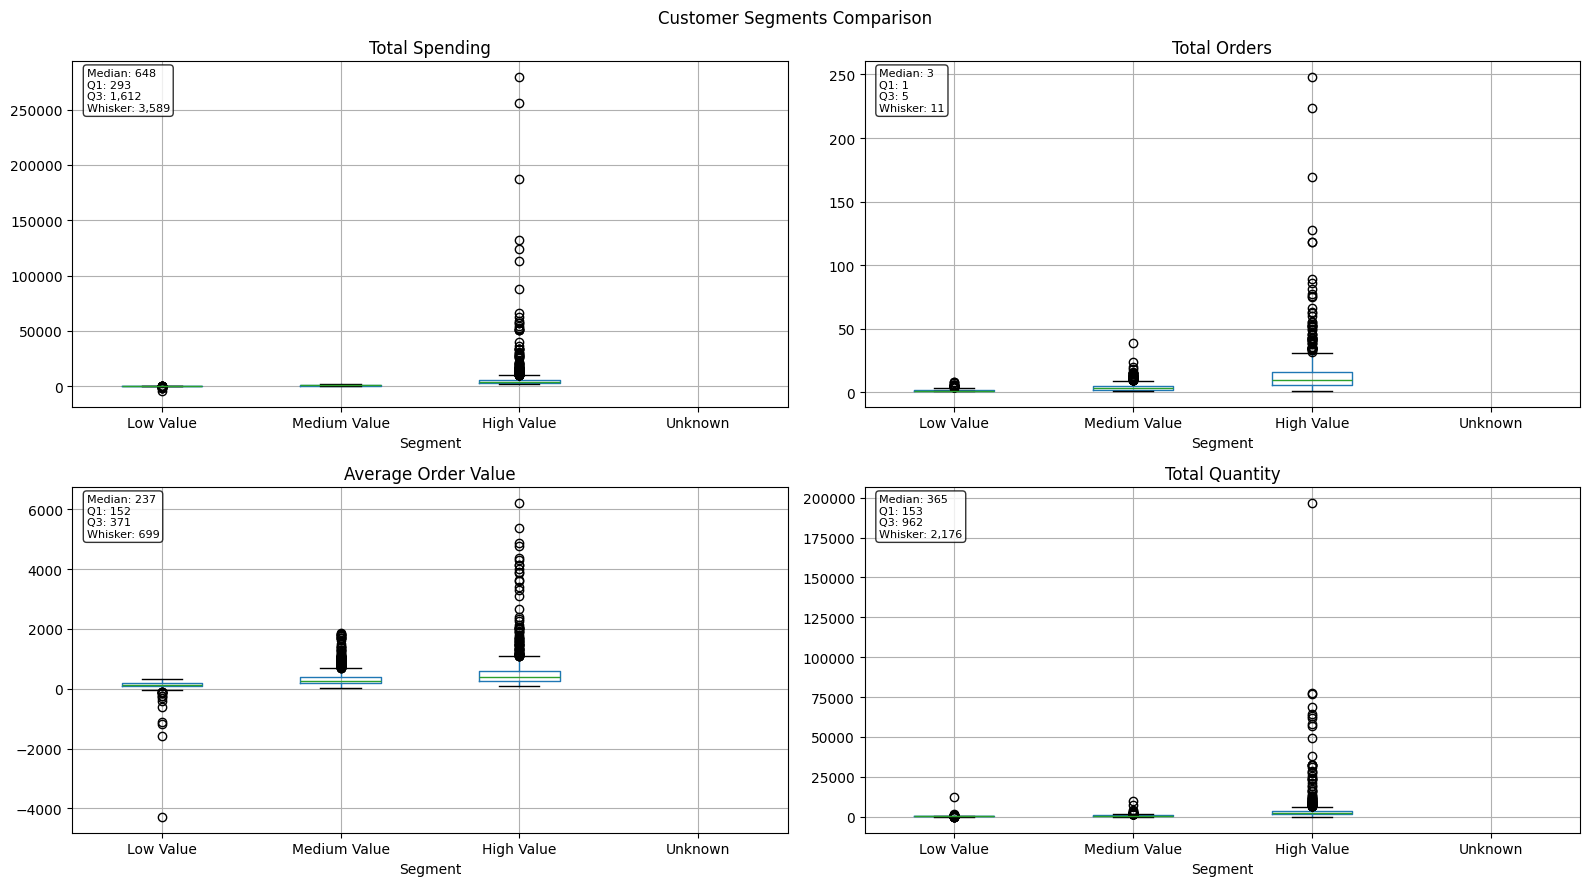

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

metrics = ['TotalSpending', 'TotalOrders', 'AverageOrderValue', 'TotalQuantity']
titles = ['Total Spending', 'Total Orders', 'Average Order Value',
          'Total Quantity']

for ax, metric, title in zip(axes.flat, metrics, titles):

  # we need to filter out uknowns
  customers[customers.index !='Unknown'].boxplot(column=metric, by='Segment', ax=ax)
  ax.set_title(title)
  ax.set_xlabel('Segment')

  # to add stats to charts:
  q1 = customers[metric].quantile(0.25)
  q3 = customers[metric].quantile(0.75)
  iqr = q3 - q1
  median = customers[metric].median()

  stats_text = (
      f'Median: {median:,.0f}\n'
      f'Q1: {q1:,.0f}\nQ3: {q3:,.0f}\n'
      f'Whisker: {q3 + 1.5*iqr:,.0f}'
      )

  ax.text(0.02, 0.98, stats_text,
          transform=ax.transAxes,  # position relative to axes not data
          verticalalignment='top',
          fontsize=8,
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Customer Segments Comparison')
plt.tight_layout()
plt.show()


High Value segment shows extremely wide spread across all metrics, likely caused by mixing wholesale and retail customers within the same segment. Let's investigate metric distributions of high value segment further to see if we can distinguish these fundamentally different customer types.

Number of unique products could be another useful metric, but it is partially reflected in total orders so we'll stick with the existing ones to avoid redundancy.

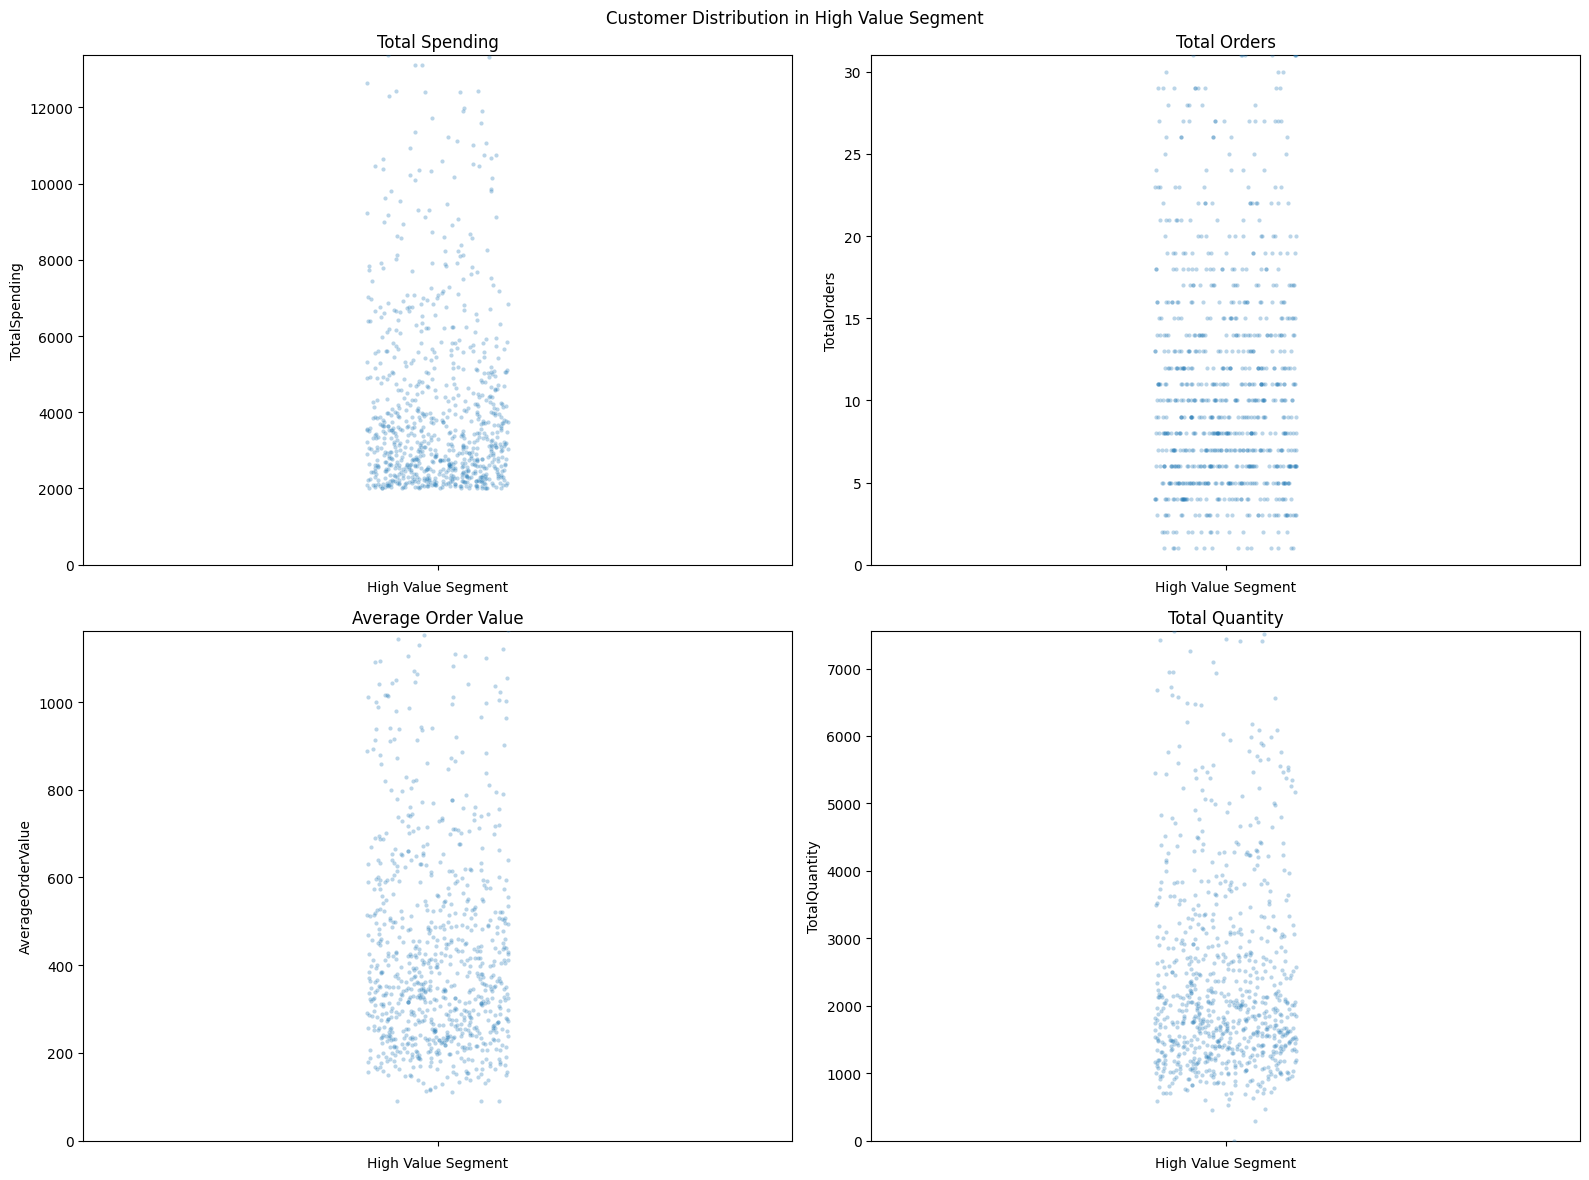

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['TotalSpending', 'TotalOrders', 'AverageOrderValue', 'TotalQuantity']
titles = ['Total Spending', 'Total Orders', 'Average Order Value', 'Total Quantity']

customers_clean = customers[(customers.index != 'Unknown') &
 (customers['Segment'] == 'High Value')]

for ax, metric, title in zip(axes.flat, metrics, titles):

    sns.stripplot(data=customers_clean,
                  y=metric,
                  alpha=0.3,
                  size=3,
                  ax=ax)
    # ax.set_yscale('log') # log scale to see full distribution
    ax.set_title(title)
    ax.set_xlabel('High Value Segment')
    ax.set_ylim(0, customers_clean[metric].quantile(0.93))

plt.suptitle('Customer Distribution in High Value Segment')
plt.tight_layout()
plt.show()


Note: Wholesale/retail classification thresholds are based on visual inspection of the High Value segment distribution (TotalSpending > £5,000, TotalOrders > 20, AverageOrderValue > £500, TotalQuantity > 3000).

These thresholds are indicative only — proper segmentation would require stakeholder input to define business rules, ideally with an explicit customer type flag in the source system.

In [78]:
customers['CustomerType'] = np.where(
    (customers['TotalSpending'] > 5000) |
    (customers['TotalOrders'] > 20) |
    (customers['AverageOrderValue'] > 500) |
    (customers['TotalQuantity'] > 3000),
    'Wholesale',
    'Retail'
)

print(customers['CustomerType'].value_counts())
print('')
print(customers['CustomerType'].value_counts(normalize=True).map(
    '{:.1%}'.format))

CustomerType
Retail       3591
Wholesale     781
Name: count, dtype: int64

CustomerType
Retail       82.1%
Wholesale    17.9%
Name: proportion, dtype: str


Note: Nearly 18% of all customers meet at least one condition to be flagged as wholesale — accounting for the majority of the High Value segment, which represents the top 20% of customers by spending.

## Clustering experiment

### Elbow Method

Elbow method finds the optimal number of clusters by measuring how tight the clusters are (inertia) for different values of K.

**Inertia** — sum of squared distances from each point to its cluster centroid. Lower = tighter, more compact clusters.

Example:
```
Inertia
│
1000 ●
 800   ●
 400     ●  ← big drop, meaningful
 350       ●  ← small drop
 340         ●  ← diminishing returns, elbow here
 335           ●
              K→  1  2  3  4  5  6
```

K=N → inertia = 0 (every point is its own cluster, useless)

You plot inertia vs K and look for the "elbow" — the point where adding more clusters stops giving meaningful improvement.

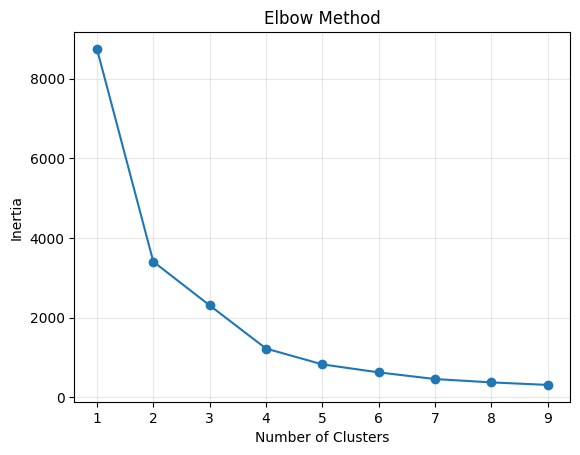

In [79]:
customers_clean = customers[customers.index != 'Unknown'].copy()

# select features
X = customers_clean[['TotalSpending', 'TotalQuantity']]

# scale - essential for KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# elbow method first
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True, alpha=0.3)
plt.show()

### Elbow Method — Results

The elbow chart shows two potential breakpoints:

- **K=2** — largest single inertia drop, suggesting a simple binary split likely corresponding to low vs high value customers
- **K=4** — curve visibly flattens after this point, suggesting more granular natural groupings

Let's check K=4 as it potentially maps to a more meaningful business segmentation (low/medium/high value retail + wholesale) but we need to check size of cluster to see if it really makes sense, K=2 can be better option in the end.

In [80]:
# explore model with K=4
kmeans = KMeans(n_clusters=4, random_state=42)
customers_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# check cluster sizes and share
pd.DataFrame({
    'Count': customers_clean['Cluster'].value_counts().sort_index(),
    'Share': customers_clean['Cluster'].value_counts(normalize=True).sort_index().map('{:.1%}'.format)
})

,Count,Share
Cluster,,
0,4337,99.2%
1,6,0.1%
2,1,0.0%
3,28,0.6%


In [81]:
# final model with K=2
kmeans = KMeans(n_clusters=2, random_state=42)
customers_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# check clustrers sizes
pd.DataFrame({
    'Count': customers_clean['Cluster'].value_counts().sort_index(),
    'Share': customers_clean['Cluster'].value_counts(normalize=True).sort_index().map('{:.1%}'.format)
})

,Count,Share
Cluster,,
0,4362,99.8%
1,10,0.2%


In [82]:
customers_clean[customers_clean['Cluster'] == 1][['TotalSpending', 'TotalQuantity',
                                                    'TotalOrders', 'AverageOrderValue']].sort_values('TotalSpending', ascending=False)

,TotalSpending,TotalQuantity,TotalOrders,AverageOrderValue
CustomerID,,,,
14646,279489.02,196719,77,3629.73
18102,256438.49,64122,62,4136.10
17450,187482.17,69029,55,3408.77
14911,132572.62,77180,248,534.57
12415,123725.45,77242,26,4758.67
14156,113384.14,57025,66,1717.94
17511,88125.38,63012,46,1915.77
16684,65892.08,49390,31,2125.55
13694,62653.10,61803,60,1044.22


In [83]:
customers_clean[customers_clean['Cluster'] == 0].sort_values('TotalSpending', ascending=False).iloc[:1]


,TotalOrders,TotalSpending,FirstPurchase,LastPurchase,TotalQuantity,AverageOrderValue,CustomerLifespan,Segment,CustomerType,Cluster
CustomerID,,,,,,,,,,
15311,118,59419.34,2010-12-01 09:41:00,2011-12-09 12:00:00,37720,503.55,373,High Value,Wholesale,0


### Experiment Conclusion

KMeans clustering on `TotalSpending` and `TotalQuantity` confirms the absence of
a natural boundary between customer groups — both K=2 and K=4 simply isolated
extreme outliers rather than finding meaningful segments. This reinforces that
wholesale/retail distinction requires business-defined thresholds rather than
a data-driven approach.

## Top 10 customers

- Who are they?
- Which country?
- How much did they spend?

In [84]:
top_customers = customers_clean.sort_values(by= 'TotalSpending', ascending=False).iloc[:10]
top_customers

,TotalOrders,TotalSpending,FirstPurchase,LastPurchase,TotalQuantity,AverageOrderValue,CustomerLifespan,Segment,CustomerType,Cluster
CustomerID,,,,,,,,,,
14646,77,279489.02,2010-12-20 10:09:00,2011-12-08 12:12:00,196719,3629.73,353,High Value,Wholesale,1
18102,62,256438.49,2010-12-07 16:42:00,2011-12-09 11:50:00,64122,4136.10,366,High Value,Wholesale,1
17450,55,187482.17,2010-12-07 09:23:00,2011-12-01 13:29:00,69029,3408.77,359,High Value,Wholesale,1
14911,248,132572.62,2010-12-01 14:05:00,2011-12-08 15:54:00,77180,534.57,372,High Value,Wholesale,1
12415,26,123725.45,2011-01-06 11:12:00,2011-11-15 14:22:00,77242,4758.67,313,High Value,Wholesale,1
14156,66,113384.14,2010-12-02 17:08:00,2011-11-30 10:54:00,57025,1717.94,362,High Value,Wholesale,1
17511,46,88125.38,2010-12-01 10:19:00,2011-12-07 10:12:00,63012,1915.77,370,High Value,Wholesale,1
16684,31,65892.08,2010-12-16 17:34:00,2011-12-05 14:06:00,49390,2125.55,353,High Value,Wholesale,1
13694,60,62653.10,2010-12-01 12:12:00,2011-12-06 09:32:00,61803,1044.22,369,High Value,Wholesale,1


In [85]:
# lets check if top customers are doing orders within the same country
top_customers_countries = df[df['CustomerID'].isin(
    top_customers.index)].groupby('CustomerID').agg(Countries = (
        'Country', lambda x: ', '.join(x.unique())))
top_customers_countries

,Countries
CustomerID,
12415,Australia
13694,United Kingdom
14156,Ireland
14646,Netherlands
14911,Ireland
15311,United Kingdom
16684,United Kingdom
17450,United Kingdom
17511,United Kingdom


In [86]:
top_customers = top_customers.join(top_customers_countries, on='CustomerID')


In [87]:
top_customers[['TotalSpending', 'Countries']]

,TotalSpending,Countries
CustomerID,,
14646,279489.02,Netherlands
18102,256438.49,United Kingdom
17450,187482.17,United Kingdom
14911,132572.62,Ireland
12415,123725.45,Australia
14156,113384.14,Ireland
17511,88125.38,United Kingdom
16684,65892.08,United Kingdom
13694,62653.10,United Kingdom


Top 10 customers origin is dominated by UK, but biggest customer comes from Netherlands! There is also Irland and Australia.

In [88]:
print(f'Top 10 customer share in total revenue is {top_customers['TotalSpending'].sum()/customers['TotalSpending'].sum():.2%}')

Top 10 customer share in total revenue is 16.50%




---



# PRODUCT ANALYSIS

1. **Top 10 products by:**
   - Quantity sold
   - Revenue generated
   - Are they the same products?

2. **Price analysis:**
   - What's the average UnitPrice?
   - Create histogram of UnitPrice
   - Any products with unusually high prices?

3. **Product portfolio:**
   - How many unique products?
   - What percentage of products generate 80% of revenue?
   - (This is the Pareto principle!)


In [89]:
products = df[df['IsProduct']== True].groupby(['StockCode','Description']).agg(
    TotalQuantity = ('Quantity', 'sum'),
    TotalPrice = ('TotalPrice', 'sum'))

In [90]:
products.head()

TotalQuantity  TotalPrice
StockCode Description                                           
10002     INFLATABLE POLITICAL GLOBE             860      759.89
10080     GROOVY CACTUS INFLATABLE               303      119.09
          check                                   22        0.00
10120     DOGGY RUBBER                           193       40.53
10125     MINI FUNKY DESIGN TAPES               1296      994.84

In [91]:
products.shape

(4777, 2)

In [92]:
# to check if StockCode is unique
products.index.nunique()

4777

In [93]:
# lets remove description from goupby to avoid multiindexing
# and add average Unit Price to avoid incorrect average calculation( avg of avg)
# and  also average price per order

products = df[(df['IsReturn'] == False) & (df['IsProduct'] == True)].groupby('StockCode').agg(
    TotalPrice=('TotalPrice', 'sum'),
    TotalQuantity=('Quantity', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique'),
    Description=('Description', 'first')
).assign(AverageUnitPrice = lambda x: x['TotalPrice'] / x['TotalQuantity']
         ).round(2)

### Top 10 Products

In [94]:
# top 10 by Revenue
top_revenue_products = products['TotalPrice'].sort_values(ascending=False).iloc[:10]

In [95]:
top_revenue_products

StockCode
22423     174484.74
23843     168469.60
85123A    104518.80
47566      99504.33
85099B     94340.05
23166      81700.92
23084      66964.99
22086      64952.29
84879      59094.93
79321      54117.76
Name: TotalPrice, dtype: float64

In [96]:
# top ten by quantity
top_quantity_products = products['TotalQuantity'].sort_values(ascending=False).iloc[:10]

In [97]:
# find overlap
revenue_set = set(top_revenue_products.index)
quantity_set = set(top_quantity_products.index)
overlap = revenue_set & quantity_set
revenue_only = revenue_set - quantity_set
quantity_only = quantity_set - revenue_set

print(f'In both top 10: {overlap}')
print(f'Top revenue only: {revenue_only}')
print(f'Top quantity only: {quantity_only}')

In both top 10: {23843, '85099B', 23084, 84879, '85123A', 23166}
Top revenue only: {79321, 47566, 22086, 22423}
Top quantity only: {21212, 22492, 84077, 22197}


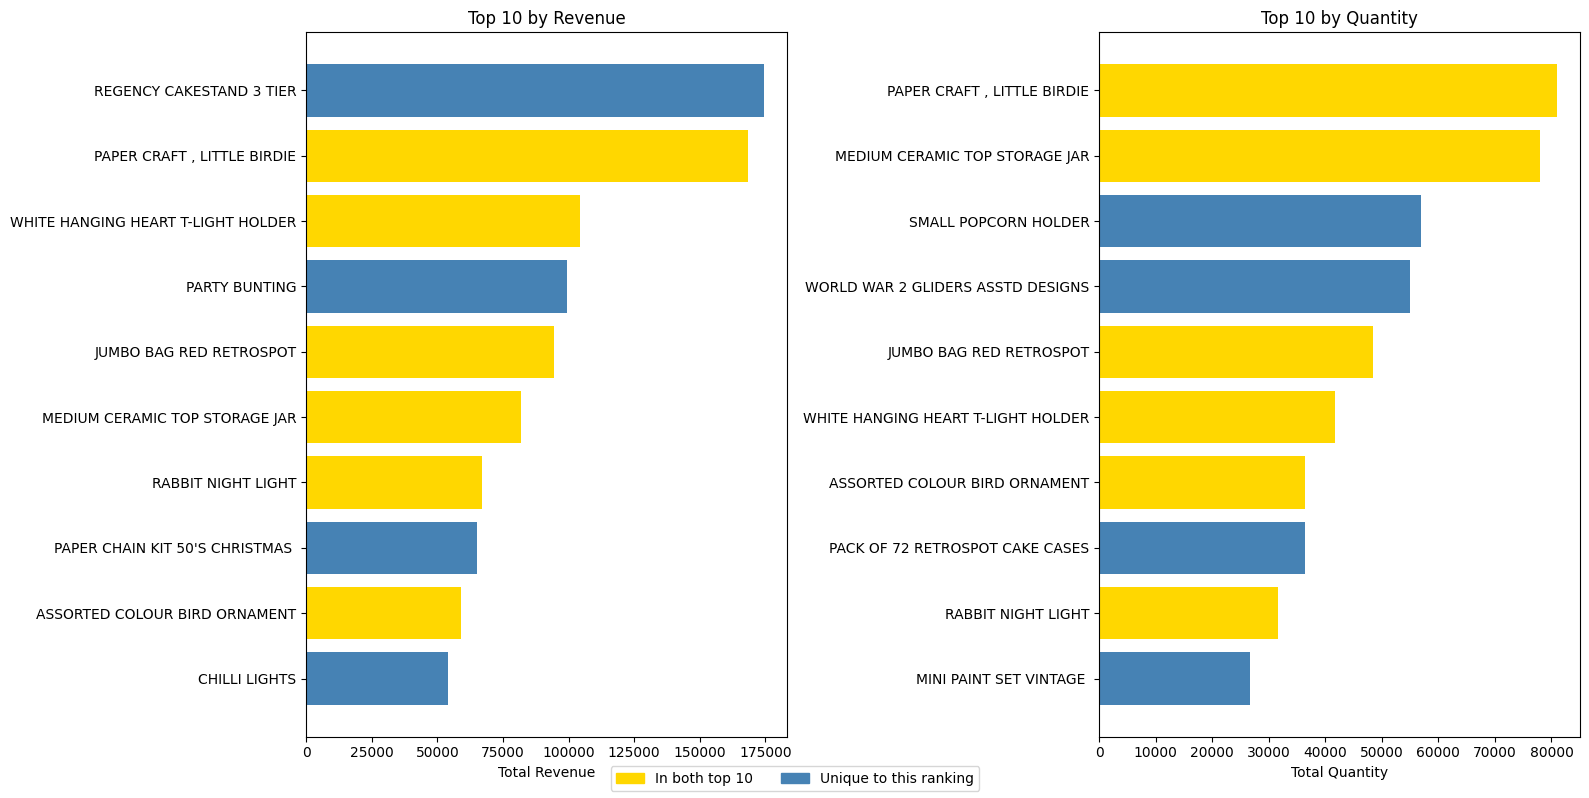

In [98]:
top_revenue_products = (products['TotalPrice']
                        .sort_values(ascending=True)
                        .iloc[-10:]
                        .to_frame()
                        .join(products['Description']))

top_quantity_products = (products['TotalQuantity']
                         .sort_values(ascending=True)
                         .iloc[-10:]
                         .to_frame()
                         .join(products['Description']))

revenue_set = set(top_revenue_products.index)
quantity_set = set(top_quantity_products.index)
overlap = revenue_set & quantity_set


fig, axes = plt.subplots(1, 2, figsize=(16, 8))

colors_rev = ['gold' if p in overlap else 'steelblue' for p in top_revenue_products.index]
colors_qty = ['gold' if p in overlap else 'steelblue' for p in top_quantity_products.index]

# Revenue chart
axes[0].barh(range(len(top_revenue_products)),
             top_revenue_products['TotalPrice'],
             color=colors_rev)
axes[0].set_yticks(range(len(top_revenue_products)))
axes[0].set_yticklabels(top_revenue_products['Description'])
axes[0].set_title('Top 10 by Revenue')
axes[0].set_xlabel('Total Revenue')

# Quantity chart
axes[1].barh(range(len(top_quantity_products)),
             top_quantity_products['TotalQuantity'],
             color=colors_qty)
axes[1].set_yticks(range(len(top_quantity_products)))
axes[1].set_yticklabels(top_quantity_products['Description'])
axes[1].set_title('Top 10 by Quantity')
axes[1].set_xlabel('Total Quantity')

legend = [Patch(color='gold', label='In both top 10'),
          Patch(color='steelblue', label='Unique to this ranking')]
fig.legend(handles=legend, loc='lower center', ncol=2)

plt.tight_layout()
plt.show()

50% overlap between top 10 revenue and quantity rankings.
High revenue/low quantity products suggest premium pricing strategy.
High quantity/low revenue products are likely low-margin bulk items.
Products appearing in both rankings represent core catalogue priorities.

### Price Analysis

- What's the average UnitPrice?
- Create histogram of UnitPrice
- Any products with unusually high prices?

In [99]:

# again we have to calculate avoid avg of avgs
# correct way to calculate average unit price is total
# revenue/total quantity for all products
print(f'Average Unit Price: £{products["TotalPrice"].sum()/products["TotalQuantity"].sum():.2f}')




Average Unit Price: £1.82


In [100]:
# prepare unit price data

unit_price = df[(df['IsReturn'] == False) & df['IsProduct'] == True].groupby('UnitPrice').agg(Frequency = ('Quantity', 'sum'))
unit_price.head()

,Frequency
UnitPrice,
0.000,68175
0.001,3
0.040,8600
0.060,14008
0.070,3280


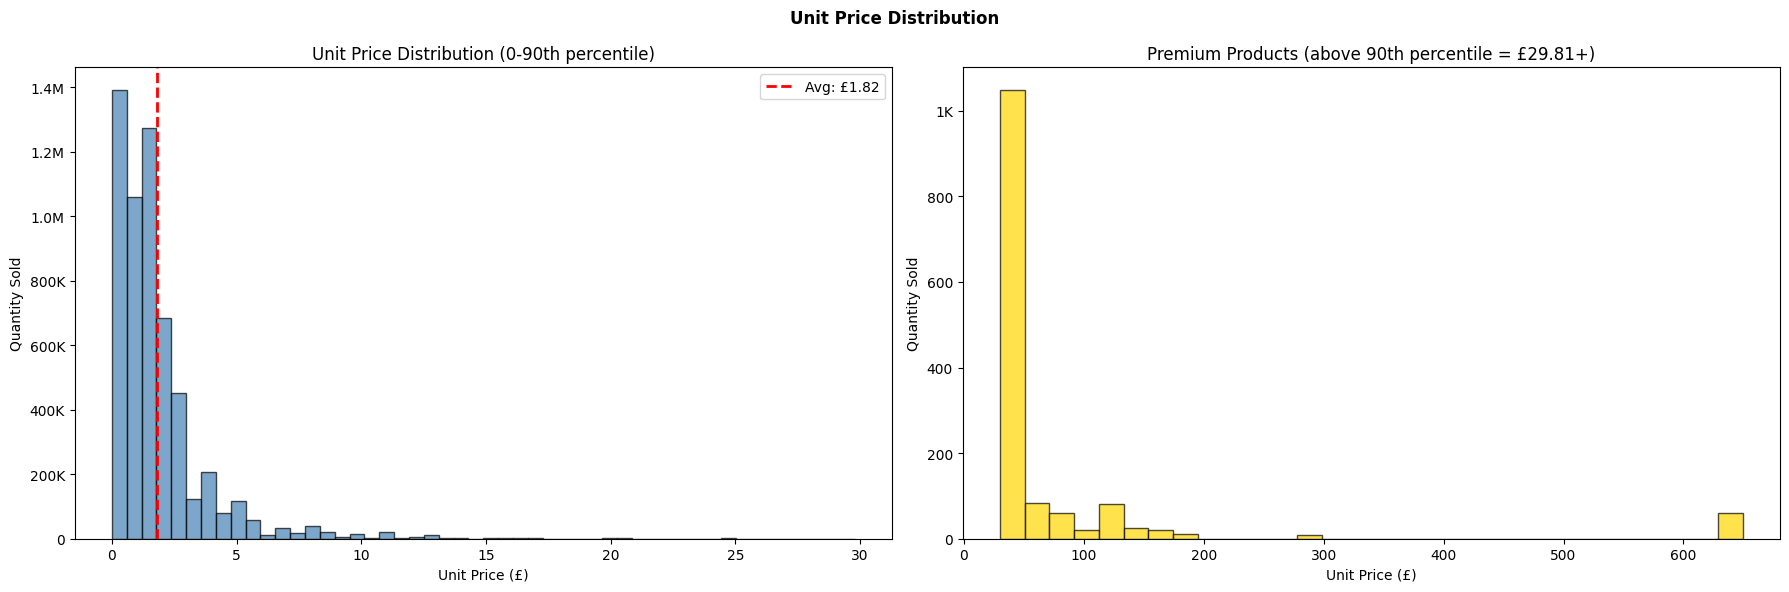

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

avg_unit_price = products['TotalPrice'].sum() / products['TotalQuantity'].sum()
p90 = unit_price.index.to_series().quantile(0.90)

def format_axis(x, p):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x/1_000:.0f}K'
    return f'{x:.0f}'

# main distribution - 0 to 90th percentile
normal = unit_price[unit_price.index <= p90]
axes[0].hist(normal.index, weights=normal['Frequency'],
             bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(avg_unit_price, color='red', linestyle='dashed',
                linewidth=2, label=f'Avg: £{avg_unit_price:.2f}')
axes[0].set_title('Unit Price Distribution (0-90th percentile)')
axes[0].set_xlabel('Unit Price (£)')
axes[0].set_ylabel('Quantity Sold')
axes[0].legend()

formatter = FuncFormatter(format_axis)
axes[0].yaxis.set_major_formatter(formatter)
axes[1].yaxis.set_major_formatter(formatter)

# premium products - above 90th percentile
premium = unit_price[unit_price.index > p90]
axes[1].hist(premium.index, weights=premium['Frequency'],
             bins=30, color='gold', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Premium Products (above 90th percentile = £{p90:.2f}+)')
axes[1].set_xlabel('Unit Price (£)')
axes[1].set_ylabel('Quantity Sold')

plt.suptitle('Unit Price Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

In [102]:
# sanity check of expensive products
df[(df['UnitPrice'] > 200) & (df['IsProduct'] == True) & (df['IsReturn'] == False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDateTime,UnitPrice,CustomerID,Country,TotalPrice,IsReturn,IsProduct,Month,Day,Hour,InvoiceDate,YearMonth,DayOfWeek
4989,536835,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-02 18:06:00,295.0,13145,United Kingdom,295.0,False,True,12,2,18,2010-12-02,2010-12,Thursday
32484,539080,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-16 08:41:00,295.0,16607,United Kingdom,295.0,False,True,12,16,8,2010-12-16,2010-12,Thursday
51636,540647,22655,VINTAGE RED KITCHEN CABINET,1,2011-01-10 14:57:00,295.0,17406,United Kingdom,295.0,False,True,1,10,14,2011-01-10,2011-01,Monday
82768,543253,22655,VINTAGE RED KITCHEN CABINET,1,2011-02-04 15:32:00,295.0,14842,United Kingdom,295.0,False,True,2,4,15,2011-02-04,2011-02,Friday
118769,546480,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-03-14 11:38:00,295.0,13452,United Kingdom,295.0,False,True,3,14,11,2011-03-14,2011-03,Monday
133994,547814,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-03-25 14:19:00,295.0,13452,United Kingdom,295.0,False,True,3,25,14,2011-03-25,2011-03,Friday
171178,551393,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-04-28 12:22:00,295.0,14973,United Kingdom,295.0,False,True,4,28,12,2011-04-28,2011-04,Thursday
205759,554836,22655,VINTAGE RED KITCHEN CABINET,1,2011-05-26 16:25:00,295.0,13015,United Kingdom,295.0,False,True,5,26,16,2011-05-26,2011-05,Thursday
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.5,15098,United Kingdom,38970.0,False,True,6,10,15,2011-06-10,2011-06,Friday
222682,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,2011-06-10 15:33:00,649.5,15098,United Kingdom,649.5,False,True,6,10,15,2011-06-10,2011-06,Friday


There are 2 significantly more expensive products than the rest, however the prices appear legitimate — both are premium gift products consistent with their descriptions and have multiple orders recorded, ruling out data entry errors.

### Product portfolio

- How many unique products?
- What percentage of products generate 80% of revenue?
(Pareto principle)

In [103]:
# sort products by revenue descending
products_sorted = products['TotalPrice'].sort_values(ascending=False)

# calculate cumulative revenue share
cumulative_share = products_sorted.cumsum() / products_sorted.sum()

# find how many products needed to reach 80%
#creates a boolean Series, sum takes True as 1
products_80 = (cumulative_share <= 0.8).sum()

total_products = len(products_sorted)

print(f'Products to reach 80% revenue: {products_80}')
print(f'Total products: {total_products}')
print(f'Share of catalogue: {products_80/total_products:.1%}')

Products to reach 80% revenue: 825
Total products: 3928
Share of catalogue: 21.0%


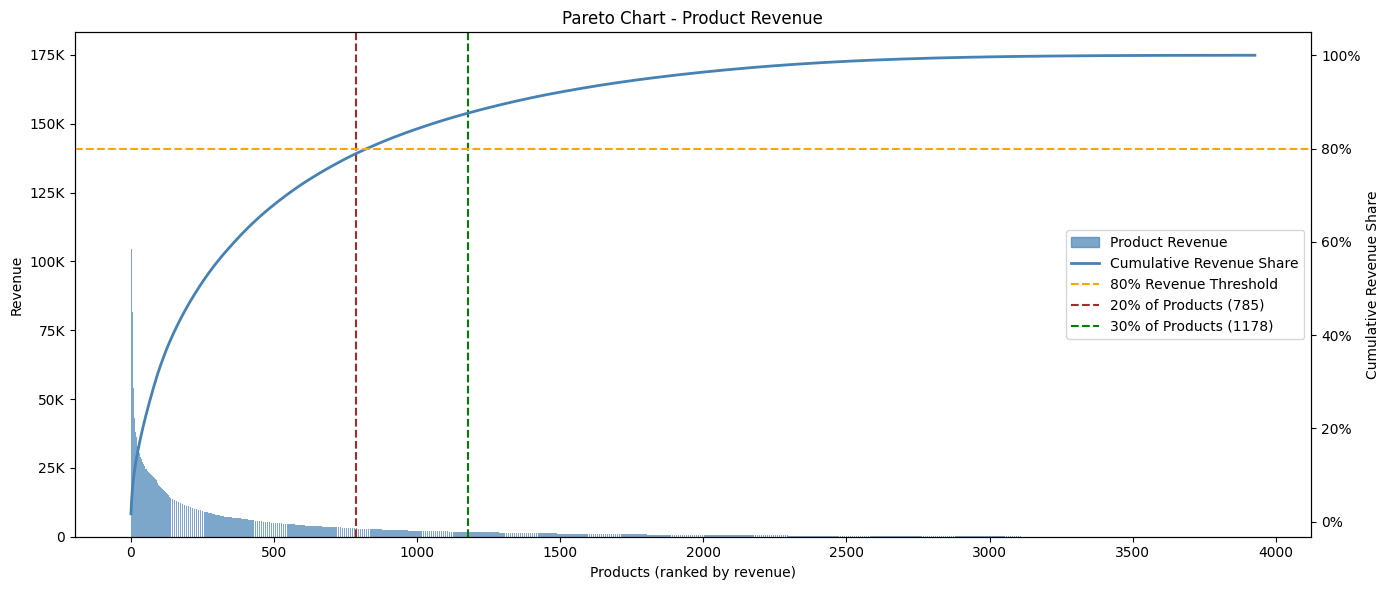

In [104]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(range(len(products_sorted)), products_sorted.values,
        color='steelblue', alpha=0.7)
ax1.set_xlabel('Products (ranked by revenue)')
ax1.set_ylabel('Revenue')
ax1.yaxis.set_major_formatter(FuncFormatter(format_axis))

ax2 = ax1.twinx()
ax2.plot(range(len(products_sorted)), cumulative_share.values,
         color='steelblue', linewidth=2)
ax2.axhline(0.8, color='orange', linestyle='dashed', linewidth=1.5)
ax2.set_ylabel('Cumulative Revenue Share')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.0%}'))

products_20pct = int(len(products_sorted) * 0.2)
products_30pct = int(len(products_sorted) * 0.3)

ax1.axvline(products_20pct, color='brown', linestyle='dashed', linewidth=1.5)
ax1.axvline(products_30pct, color='green', linestyle='dashed', linewidth=1.5)

legend_elements = [
    Patch(color='steelblue', alpha=0.7, label='Product Revenue'),
    Line2D([0], [0], color='steelblue', linewidth=2, label='Cumulative Revenue Share'),
    Line2D([0], [0], color='orange', linestyle='dashed', label='80% Revenue Threshold'),
    Line2D([0], [0], color='brown', linestyle='dashed', label=f'20% of Products ({products_20pct})'),
    Line2D([0], [0], color='green', linestyle='dashed', label=f'30% of Products ({products_30pct})')
]
ax1.legend(handles=legend_elements, loc='center right')

plt.title('Pareto Chart - Product Revenue')
plt.tight_layout()
plt.show()

### Key Findings
**Product Catalogue**
Dataset contains 3,928 unique products after excluding non-product entries (DOT, POST, AMAZONFEE etc.). Price range spans from under £1 for bulk consumables to £649.50 for premium gift sets. Average unit price of £1.82 reflects the predominantly low-cost gift and homeware nature of the catalogue.

**Price Distribution**
Strongly right-skewed distribution with the vast majority of products priced under £5. Two significantly premium-priced products identified (£649.50, £295) — prices confirmed as legitimate based on product descriptions and multiple orders recorded.

**Top Products**

50% overlap between top 10 revenue and top 10 quantity rankings. Revenue-dominant products tend to be higher-priced items with moderate volume, while quantity-dominant products are low-cost bulk items. Products appearing in both rankings represent the core commercial catalogue and deserve priority attention for stock management and marketing.

**Pareto Analysis**

Revenue distribution closely follows the Pareto principle — 21% of products (825 out of 3,928) generate 80% of revenue, almost exactly matching the classic 80/20 rule. This indicates moderate concentration risk. Recommended action: ensure top revenue products are protected in terms of stock availability, supplier relationships and marketing investment, while reviewing the remaining 79% of products for potential rationalisation.

### Further Opportunities

**Sales Forecasting**
Top revenue products identified in this analysis are strong candidates for demand forecasting
models. Predicting future sales would enable proactive stock management and reduce both
stockout and overstock risk for the most commercially critical SKUs.

**Pricing Strategy**
Current analysis is limited by the absence of cost/margin data — knowing the base cost per
product would unlock significantly more powerful pricing analysis:
- **Margin analysis** — identifying which high-revenue products are actually most profitable
- **Pricing A/B testing** — systematically testing price points to optimise revenue without
  losing volume, particularly relevant given the volume discount patterns identified
- **Competitive benchmarking** — monitoring market prices through publicly available data
  from price comparison platforms or retail aggregators to assess competitiveness and
  identify repricing opportunities

  **Product Categorisation**
Current dataset lacks a product category field, limiting the ability to analyse performance
at category level — a standard dimension in retail analytics. Product descriptions contain
sufficient information to infer categories using keyword or pattern matching, however
rule-based classification requires manual definition of categories and is prone to
misclassification for ambiguous descriptions.

**Recommendation:** Product category should be captured at source in the transactional
system rather than inferred from free-text descriptions. This would enable:
- Category-level revenue and margin analysis
- Seasonal pattern analysis by category (e.g. Christmas vs year-round products)
- Category-based pricing strategy and competitive benchmarking
- More accurate demand forecasting at category level

As an interim solution, a keyword/regex-based classifier could provide a reasonable
approximation for exploratory analysis, with the caveat that classification accuracy
would need validation against a manually labelled sample.

# GEOGRAPHIC ANALYSIS
1. **Revenue by country:**
   - Calculate total revenue per country
   - Create horizontal bar chart (top 10)
   - Which country is #1? (Hint: should be UK)

2. **Compare UK vs non-UK:**
   - Average order value
   - Number of customers
   - Is there significant difference? (t-test)

3. **International growth:**
   - What percentage of revenue is international?
   - Is international % growing over time?



## Revenue by country

In [105]:
# aggregation

countries = df.groupby('Country').agg(
    TotalRevenue = ('TotalPrice', 'sum'),
    TotalCustomers = ('CustomerID', 'nunique'),
    TotalOrders = ('InvoiceNo', 'nunique')).assign(
        AverageOrderValue = lambda x: x['TotalRevenue'] / x['TotalOrders']).sort_values(
            'TotalRevenue')


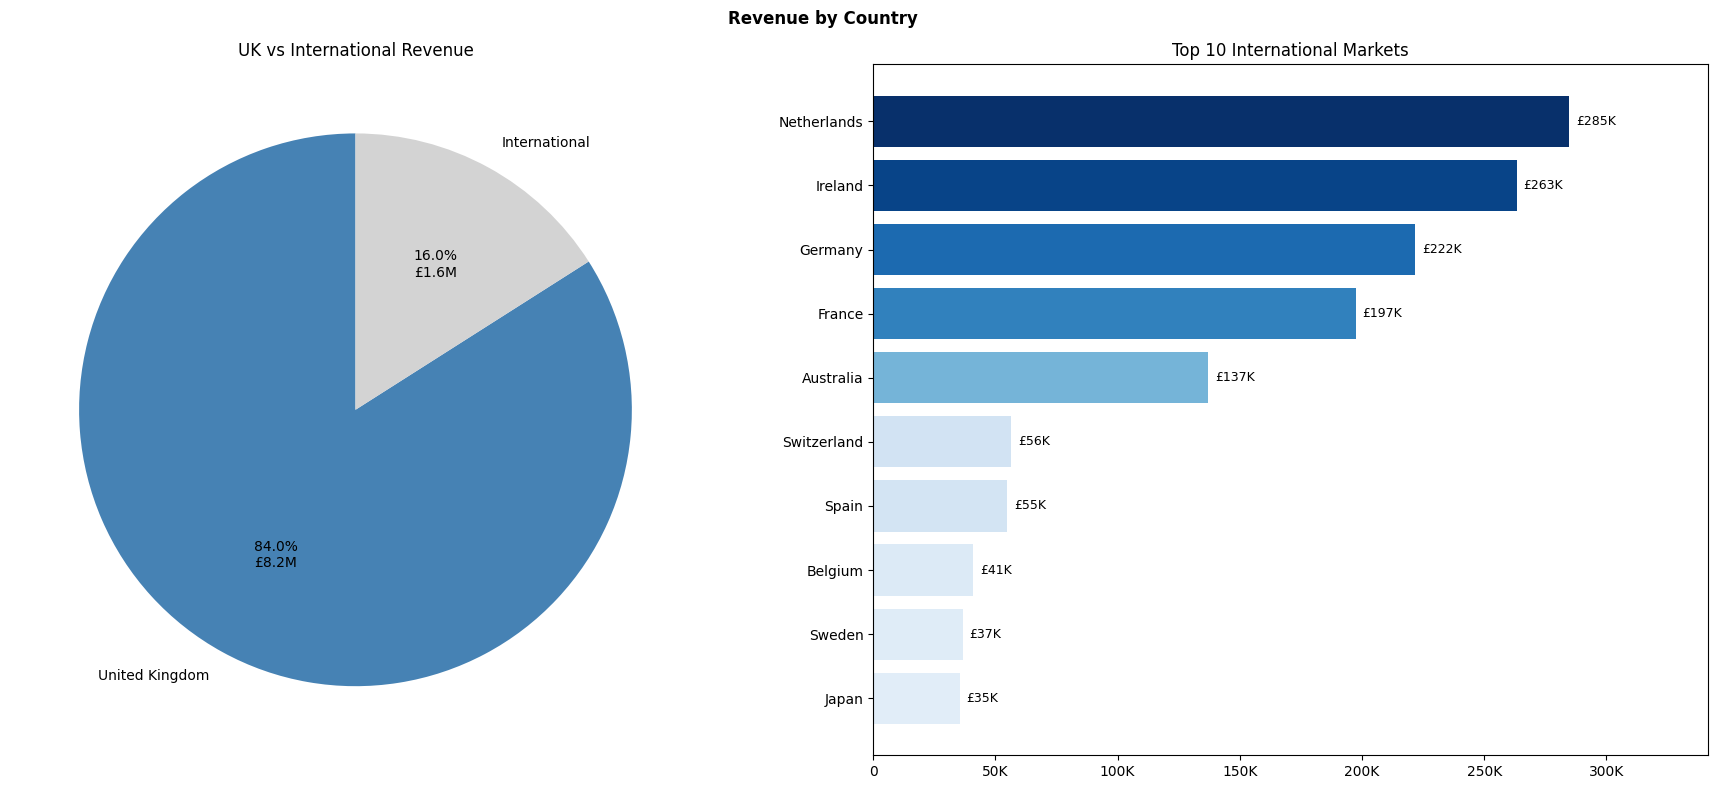

In [106]:

uk_revenue = countries.loc['United Kingdom', 'TotalRevenue']
international_revenue = countries[countries.index != 'United Kingdom']['TotalRevenue'].sum()

international_top10 = countries[
    countries.index != 'United Kingdom'
].tail(10)

pie_data = pd.Series({'United Kingdom': uk_revenue, 'International': international_revenue})
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# pie - UK vs International
total = pie_data.sum()
axes[0].pie(pie_data.values, labels=pie_data.index,
            autopct=lambda p: f'{p:.1f}%\n£{format_axis(p * total / 100, None)}',
            colors=['steelblue', 'lightgrey'],
            startangle=90)
axes[0].set_title('UK vs International Revenue')

# barh - international breakdown
cmap = matplotlib.colormaps['Blues']
norm = mcolors.Normalize(vmin=international_top10['TotalRevenue'].min() * 0.1,
                         vmax=international_top10['TotalRevenue'].max())
colors = [cmap(norm(val)) for val in international_top10['TotalRevenue']]

axes[1].barh(range(len(international_top10)),
             international_top10['TotalRevenue'], color=colors)

for i, val in enumerate(international_top10['TotalRevenue']):
    axes[1].text(val + international_top10['TotalRevenue'].max() * 0.01,
                 i, f'£{format_axis(val, None)}', va='center', fontsize=9)

axes[1].set_xlim(0, international_top10['TotalRevenue'].max() * 1.2)
axes[1].set_yticks(range(len(international_top10)))
axes[1].set_yticklabels(international_top10.index)
axes[1].xaxis.set_major_formatter(FuncFormatter(format_axis))
axes[1].set_title('Top 10 International Markets')

plt.suptitle('Revenue by Country', fontweight='bold')
plt.tight_layout()
plt.show()

In [107]:
revenue_by_country = df.groupby('Country').agg(
    TotalRevenue=('TotalPrice', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique')
).reset_index()


fig = px.choropleth(
    revenue_by_country,
    locations='Country',
    locationmode='country names',
    color='TotalRevenue',
    color_continuous_scale='Blues',
    scope='world',
    title='Revenue & Orders by Country (UK excluded from color scale)',
    range_color=[0, revenue_by_country[
        revenue_by_country['Country'] != 'United Kingdom'
    ]['TotalRevenue'].max()],
    custom_data=['TotalRevenue', 'TotalOrders']
)

# to format values for hover
fig.update_traces(
    hovertemplate='<b>%{location}</b><br>' +
                  'Revenue: £%{customdata[0]:,.0f}<br>' +
                  'Orders: %{customdata[1]:,}<extra></extra>'
)


# Europe is only relevant continent, but we can keep whole wold and just display
# chart zoomed on Europen default, it is more elegant solution
fig.update_geos(
    center=dict(lon=10, lat=52),  # center on Europe
    projection_scale=4,            # zoom level, higher = more zoomed
    showland=True,
    landcolor='lightgrey',
    showocean=True,
    oceancolor='lightblue'
)

fig.update_layout(
    width=1200,
    height=600,
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()




/var/folders/05/3xzngw_n6tv7wlp__kmhfjwh0000gn/T/ipykernel_89354/747562742.py:7: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [108]:
# we need to do bunch agregation better to add new column to original df
df['Market'] = df['Country'].apply(lambda x: 'Domestic' if x == 'United Kingdom' else 'International')

market_comparison = df.groupby('Market').agg(
    TotalRevenue = ('TotalPrice', 'sum'),
    TotalCustomers = ('CustomerID', 'nunique'),
    TotalOrders = ('InvoiceNo', 'nunique')).assign(
        AverageOrderValue = lambda x: x['TotalRevenue'] / x['TotalOrders'],
        RevenueShare = lambda x: x['TotalRevenue']/df['TotalPrice'].sum()
        ).sort_values(
            'TotalRevenue')

market_comparison.style.format({
    'TotalRevenue': '£{:,.0f}',
    'AverageOrderValue': '£{:,.2f}',
    'TotalOrders': '{:,}',
    'TotalCustomers': '{:,}',
    'RevenueShare': '{:.1%}'
})


,TotalRevenue,TotalCustomers,TotalOrders,AverageOrderValue,RevenueShare
Market,,,,,
International,"£1,559,942",422,"2,406",£648.35,16.0%
Domestic,"£8,198,868","3,950","23,491",£349.02,84.0%


In [109]:
# I am supposed to check significan diffecence between markets
# I makes sense only for AverageOrderValue, task suggest T-test
# But for skewed data set is better to use non-paramtetric test
# so let's do also MannWhitney U, whoch doesn't assume normal distribution
# and compare results
# prepare order level data
uk_orders = df[df['Market']=='Domestic'].groupby('InvoiceNo')['TotalPrice'].sum()
international_orders = df[df['Market']=='International'].groupby('InvoiceNo')['TotalPrice'].sum()

# t test assumes normal distribution
t_stat, p_value = ttest_ind(uk_orders, international_orders)
print(f't-test: p-value = {p_value: .4f}')

# Mann-Whitney non-parametric, doesn't assume normal distribution
u_stat, p_value_mw = mannwhitneyu(uk_orders, international_orders)
print(f'Mann-Whitney U: p-value = {p_value_mw: .4f}')

t-test: p-value =  0.0000
Mann-Whitney U: p-value =  0.0000


In [110]:
print(f'UK orders: {len(uk_orders)}')
print(f'International orders: {len(international_orders)}')

UK orders: 23491
International orders: 2406


International market represents 16% of revenue from 423 customers vs 3,951 domestic. Average order value is nearly 2x higher internationally (£648 vs £349), statistically confirmed by both t-test and Mann-Whitney U (p-value ≈ 0).

Could be caused by international shipping costs - act as a natural filter eliminating low-value orders, meaning only economically justified higher-value purchases are placed from abroad.

Let's check if it is caused by quantity or Unit Price

In [111]:
df.info()

<class 'pandas.DataFrame'>
Index: 541906 entries, 0 to 541908
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   InvoiceNo        541906 non-null  object        
 1   StockCode        541906 non-null  object        
 2   Description      540452 non-null  object        
 3   Quantity         541906 non-null  int64         
 4   InvoiceDateTime  541906 non-null  datetime64[us]
 5   UnitPrice        541906 non-null  float64       
 6   CustomerID       406829 non-null  str           
 7   Country          541906 non-null  str           
 8   TotalPrice       541906 non-null  float64       
 9   IsReturn         541906 non-null  bool          
 10  IsProduct        541906 non-null  bool          
 11  Month            541906 non-null  int32         
 12  Day              541906 non-null  int32         
 13  Hour             541906 non-null  int32         
 14  InvoiceDate      541906 non-null  ob

In [112]:


market_comparison_v2 = df.groupby('Market').agg(
    AvgUnitPrice = ('UnitPrice', 'mean'),
    TotalQuantity = ('Quantity', 'sum'),
    TotalOrders = ('InvoiceNo', 'nunique')).assign(
        AverageOrderQuantity = lambda x: x['TotalQuantity'] / x['TotalOrders'],
        ).round(2)
print(market_comparison_v2)


               AvgUnitPrice  TotalQuantity  TotalOrders  AverageOrderQuantity
Market                                                                       
Domestic               4.55        4263826        23491                181.51
International          5.45         912621         2406                379.31


In [113]:
df = df.join(customers['CustomerType'], how='left', on='CustomerID')

market_comparison_v2 = df.groupby(['Market', 'CustomerType']).agg(
    AvgUnitPrice=('UnitPrice', 'mean'),
    TotalQuantity=('Quantity', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique')
).assign(
    AverageOrderQuantity=lambda x: x['TotalQuantity'] / x['TotalOrders'],
).round(2)

market_comparison_v2

AvgUnitPrice  TotalQuantity  TotalOrders  \
Market        CustomerType                                             
Domestic      Retail                3.18        1656152        12263   
              Wholesale             3.36        2352381         7594   
International Retail                5.18         138196         1029   
              Wholesale             5.07         760159         1304   

                            AverageOrderQuantity  
Market        CustomerType                        
Domestic      Retail                      135.05  
              Wholesale                   309.77  
International Retail                      134.30  
              Wholesale                   582.94

UK vs International — Order Quantity Analysis

Retail customers show almost identical average order quantity domestically and internationally (135 vs 134 items), confirming that retail buying behavior is consistent regardless of market. However international retail customers pay significantly higher average unit price (£5.18 vs £3.18) — consistent with the shipping cost filter hypothesis, where low-value cheap items simply aren't worth ordering internationally, naturally pushing the average price up.

The significant difference in overall order size is entirely driven by wholesale customers — international wholesale orders average 562 items vs 232 domestically, more than double. This suggests international wholesale customers are large distributors or retailers purchasing in bulk from abroad rather than just consolidating orders to offset shipping costs.

In summary — the international premium in order value has two distinct drivers: a structural price filter for retail customers, and genuinely larger purchasing scale for wholesale customers.

## International growth

In [114]:
# let's get monthly market share to respond on the last question
# Is international % growing over time?
monthly_market = df.groupby(['YearMonth', 'Market'])['TotalPrice'].sum().unstack()

# Note: sum(axis=1) == row total
monthly_market_share = monthly_market.div(monthly_market.sum(axis=1), axis=0)
monthly_market_share.head()

Market,Domestic,International
YearMonth,,
2010-12,0.903580,0.096420
2011-01,0.775550,0.224450
2011-02,0.819672,0.180328
2011-03,0.819163,0.180837
2011-04,0.896690,0.103310


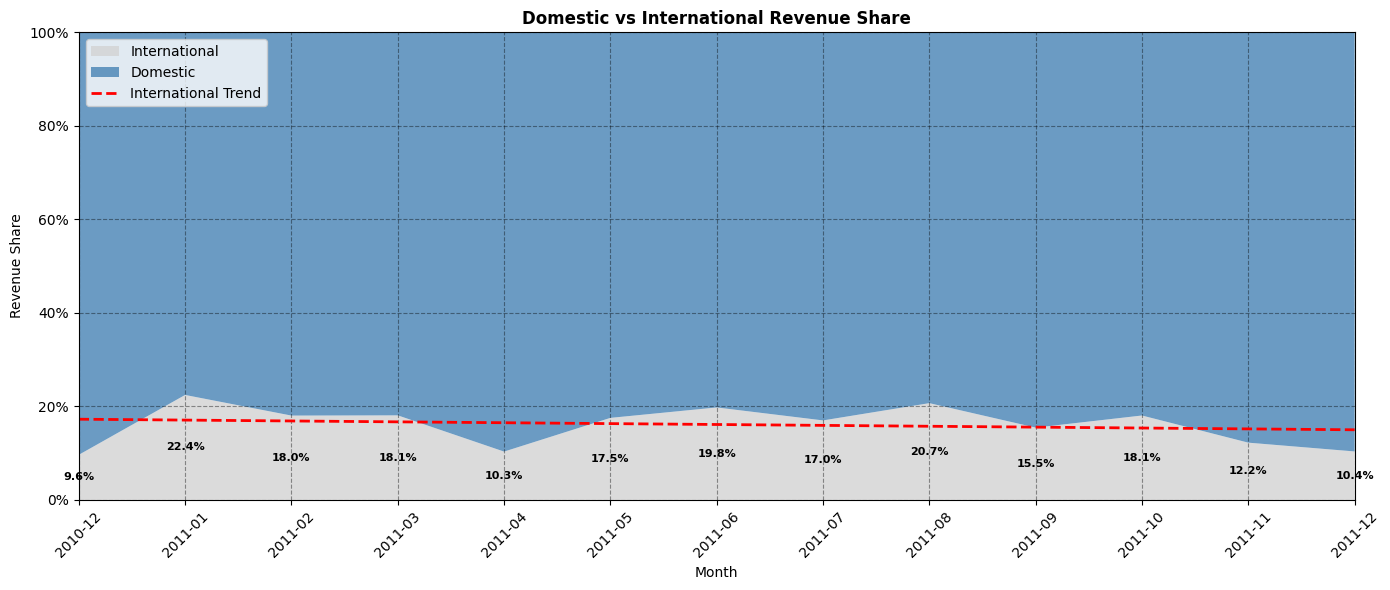

In [115]:
fig, ax = plt.subplots(figsize=(14, 6))

# numpy has problem to handle dtime data type
monthly_market_share.index = monthly_market_share.index.astype(str)

ax.stackplot(monthly_market_share.index,
             monthly_market_share['International'],
             monthly_market_share['Domestic'],
             labels=['International', 'Domestic'],
             colors=['lightgrey', 'steelblue'],
             alpha=0.8)

# labels for International band
for i, (month, val) in enumerate(monthly_market_share['International'].items()):
    ax.text(i, val / 2,
            f'{val:.1%}',
            ha='center', va='center',
            fontsize=8, fontweight='bold',
            color='black')

# trend line for International share
x = range(len(monthly_market_share))
z = np.polyfit(x, monthly_market_share['International'], 1)
p = np.poly1d(z)
ax.plot(monthly_market_share.index, p(x),
        color='red', linewidth=2, linestyle='dashed', label='International Trend')

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.0%}'))
ax.set_xlim(0, len(monthly_market_share) - 1)  # fix cut off
ax.set_ylim(0, 1)                               # fix cut off
ax.set_xlabel('Month')
ax.set_ylabel('Revenue Share')
ax.set_title('Domestic vs International Revenue Share', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(linestyle='--', alpha=0.4, color='black')
plt.xticks(range(len(monthly_market_share)), monthly_market_share.index, rotation=45)
plt.tight_layout()
plt.show()

Domestic vs International Revenue Share — Key Findings
International market share fluctuates between 10-22% throughout the year with no clear structural trend — the linear trend line suggests a very minor decline but the slope is negligible and unlikely to be statistically meaningful given the limited data.
Seasonal pattern is visible — international share dips in April (10.3%) and November-December (12.2%, 10%) while peaking in January (22.4%) and August (20.7%). This could reflect:

UK domestic customers driving Q4 Christmas shopping more than international
International wholesale buyers front-loading orders early in the year

Limitations:

13 months of data is insufficient to separate seasonal fluctuation from real trend — the apparent decline could simply be Q4 seasonality repeating
December 2011 is incomplete (9 days) which depresses the international share for the final data point
YoY first-week comparison showed +20.2% overall growth suggesting the business is expanding, but whether international grows proportionally cannot be confirmed

At least two full years of data would be required to distinguish seasonal patterns from underlying shifts in the domestic/international revenue mix.


---



# RETURN ANALYSIS

1. **Calculate return rate:**
   - What % of orders are returns?
   - Total value of returns

2. **Which products are returned most?**
   - Top 10 returned products
   - Compare to top sold products

3. **Return pattern:**
   - Do returns happen more on certain days?
   - Time analysis of returns


Order count share is misleading because a single return invoice can cancel a large order. Quantity and value return rates are the meaningful metrics.

## Return Rate

## Returns Analysis

Returns can be measured across three dimensions, each revealing a different aspect of
business performance:

**Number of returned orders** reflects customer behaviour — how many customers are
dissatisfied enough to initiate a return. This metric is relevant for customer experience
and NPS tracking and is not distorted by order size, treating a £5 return the same as a £500 one.

**Quantity of returned items** is the primary product quality signal. Systematic high
quantity returns at product level suggest quality issues worth escalating to suppliers.
Note this metric can be skewed by bulk wholesale cancellations which inflate return
quantities without necessarily reflecting product quality problems.

**Value of returned items** is the financial performance metric — the direct bottom line
impact most relevant for finance and management reporting. Like quantity, it is susceptible
to distortion from high-value wholesale cancellations.

Each metric is analysed separately below as they can tell different stories — divergence
between them often reveals whether a pattern is driven by customer behaviour, product
quality issues, or isolated high-value events.

In [116]:
gross_sales_quantity = df[~df['IsReturn'] & df['IsProduct']]['Quantity'].sum()
gross_sales_value = df[~df['IsReturn'] & df['IsProduct']]['TotalPrice'].sum()
gross_sales_orders = df[~df['IsReturn'] & df['IsProduct']]['InvoiceNo'].nunique()

return_quantity = df[df['IsReturn'] & df['IsProduct']]['Quantity'].sum()
return_value = df[df['IsReturn'] & df['IsProduct']]['TotalPrice'].sum()
return_orders = df[df['IsReturn'] & df['IsProduct']]['InvoiceNo'].nunique()

# customer behaviour signal
print(f'Returned orders: {return_orders:,} ({return_orders/gross_sales_orders:.1%} of total orders)')

# product quality signal
print(f'Returned quantity: {abs(return_quantity):,.0f} ({abs(return_quantity)/gross_sales_quantity:.1%} of total quantity)')

# financial performance signal
print(f'Returned value: £{abs(return_value):,.0f} ({abs(return_value)/gross_sales_value:.1%} of gross sales value)')

Returned orders: 4,823 (23.5% of total orders)
Returned quantity: 480,183 (8.5% of total quantity)
Returned value: £484,485 (4.7% of gross sales value)


## Top Returned Products

In [117]:
# calculate gross sales per product first
product_sales = df[~df['IsReturn'] & df['IsProduct']].groupby(['StockCode', 'Description']).agg(
    SalesQuantity=('Quantity', 'sum'),
    SalesValue=('TotalPrice', 'sum')
)

# calculate returns per product
product_returns = df[df['IsReturn']].groupby(['StockCode', 'Description']).agg(
    ReturnQuantity=('Quantity', 'sum'),
    ReturnValue=('TotalPrice', 'sum')
).assign(
    ReturnQuantity=lambda x: x['ReturnQuantity'].abs(),
    ReturnValue=lambda x: x['ReturnValue'].abs()
)

# join and calculate return rate
product_return_rate = product_sales.join(product_returns, how='left').fillna(0).assign(
    ReturnRateQuantity=lambda x: x['ReturnQuantity'] / x['SalesQuantity'],
    ReturnRateValue=lambda x: x['ReturnValue'] / x['SalesValue']
).round(3)

# top 10 by return quantity
top_returned = product_return_rate.sort_values('ReturnQuantity', ascending=False).head(10)
print(top_returned[['SalesQuantity', 'ReturnQuantity', 'ReturnRateQuantity',
                     'SalesValue', 'ReturnValue', 'ReturnRateValue']])

                                               SalesQuantity  ReturnQuantity  \
StockCode Description                                                          
23843     PAPER CRAFT , LITTLE BIRDIE                  80995         80995.0   
23166     MEDIUM CERAMIC TOP STORAGE JAR               78033         74494.0   
84347     ROTATING SILVER ANGELS T-LIGHT HLDR           9476          9376.0   
21108     FAIRY CAKE FLANNEL ASSORTED COLOUR           10253          3150.0   
20971     PINK BLUE FELT CRAFT TRINKET BOX             11001          2617.0   
85123A    WHITE HANGING HEART T-LIGHT HOLDER           37603          2578.0   
21175     GIN + TONIC DIET METAL SIGN                  11727          2030.0   
22920     HERB MARKER BASIL                             3427          1527.0   
22273     FELTCRAFT DOLL MOLLY                          4514          1447.0   
47566B    TEA TIME PARTY BUNTING                        2382          1424.0   

                                       

In [118]:
top_returned

,,SalesQuantity,SalesValue,ReturnQuantity,ReturnValue,ReturnRateQuantity,ReturnRateValue
StockCode,Description,,,,,,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,80995.0,168469.60,1.000,1.000
23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,74494.0,77479.64,0.955,0.948
84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9476,26463.83,9376.0,321.60,0.989,0.012
21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,10253,18069.28,3150.0,6591.42,0.307,0.365
20971,PINK BLUE FELT CRAFT TRINKET BOX,11001,13838.10,2617.0,2778.77,0.238,0.201
85123A,WHITE HANGING HEART T-LIGHT HOLDER,37603,104340.29,2578.0,6624.30,0.069,0.063
21175,GIN + TONIC DIET METAL SIGN,11727,25836.57,2030.0,3775.33,0.173,0.146
22920,HERB MARKER BASIL,3427,2155.94,1527.0,841.05,0.446,0.390
22273,FELTCRAFT DOLL MOLLY,4514,12016.34,1447.0,3512.65,0.321,0.292


In [119]:
top_returned['IsTopRevenueProduct'] = top_returned.index.get_level_values('StockCode').isin(top_revenue_products.index)
top_returned['IsTopQuantityProduct'] = top_returned.index.get_level_values('StockCode').isin(top_quantity_products.index)

top_returned[['IsTopRevenueProduct', 'IsTopQuantityProduct']]

,,IsTopRevenueProduct,IsTopQuantityProduct
StockCode,Description,,
23843,"PAPER CRAFT , LITTLE BIRDIE",True,True
23166,MEDIUM CERAMIC TOP STORAGE JAR,True,True
84347,ROTATING SILVER ANGELS T-LIGHT HLDR,False,False
21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,False,False
20971,PINK BLUE FELT CRAFT TRINKET BOX,False,False
85123A,WHITE HANGING HEART T-LIGHT HOLDER,True,True
21175,GIN + TONIC DIET METAL SIGN,False,False
22920,HERB MARKER BASIL,False,False
22273,FELTCRAFT DOLL MOLLY,False,False


## Return Analysis — Cross-Reference with Top Products

Three of the top 10 most returned products also appear in the top revenue and quantity rankings:

- **PAPER CRAFT, LITTLE BIRDIE** — 100% return rate, likely a data/cancellation issue rather than genuine returns
- **MEDIUM CERAMIC TOP STORAGE JAR** — 95.5% return rate, serious quality concern for a top selling product
- **WHITE HANGING HEART T-LIGHT HOLDER** — only 6.9% return rate, acceptable despite appearing in both lists

The remaining 7 high-return products are not top sellers, suggesting their return issues have limited financial impact currently but could worsen if volumes grow.

**Key concern** — MEDIUM CERAMIC TOP STORAGE JAR is simultaneously a top revenue/quantity product AND has a near-total return rate. Without margin data it's impossible to determine whether this product is generating any positive contribution at all. This is exactly the scenario where margin data would be critical — a high-revenue product with 95% returns could easily be generating a net loss once handling, shipping and restocking costs are factored in.

**Recommendation:** Prioritise margin analysis and supplier review for MEDIUM CERAMIC TOP STORAGE JAR before continuing to promote or stock this product. Flag PAPER CRAFT anomaly for data investigation — if confirmed as a genuine return pattern rather than a data issue it warrants the same urgency.

## Time Development & Pattern

### Returned Quantity Development

Before examining order and value patterns, let's first look at returned quantity over time
to understand which products are driving return volumes and whether any show concerning trends.

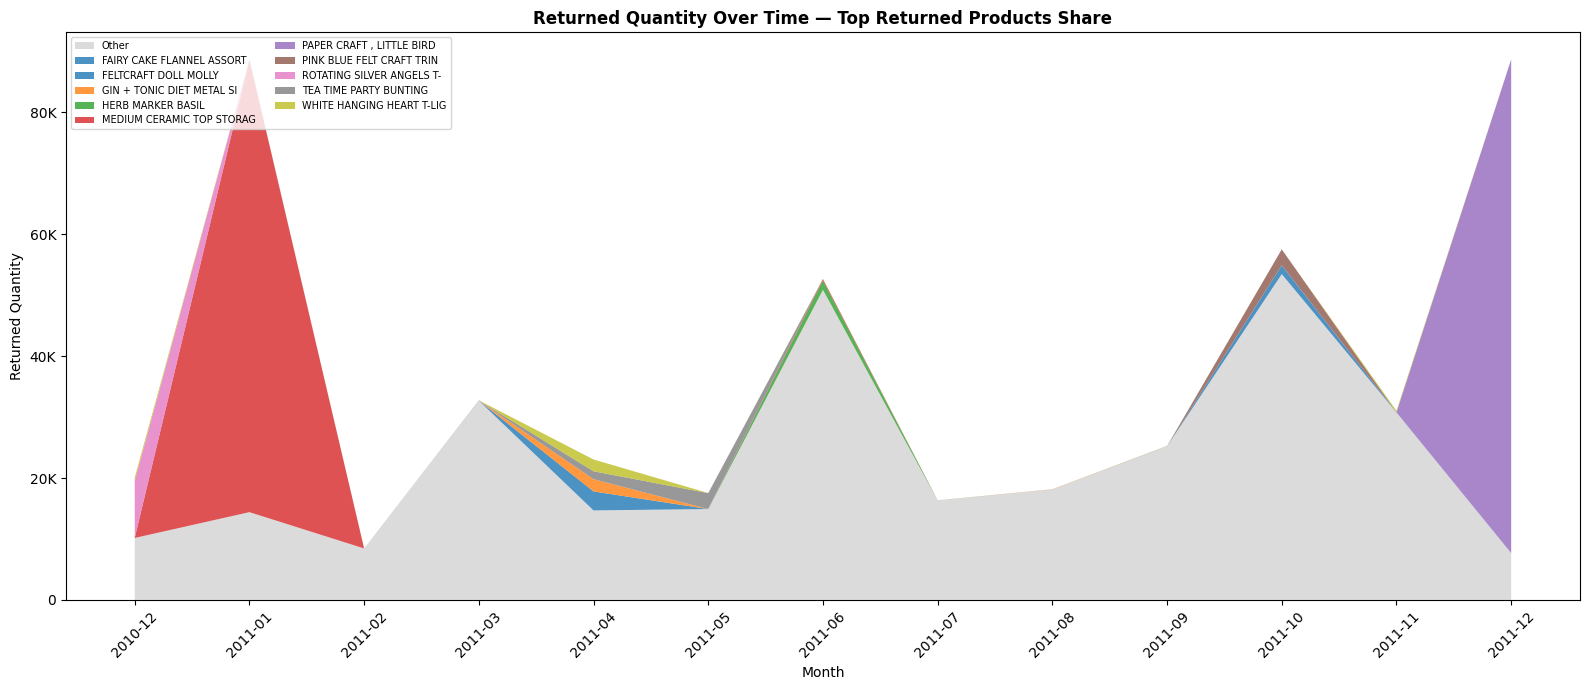

In [120]:
# returned quantity development — overall trend with top returned products breakdown
top_returned_codes = top_returned.index.get_level_values('StockCode')
descriptions = top_returned.reset_index()[['StockCode', 'Description']].set_index('StockCode')['Description']

returns_monthly_product = df[
    df['IsReturn'] & df['IsProduct']
].groupby(['YearMonth', 'StockCode'])['Quantity'].sum().abs().reset_index()

returns_monthly_product['YearMonth'] = returns_monthly_product['YearMonth'].astype(str)

returns_monthly_product['Category'] = returns_monthly_product['StockCode'].apply(
    lambda x: descriptions[x][:25] if x in top_returned_codes else 'Other'
)

returns_pivot = returns_monthly_product.groupby(
    ['YearMonth', 'Category'])['Quantity'].sum().unstack().fillna(0)

cols = ['Other'] + [c for c in returns_pivot.columns if c != 'Other']
returns_pivot = returns_pivot[cols]

cmap = matplotlib.colormaps['tab10']
colors = ['lightgrey'] + [cmap(i/len(cols)) for i in range(len(cols)-1)]

fig, ax = plt.subplots(figsize=(16, 7))

ax.stackplot(range(len(returns_pivot)),
             [returns_pivot[col].values for col in cols],
             labels=cols, colors=colors, alpha=0.8)

ax.set_xticks(range(len(returns_pivot)))
ax.set_xticklabels(returns_pivot.index, rotation=45)
ax.yaxis.set_major_formatter(FuncFormatter(format_axis))
ax.set_title('Returned Quantity Over Time — Top Returned Products Share', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Returned Quantity')
ax.legend(loc='upper left', fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

January 2011 spike (80K) is dominated by the red MEDIUM CERAMIC TOP STORAGE JAR — this single product drove the majority of January returns, strongly suggesting a batch quality issue or a large wholesale cancellation rather than scattered customer dissatisfaction. The spike is isolated to one month which points to a one-time event.

June 2011 spike (52K) is driven almost entirely by the grey "Other" category — no single top returned product is responsible, suggesting a broader return wave across many products. Could be seasonal, a system correction, or multiple smaller quality issues coinciding.

October 2011 spike (55K) shows a different composition — dominated by FAIRY CAKE FLANNEL (blue) alongside Other, suggesting another product-specific issue emerging in Q4.

December 2011 — the purple spike is PAPER CRAFT, LITTLE BIRDIE dominating, consistent with the 100% return rate finding. Almost certainly a single large order cancellation given the pattern.

Between spikes (Feb-May, Jul-Sep) — returns are relatively stable at 15-25K with Other dominating, suggesting a healthy baseline return rate with no systematic product issues during these periods.

Key insight — return volume is event-driven rather than structural. Each spike can be attributed to a specific product or event rather than a general deterioration in quality or customer satisfaction. This is actually reassuring — it means the business doesn't have a systemic returns problem, just a few specific products and events requiring attention.

In [121]:
# --- Returns Analysis Data Preparation ---

# filter to products only, split sales and returns
df_returns = df[df['IsReturn'] & df['IsProduct']].copy()
df_sales = df[~df['IsReturn'] & df['IsProduct']].copy()

# --- Monthly aggregations ---
returns_monthly = df_returns.groupby('YearMonth').agg(
    ReturnOrders=('InvoiceNo', 'nunique'),
    ReturnQuantity=('Quantity', 'sum'),
    ReturnValue=('TotalPrice', 'sum')
).assign(
    ReturnQuantity=lambda x: x['ReturnQuantity'].abs(),
    ReturnValue=lambda x: x['ReturnValue'].abs()
)
returns_monthly.index = returns_monthly.index.astype(str)

monthly_sales = df_sales.groupby('YearMonth')['TotalPrice'].sum()
monthly_sales.index = monthly_sales.index.astype(str)

return_rate_monthly = (returns_monthly['ReturnValue'] / monthly_sales).fillna(0)

# --- Day of week aggregations ---
returns_by_day = df_returns.groupby('DayOfWeek').agg(
    ReturnOrders=('InvoiceNo', 'nunique'),
    ReturnQuantity=('Quantity', 'sum'),
    ReturnValue=('TotalPrice', 'sum')
).reindex(day_order).assign(
    ReturnQuantity=lambda x: x['ReturnQuantity'].abs(),
    ReturnValue=lambda x: x['ReturnValue'].abs()
)

sales_by_day = df_sales.groupby('DayOfWeek').agg(
    SalesOrders=('InvoiceNo', 'nunique'),
    SalesQuantity=('Quantity', 'sum'),
    SalesValue=('TotalPrice', 'sum')
).reindex(day_order)

returns_by_day = returns_by_day.join(sales_by_day).assign(
    OrderReturnRate=lambda x: x['ReturnOrders'] / x['SalesOrders'],
    QuantityReturnRate=lambda x: x['ReturnQuantity'] / x['SalesQuantity'],
    ValueReturnRate=lambda x: x['ReturnValue'] / x['SalesValue']
).round(3)

print('Returns monthly shape:', returns_monthly.shape)
print('Returns by day shape:', returns_by_day.shape)
print(returns_by_day[['ReturnOrders', 'ReturnValue', 'ValueReturnRate']])

Returns monthly shape: (13, 3)
Returns by day shape: (7, 9)
           ReturnOrders  ReturnValue  ValueReturnRate
DayOfWeek                                            
Monday            784.0     61070.58            0.036
Tuesday           933.0    120096.49            0.057
Wednesday         908.0     44593.10            0.025
Thursday         1191.0     51908.79            0.024
Friday            838.0    198823.63            0.112
Saturday            NaN          NaN              NaN
Sunday            169.0      7992.81            0.010


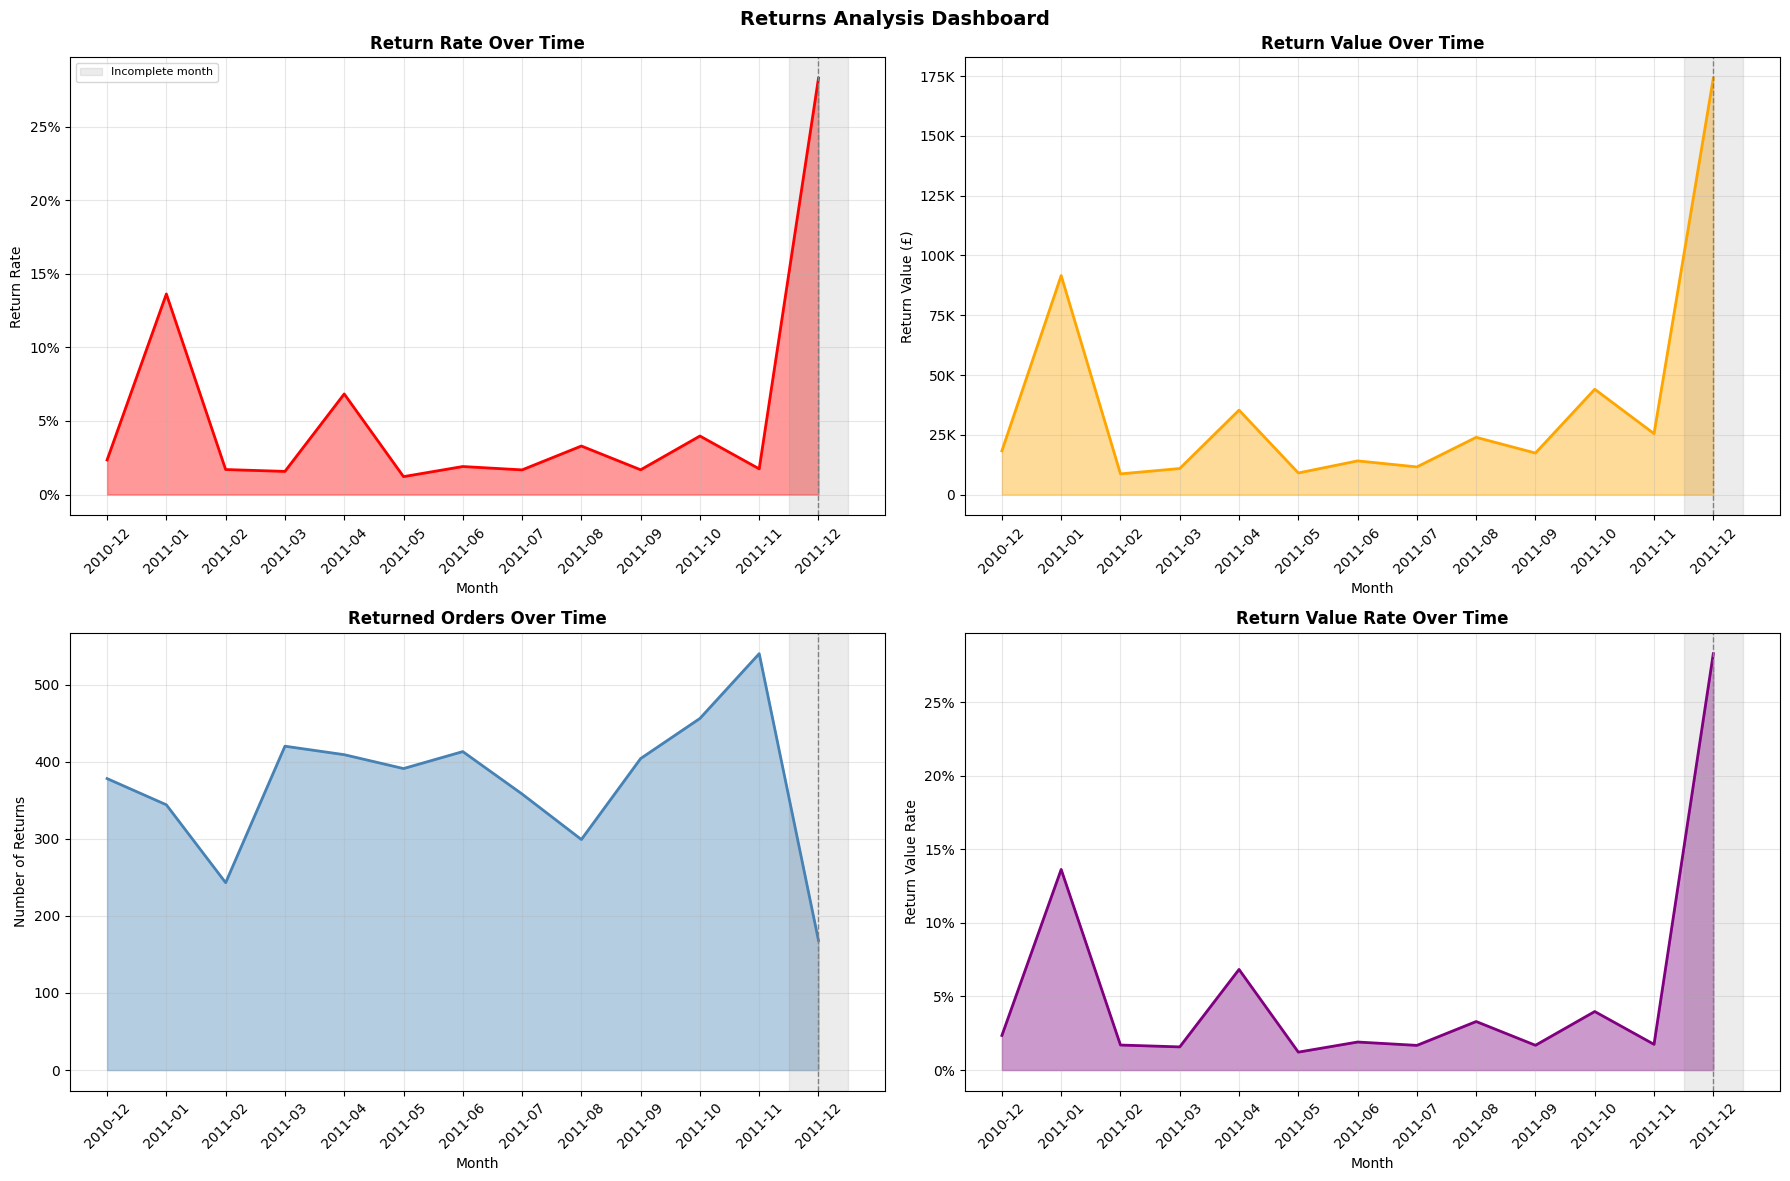

In [122]:
# keep full returns_monthly, add annotation instead
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

returns_monthly.index = returns_monthly.index.astype(str)
monthly_sales = df[(~df['IsReturn']) & (df['IsProduct'])].groupby('YearMonth')['TotalPrice'].sum()
monthly_sales.index = monthly_sales.index.astype(str)

return_rate_monthly = (returns_monthly['ReturnValue'] / monthly_sales).fillna(0)
x = range(len(returns_monthly))
last_x = len(returns_monthly) - 1

def add_incomplete_flag(ax):
    ax.axvspan(last_x - 0.5, last_x + 0.5,
               alpha=0.15, color='grey', label='Incomplete month')
    ax.axvline(last_x, color='grey', linestyle='dashed', linewidth=1)

# --- Return Rate Over Time ---
axes[0, 0].fill_between(x, return_rate_monthly.values, alpha=0.4, color='red')
axes[0, 0].plot(x, return_rate_monthly.values, color='red', linewidth=2)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(returns_monthly.index, rotation=45)
axes[0, 0].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.0%}'))
axes[0, 0].set_title('Return Rate Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Return Rate')
axes[0, 0].grid(True, alpha=0.3)
add_incomplete_flag(axes[0, 0])
axes[0, 0].legend(fontsize=8)

# --- Return Value Over Time ---
axes[0, 1].fill_between(x, returns_monthly['ReturnValue'].values, alpha=0.4, color='orange')
axes[0, 1].plot(x, returns_monthly['ReturnValue'].values, color='orange', linewidth=2)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(returns_monthly.index, rotation=45)
axes[0, 1].yaxis.set_major_formatter(FuncFormatter(format_axis))
axes[0, 1].set_title('Return Value Over Time', fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Return Value (£)')
axes[0, 1].grid(True, alpha=0.3)
add_incomplete_flag(axes[0, 1])

# --- Returned Orders Over Time ---
axes[1, 0].fill_between(x, returns_monthly['ReturnOrders'].values, alpha=0.4, color='steelblue')
axes[1, 0].plot(x, returns_monthly['ReturnOrders'].values, color='steelblue', linewidth=2)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(returns_monthly.index, rotation=45)
axes[1, 0].set_title('Returned Orders Over Time', fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Number of Returns')
axes[1, 0].grid(True, alpha=0.3)
add_incomplete_flag(axes[1, 0])

# --- Return Value Rate Over Time ---
axes[1, 1].fill_between(x, return_rate_monthly.values, alpha=0.4, color='purple')
axes[1, 1].plot(x, return_rate_monthly.values, color='purple', linewidth=2)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(returns_monthly.index, rotation=45)
axes[1, 1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.0%}'))
axes[1, 1].set_title('Return Value Rate Over Time', fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Return Value Rate')
axes[1, 1].grid(True, alpha=0.3)
add_incomplete_flag(axes[1, 1])

plt.suptitle('Returns Analysis Dashboard', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

**Returns Analysis Dashboard — Key Findings**

Return Rate & Return Value Rate (red, purple) tell the same story — both show a dramatic spike in December 2011 (28-30%) but this is the incomplete month and almost certainly distorted. The January 2011 spike (~14%) is the only genuine anomaly worth investigating — possibly post-Christmas returns from December 2010 purchases.

For complete months the return rate is remarkably stable at 1-6%, suggesting returns are a predictable and manageable part of operations rather than a systemic problem.

Return Value Over Time (orange) — January 2011 spike (£88K) confirms the post-Christmas return hypothesis. The November 2011 spike (£44K) aligns with the Q4 sales peak — higher sales naturally drive higher absolute return values even if the rate stays stable.

Returned Orders Over Time (blue) — Unlike the other metrics, returned orders show a gradual upward trend through the year, peaking in November at 530 before dropping in December. This suggests growing customer base and order volume rather than deteriorating customer experience — more customers means more returns even at a stable rate.

Overall conclusion: Returns are well controlled at 2-4% for most months. The December spike is a data artefact of the incomplete month. January post-Christmas returns are the only structural pattern worth monitoring. No evidence of a returns problem — the business appears to have healthy return rates consistent with a well-managed retail operation.

In [123]:
# Return Orders Count & Value - prepare data for a chart
returns_by_day = df[df['IsReturn'] & df['IsProduct']].groupby('DayOfWeek').agg(
    ReturnOrders=('InvoiceNo', 'nunique'),
    ReturnValue=('TotalPrice', 'sum')
).reindex(day_order)
returns_by_day['ReturnValue'] = returns_by_day['ReturnValue'].abs()

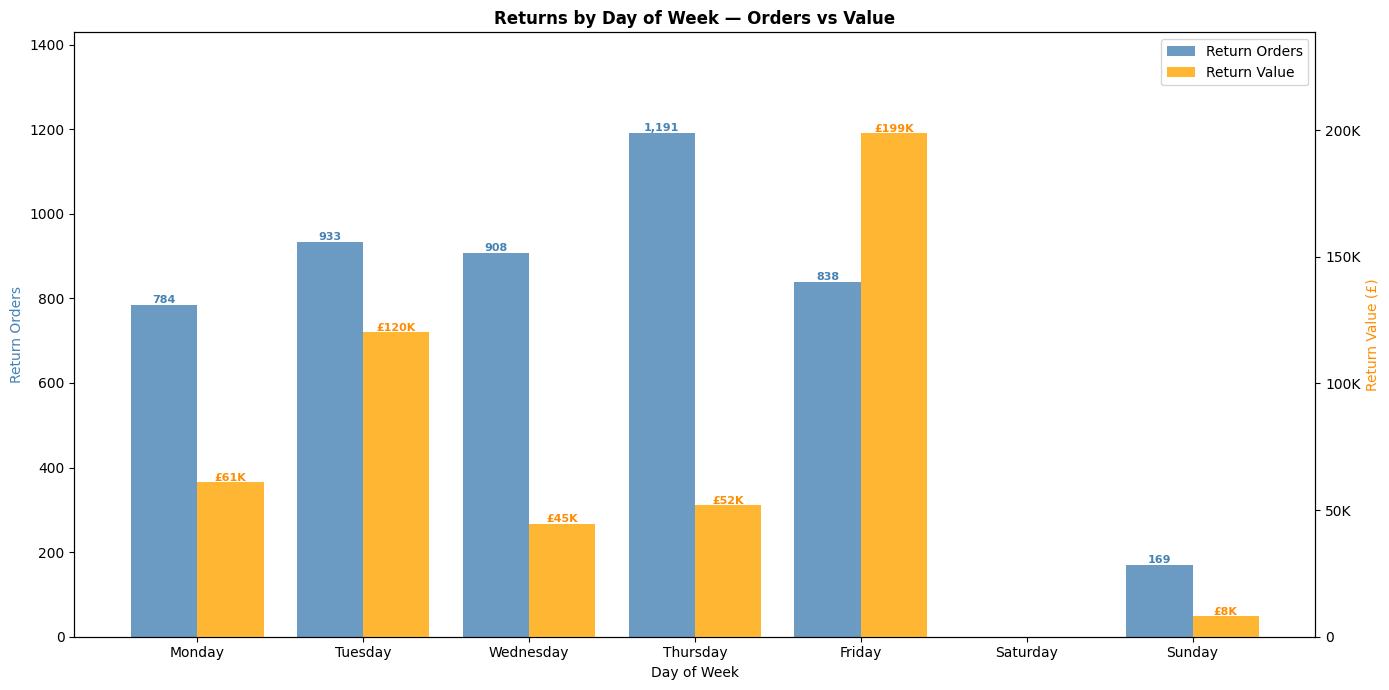

In [124]:
fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

x = range(len(returns_by_day))
width = 0.4

# bars for return orders on ax1
bars1 = ax1.bar([i - width/2 for i in x], returns_by_day['ReturnOrders'],
                width=width, color='steelblue', alpha=0.8, label='Return Orders')

# bars for return value on ax2
bars2 = ax2.bar([i + width/2 for i in x], returns_by_day['ReturnValue'],
                width=width, color='orange', alpha=0.8, label='Return Value')

# value labels for orders
for i, val in enumerate(returns_by_day['ReturnOrders']):
    if pd.notna(val):
        ax1.text(i - width/2, val + 5, f'{int(val):,}',
                ha='center', fontsize=8, fontweight='bold', color='steelblue')

# value labels for value
for i, val in enumerate(returns_by_day['ReturnValue']):
    if pd.notna(val):
        ax2.text(i + width/2, val + 500, f'£{format_axis(val, None)}',
                ha='center', fontsize=8, fontweight='bold', color='darkorange')

ax1.set_xticks(x)
ax1.set_xticklabels(returns_by_day.index)
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Return Orders', color='steelblue')
ax2.set_ylabel('Return Value (£)', color='darkorange')
ax2.yaxis.set_major_formatter(FuncFormatter(format_axis))

ax1.set_ylim(top=returns_by_day['ReturnOrders'].max() * 1.2)
ax2.set_ylim(top=returns_by_day['ReturnValue'].max() * 1.2)

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Returns by Day of Week — Orders vs Value', fontweight='bold')
plt.tight_layout()
plt.show()

Thursday leads in return orders (1,191) — consistent with it being the busiest trading day overall. However the return value on Thursday is relatively low (£52K) despite the high order count, suggesting Thursday returns are predominantly small retail orders rather than high-value wholesale cancellations.
Friday is the standout anomaly — only 838 return orders (4th highest) but by far the highest return value at £199K. This significant divergence between order count and value strongly suggests Friday is when large wholesale returns and cancellations are processed — fewer but much higher value transactions.
Tuesday (£120K) also shows elevated return value relative to order count — consistent with the earlier finding that Tuesday attracts more wholesale customers.
Wednesday has the lowest return value (£45K) despite 908 return orders — confirming Wednesday is predominantly retail customers returning small value items.
Saturday — zero returns as expected, warehouse closed.
Sunday — minimal activity (169 orders, £8K) consistent with the sales pattern.
Overall pattern mirrors the sales day-of-week findings — Thursday/Friday dominance for wholesale activity is visible in returns as well as sales. The Friday return value spike is the most actionable finding — worth investigating whether specific large accounts or products are consistently driving Friday high-value returns.

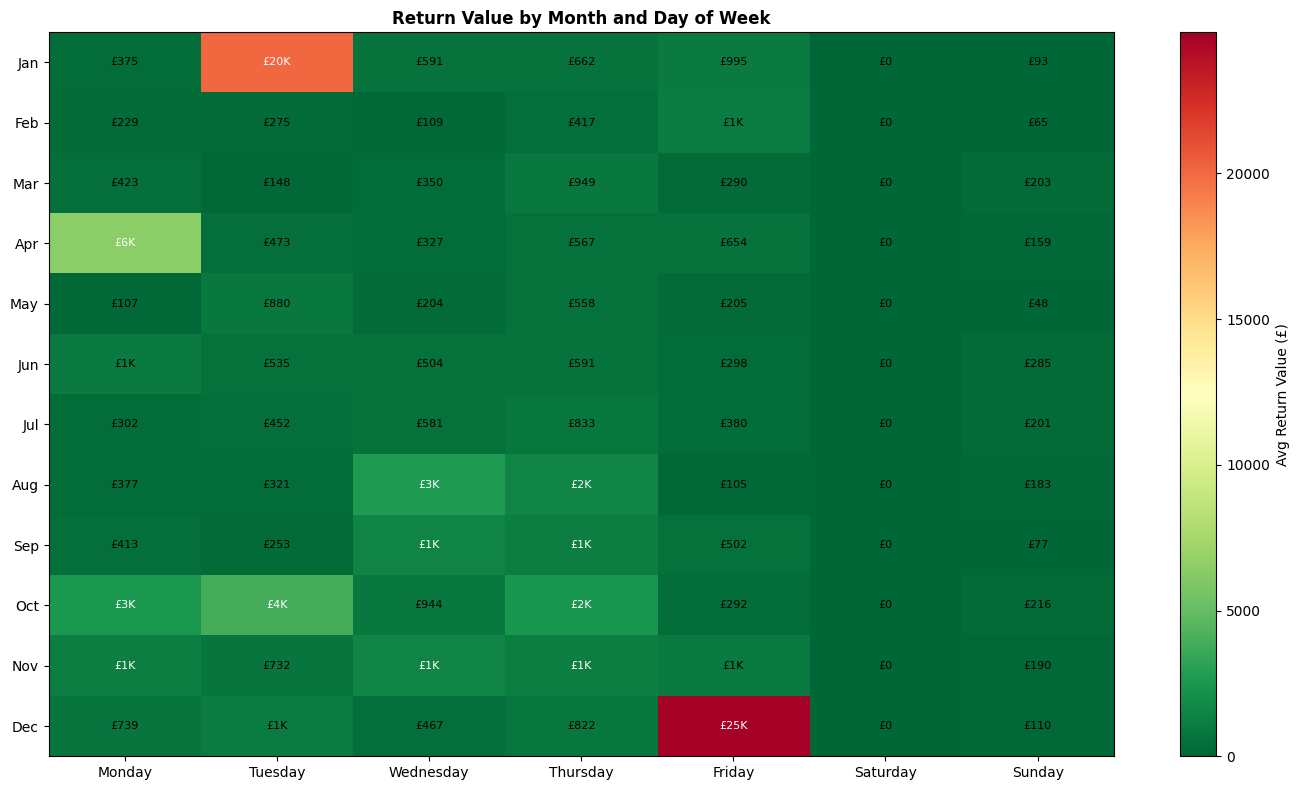

In [125]:
# returned value heat map
returns_daily = df[df['IsReturn'] & df['IsProduct']].set_index('InvoiceDateTime')\
    .resample('D').agg(
        ReturnCount=('InvoiceNo', 'nunique'),
        ReturnValue=('TotalPrice', 'sum')
    )
returns_daily['DayOfWeek'] = returns_daily.index.day_name()
returns_daily['Month'] = returns_daily.index.month
returns_daily['ReturnValue'] = returns_daily['ReturnValue'].abs()

# heatmap - returns by month and day of week
month_day = returns_daily.groupby(['Month', 'DayOfWeek'])['ReturnValue'].mean().unstack()
month_day = month_day.reindex(columns=day_order)

fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(month_day, aspect='auto', cmap='RdYlGn_r')

ax.set_xticks(range(len(month_day.columns)))
ax.set_xticklabels(month_day.columns)
ax.set_yticks(range(len(month_day.index)))
ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# add value labels
for i in range(len(month_day.index)):
    for j in range(len(month_day.columns)):
        val = month_day.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f'£{format_axis(val, None)}',
                    ha='center', va='center', fontsize=8,
                    color='white' if val > month_day.values[~np.isnan(month_day.values)].mean() else 'black')

fig.colorbar(im, ax=ax, label='Avg Return Value (£)')
ax.set_title('Return Value by Month and Day of Week', fontweight='bold')
plt.tight_layout()
plt.show()

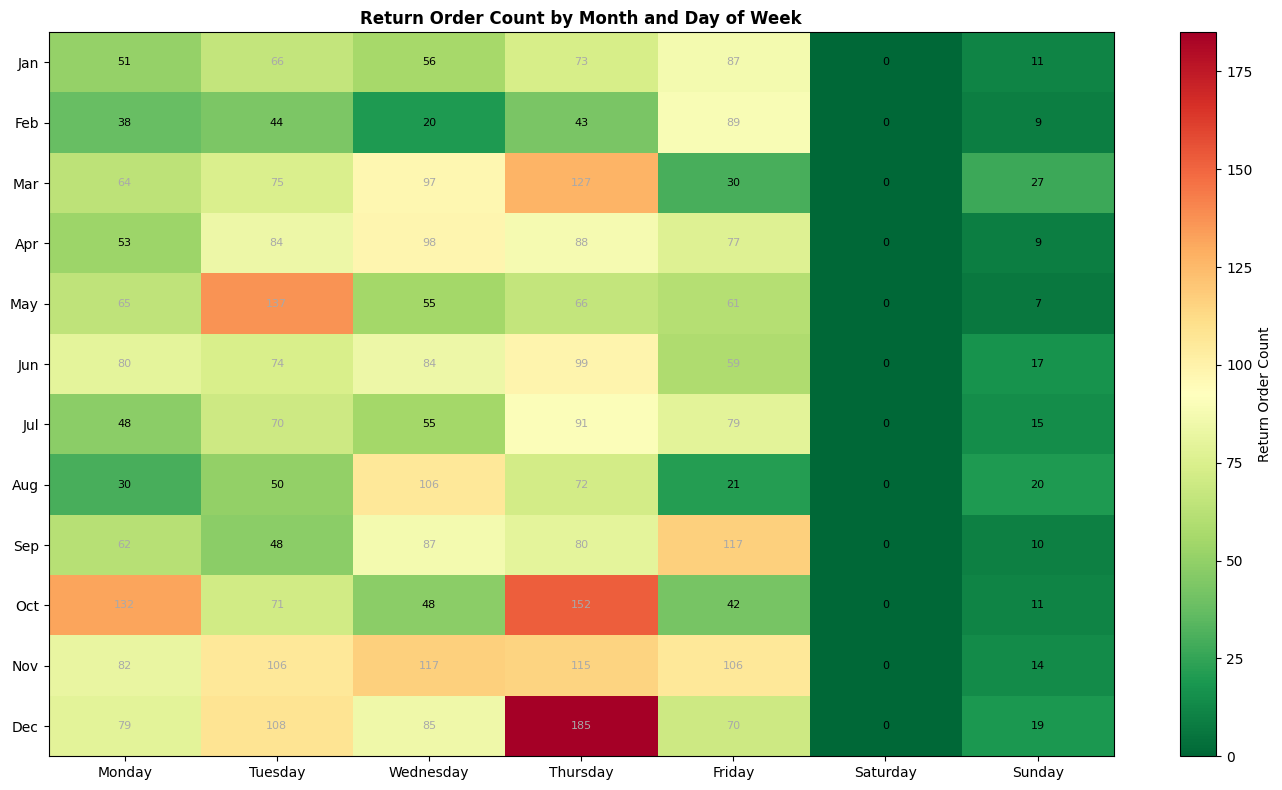

In [126]:
# returned orders heatmap
returns_month_day_orders = df[df['IsReturn'] & df['IsProduct']]\
    .groupby(['Month', 'DayOfWeek'])['InvoiceNo'].nunique().unstack()
returns_month_day_orders = returns_month_day_orders.reindex(columns=day_order).fillna(0)

fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(returns_month_day_orders, aspect='auto', cmap='RdYlGn_r')

ax.set_xticks(range(len(returns_month_day_orders.columns)))
ax.set_xticklabels(returns_month_day_orders.columns)
ax.set_yticks(range(len(returns_month_day_orders.index)))
ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

for i in range(len(returns_month_day_orders.index)):
    for j in range(len(returns_month_day_orders.columns)):
        val = returns_month_day_orders.iloc[i, j]
        ax.text(j, i, f'{int(val):,}',
                ha='center', va='center', fontsize=8,
                color='darkgrey' if val > returns_month_day_orders.values.mean() else 'black')

fig.colorbar(im, ax=ax, label='Return Order Count')
ax.set_title('Return Order Count by Month and Day of Week', fontweight='bold')
plt.tight_layout()
plt.show()

**The two heatmaps tell fundamentally different stories:**

**Return Order Count (this chart)** — relatively evenly distributed across weekdays with some monthly variation. Thursday and Wednesday show elevated counts in certain months (Oct Thursday 152, Dec Thursday 185, Aug Wednesday 166) but no single day dominates consistently across all months.

**Return Value (previous chart)** — far more concentrated with dramatic spikes. January Tuesday (£20K) and December Friday (£25K) stand out as extreme outliers against an otherwise dark green background.

**Key insight from comparing both:**
The divergence between the two charts confirms what the bar chart suggested — high return value days are driven by isolated large wholesale cancellations, not by many customers returning items. For example:

December Friday: only moderate order count but £25K value → one large wholesale return
January Tuesday: similar pattern → single bulk cancellation
Most cells show low value despite moderate order counts → many small retail returns

**What this means practically:**

Return order count follows sales volume pattern (more sales = more returns) — no structural day-of-week problem
Return value spikes are event-driven, not structural — specific large accounts cancelling on specific days
Chi-square on order counts will likely show significance driven by the few extreme cells rather than a consistent weekly pattern

In [127]:
active_days = [d for d in day_order if d != 'Saturday']

# exclude Saturday as no operations
contingency = pd.crosstab(
    df[df['IsProduct']]['DayOfWeek'],
    df[df['IsProduct']]['IsReturn']
).reindex(day_order).dropna()

chi2, p_value, dof, expected = chi2_contingency(contingency)

expected_df = pd.DataFrame(expected,
                           index=active_days,
                           columns=['Expected Non-Return', 'Expected Return'])

print(f'Chi-square statistic: {chi2:.2f}')
print(f'Degrees of freedom: {dof}')
print(f'p-value: {p_value:.4f}')

print('\nActual vs Expected Returns per Day:')
print(pd.DataFrame({
    'ActualReturns': contingency[True],
    'ExpectedReturns': expected_df['Expected Return'].round(0),
    'Difference': contingency[True] - expected_df['Expected Return'].round(0)
}).round(0))

Chi-square statistic: 712.92
Degrees of freedom: 5
p-value: 0.0000

Actual vs Expected Returns per Day:
           ActualReturns  ExpectedReturns  Difference
Monday            1624.0           1774.0      -150.0
Tuesday           1902.0           1900.0         2.0
Wednesday         1948.0           1767.0       181.0
Thursday          2550.0           1940.0       610.0
Friday            1641.0           1533.0       108.0
Sunday             454.0           1206.0      -752.0


Chi-square confirms the non-random distribution (p ≈ 0) but given the large dataset
size statistical significance was expected. The more meaningful finding comes from
the heatmap analysis — the inconsistent monthly pattern suggests returns are driven
by isolated events rather than a structural weekly pattern, which chi-square on
aggregated data cannot detect.

## Returns Analysis — Summary & Recommendations

Return rates are well controlled — 4.7% by value and 8.5% by quantity — with no evidence
of a systemic returns problem. Patterns are event-driven rather than structural, with
isolated spikes attributable to specific products or large wholesale cancellations rather
than consistent weekly or seasonal trends.

**Key findings:**
- January post-Christmas returns are the only recurring seasonal pattern
- Friday high return values are driven by large wholesale cancellations, not retail behaviour
- MEDIUM CERAMIC TOP STORAGE JAR requires urgent supplier review — 95% return rate on a top revenue product
- PAPER CRAFT, LITTLE BIRDIE 100% return rate requires data investigation — likely a single cancelled bulk order

**Critical data gap — return reason categories**

The most significant limitation of this analysis is the absence of return reason data.
Without distinguishing between cancelled orders and defective items, it is impossible to:
- Identify genuine product quality issues vs commercial cancellations
- Measure true customer dissatisfaction rate
- Calculate net revenue impact accurately (cancelled orders have different cost implications than defective returns)
- Build targeted supplier performance metrics

**Recommendation:** Implement mandatory return reason categorisation at minimum:
- `Cancelled Order` — commercial decision, no product issue
- `Defective/Damaged` — quality issue, supplier accountability
- `Wrong Item` — operational/fulfilment error
- `Customer Changed Mind` — demand signal

This single data point would transform return analysis from descriptive to actionable.